20251105 Levi Schult -- a notebook to create a chirpmass KDE for synthesizing 
the CV population in the EM gap. This KDE will be used in addition to the 
equation for GW evolution and the number in the flo bin to determine number of
sources in the EM gap.

## imports

In [1]:
import numpy as np
from scipy import stats, interpolate
from matplotlib import pyplot as plt
import astropy.units as u
import astropy.constants as apyconst
import pandas as pd
import legwork as lw
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
import copy


%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
file = '/home/levis/lisa_projects/blip_CVs/datasets/scaringi_data/dat_maxDistance_1000_final.txt'
CV_pop = pd.read_csv(file)

In [3]:
CV_pop.columns

Index(['# m1[Msun]', ' m2[Msun]', ' f_gw[Hz]', ' inclination[rad]',
       ' x_gal[kpc]', ' y_gal[kpc]', ' z_gal[kpc]', ' Pala_reassigned'],
      dtype='object')

Text(0.5, 0, 'Freq [Hz]')

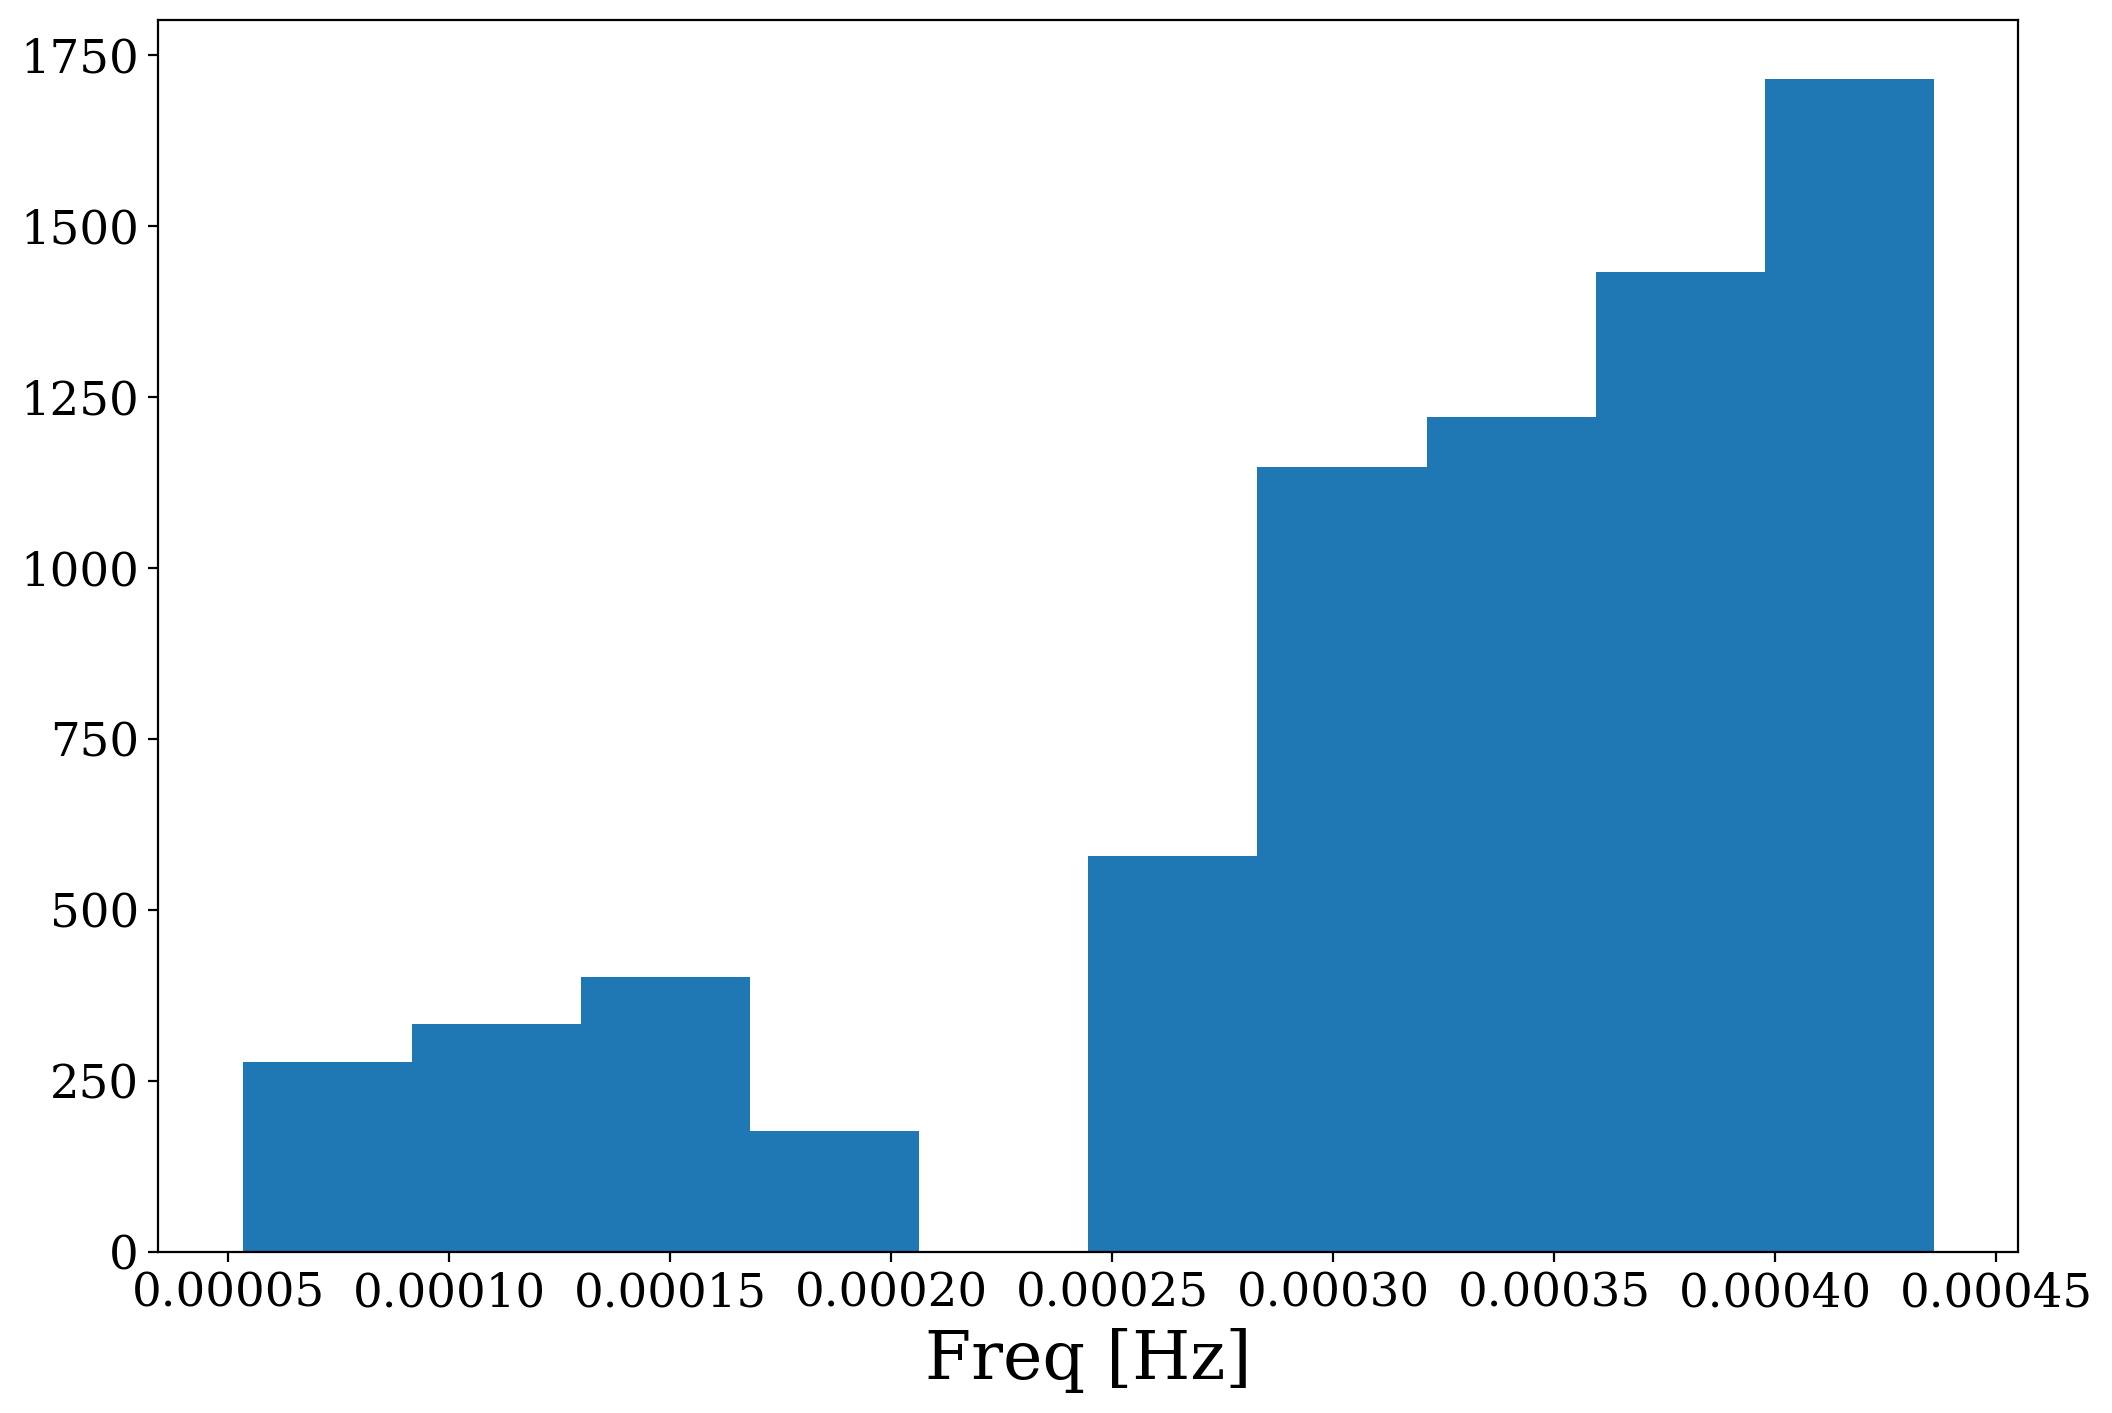

In [4]:
fhist = plt.hist(CV_pop[' f_gw[Hz]'])
plt.xlabel('Freq [Hz]')

Text(0.5, 0, 'Freq [Hz]')

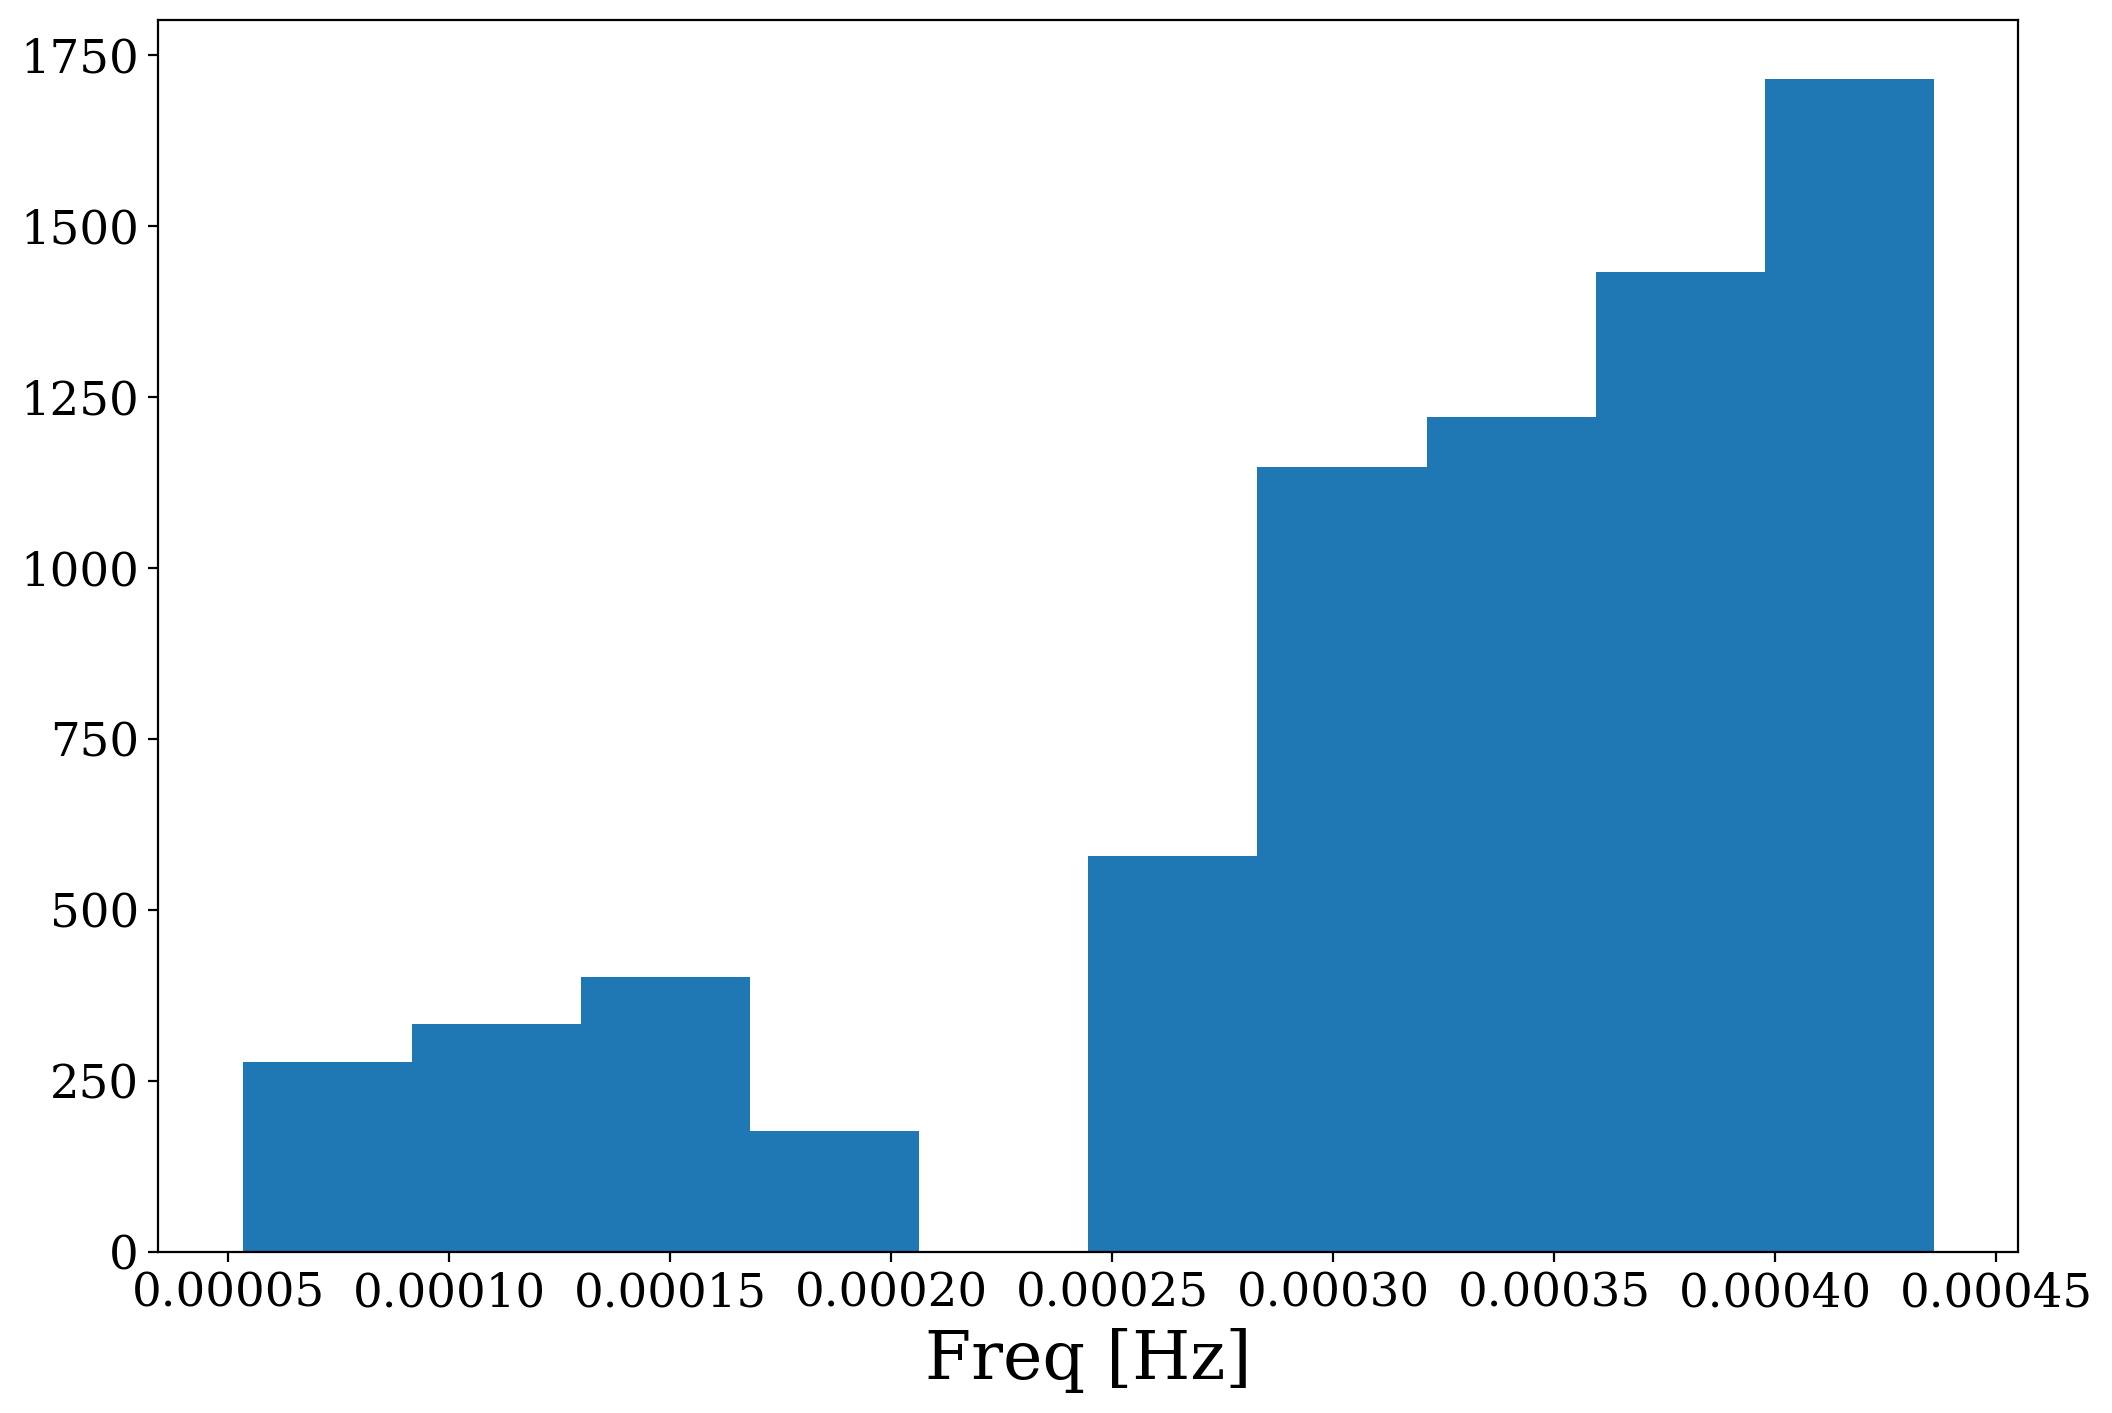

In [5]:
fhist = plt.hist(CV_pop[' f_gw[Hz]'], bins=10)
plt.xlabel('Freq [Hz]')

In [6]:
counts, bins = fhist[0], fhist[1]
print(counts)

[ 277.  333.  402.  177.    0.  579. 1147. 1221. 1433. 1715.]


In [7]:
# Grabbing indices for flo and fhi from seeing the edges of 0 region in counts
# ind_flo = np.where(counts==56)[0][0] # LSS bins = auto
ind_flo = np.where(counts==177)[0][0]
# ind_fhi = np.where(counts==97)[0][0] # LSS bins = auto
ind_fhi = np.where(counts==579)[0][0]


# getting flo, fhi, number of CVs in each
N_flo = counts[ind_flo]
N_fhi = counts[ind_fhi]

flo = bins[ind_flo]
fhi = bins[ind_fhi]

In [8]:
# LSS picking out the CVs at flo and fhi. will use flo ones to make chirp mass 
# dist. 
df = (flo-bins[ind_flo-1])
flo_CVs_ind = np.where((CV_pop[' f_gw[Hz]']>bins[ind_flo]) &
                    (CV_pop[' f_gw[Hz]']<bins[ind_flo]+df))[0]
print(flo_CVs_ind.shape)
fhi_CVs_ind = np.where((CV_pop[' f_gw[Hz]']>bins[ind_fhi]) &
                    (CV_pop[' f_gw[Hz]']<bins[ind_fhi]+df))[0]
print(fhi_CVs_ind.shape)

(177,)
(579,)


In [9]:
flo_CVs_ind

array([  40,   51,  191,  198,  247,  303,  388,  394,  411,  462,  478,
        482,  491,  511,  594,  672,  719,  748,  773,  809,  831,  842,
        843,  871,  900,  929, 1030, 1050, 1055, 1067, 1209, 1288, 1291,
       1305, 1315, 1325, 1341, 1365, 1417, 1468, 1506, 1512, 1525, 1578,
       1617, 1644, 1645, 1679, 1732, 1793, 1800, 1836, 1843, 1852, 1881,
       1889, 1946, 2009, 2038, 2069, 2200, 2207, 2213, 2262, 2264, 2311,
       2313, 2328, 2352, 2426, 2502, 2562, 2563, 2591, 2664, 2665, 2714,
       2832, 2848, 2911, 3044, 3120, 3124, 3181, 3252, 3269, 3535, 3542,
       3633, 3687, 3712, 3724, 3763, 3803, 3812, 3839, 3845, 3848, 3870,
       3879, 3893, 3973, 3981, 4031, 4037, 4048, 4104, 4125, 4147, 4152,
       4177, 4259, 4292, 4374, 4531, 4544, 4569, 4596, 4597, 4682, 4693,
       4706, 4720, 4733, 4781, 4799, 4920, 5051, 5066, 5091, 5099, 5201,
       5237, 5239, 5242, 5255, 5263, 5274, 5334, 5349, 5445, 5449, 5457,
       5461, 5522, 5530, 5550, 5597, 5599, 5682, 57

In [10]:
flo_CVs = CV_pop.iloc[flo_CVs_ind]
flo_mc = lw.utils.chirp_mass(flo_CVs['# m1[Msun]'] * u.Msun, flo_CVs[' m2[Msun]'] * u.Msun)


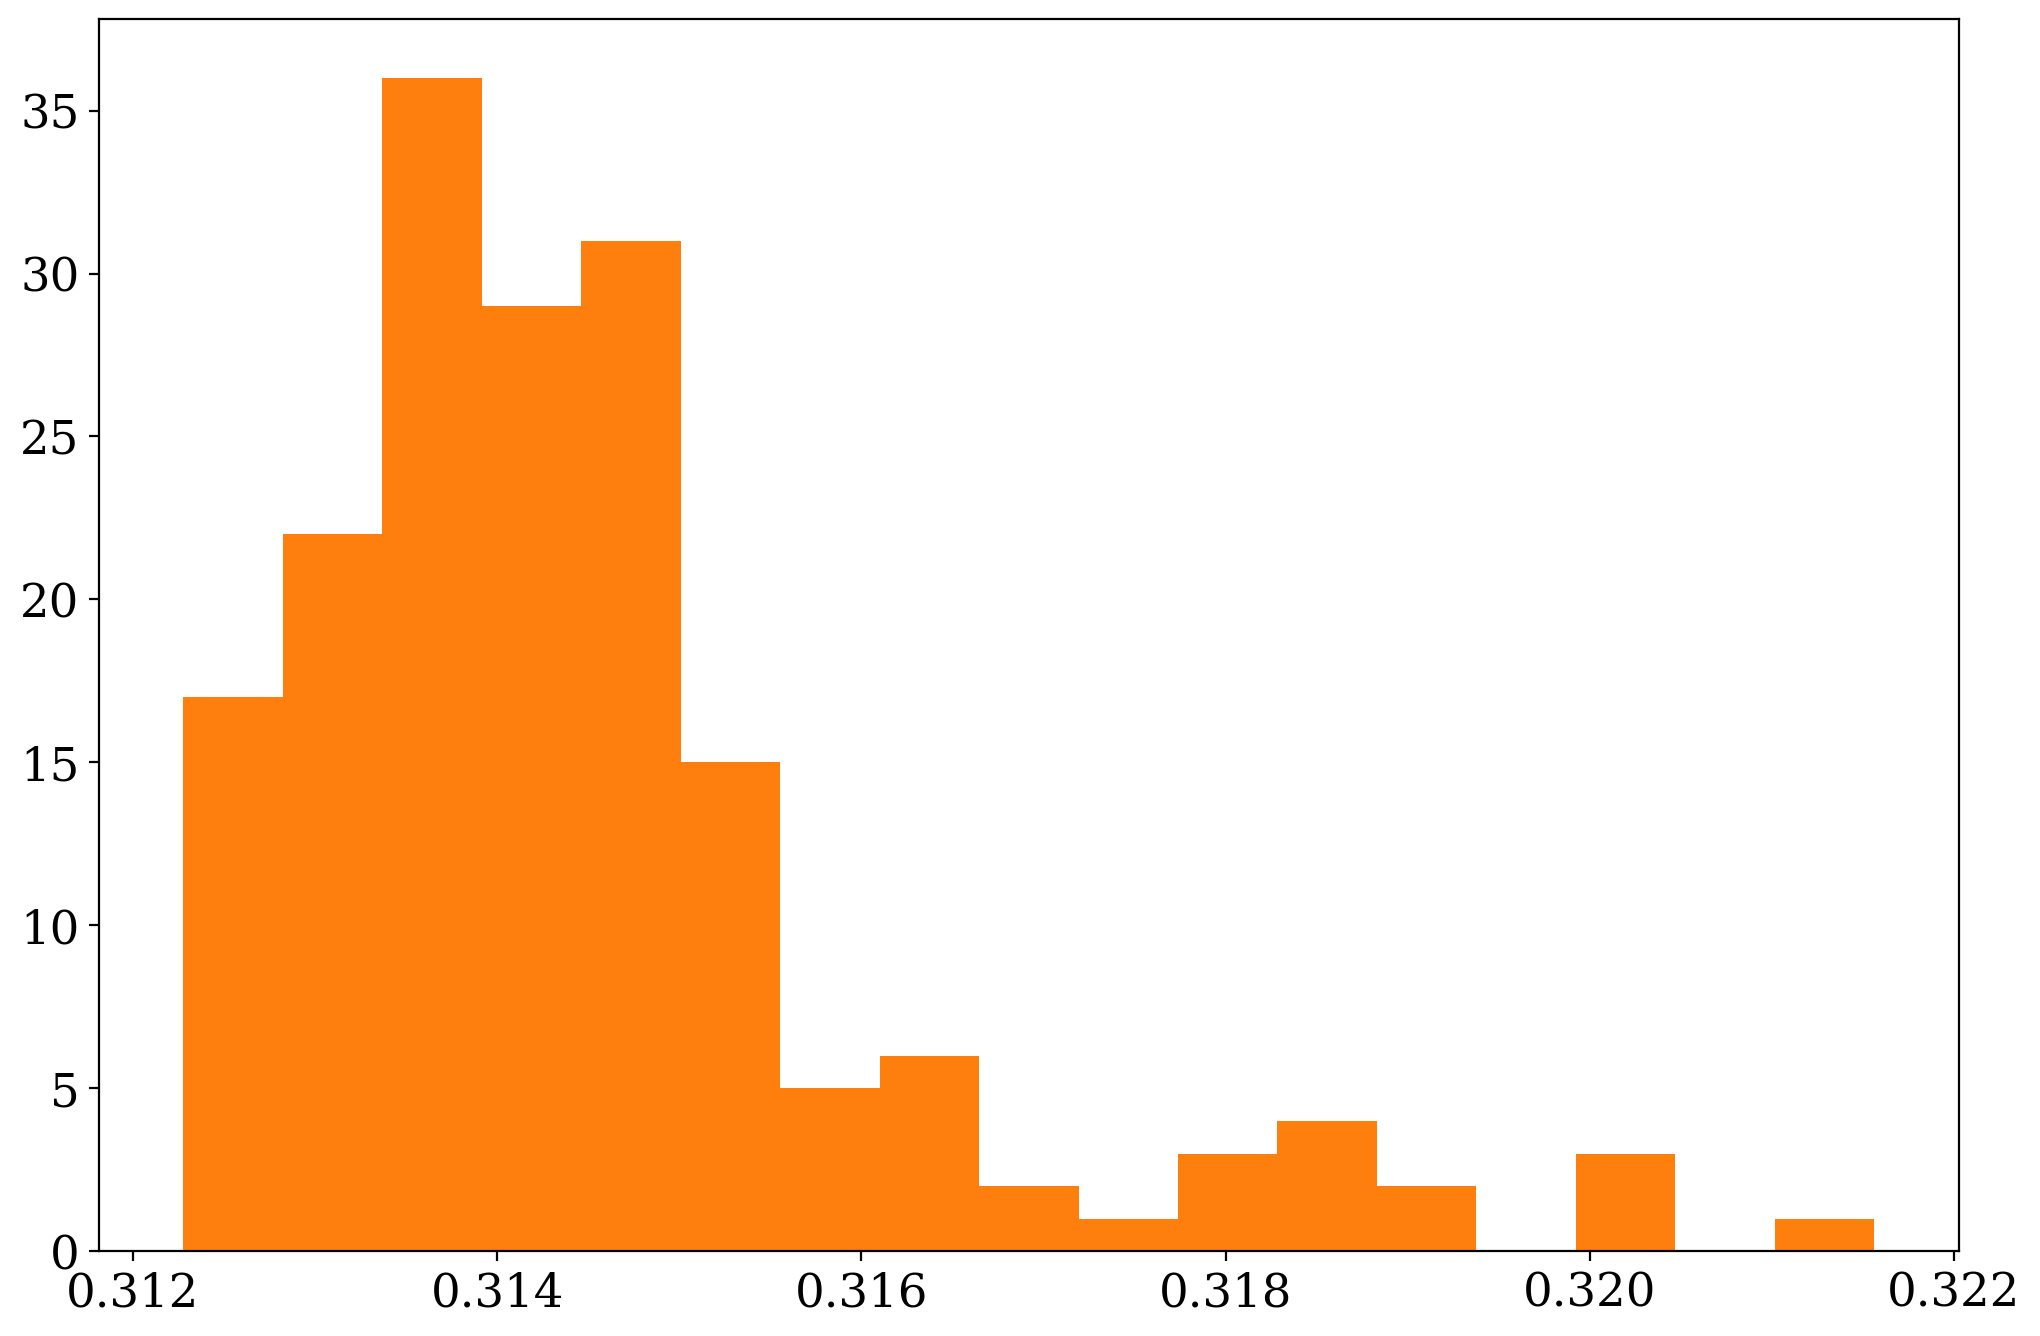

In [11]:
flo_mc_cts, flo_mc_bins = plt.hist(flo_mc, bins='auto')[0], plt.hist(flo_mc, bins='auto')[1]

(array([2., 0., 5., 0., 0., 2., 2., 1., 1., 1., 3., 4., 1., 5., 2., 3., 2.,
        0., 3., 2., 2., 3., 2., 3., 0., 3., 7., 1., 7., 4., 3., 4., 4., 4.,
        3., 2., 1., 2., 2., 3., 3., 4., 2., 1., 5., 3., 3., 3., 2., 3., 3.,
        4., 2., 0., 2., 2., 1., 0., 1., 3., 1., 2., 1., 0., 1., 1., 0., 1.,
        0., 0., 1., 1., 0., 2., 0., 1., 0., 0., 0., 1., 0., 0., 1., 2., 0.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 0., 1., 0., 0., 1.,
        0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 1.]),
 array([0.31227743, 0.31232989, 0.31238234, 0.3124348 , 0.31248725,
        0.31253971, 0.31259216, 0.31264462, 0.31269708, 0.31274953,
        0.31280199, 0.31285444, 0.3129069 , 0.31295935, 0.31301181

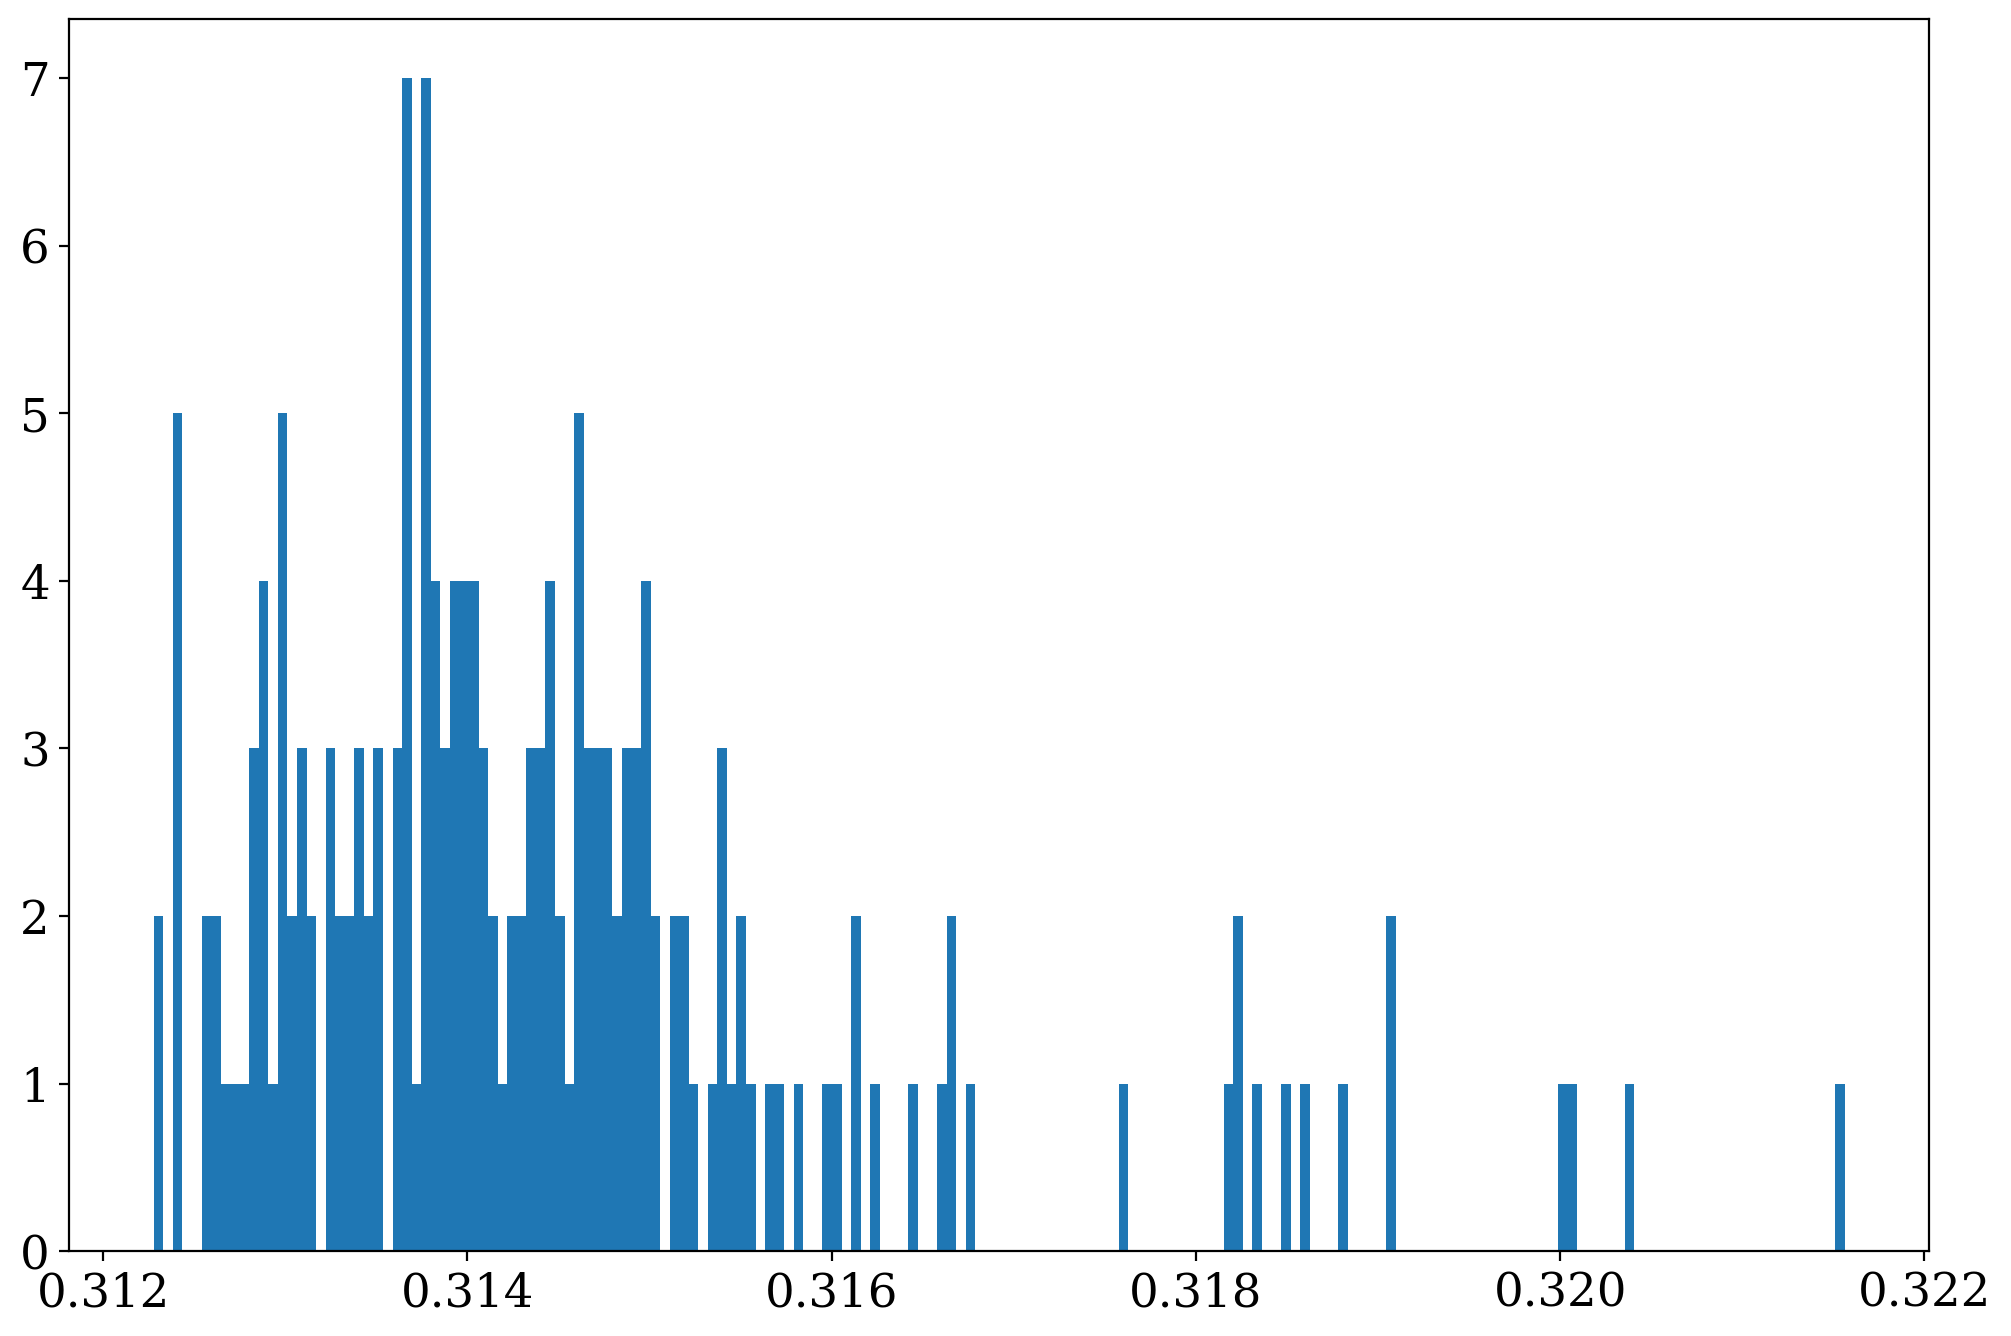

In [12]:
plt.hist(flo_mc, bins=len(flo_mc))

## now make the KDE of the flo chirp mass dist

In [13]:
kern = 'gaussian'

bwrange = np.linspace(1e-9, 1e-3, 1000) # Test 100 bandwidths from 0.1 to 1.0
K = 20 # Do 20-fold cross validation
grid = GridSearchCV(KernelDensity(kernel=kern), {'bandwidth': bwrange}, cv=K) # Try each bandwidth with K-folds
grid.fit(np.array(flo_mc)[:, None]) #Fit the histogram data that we started the lecture with.
h_opt = grid.best_params_['bandwidth']
print(h_opt)

0.0006056060000000001


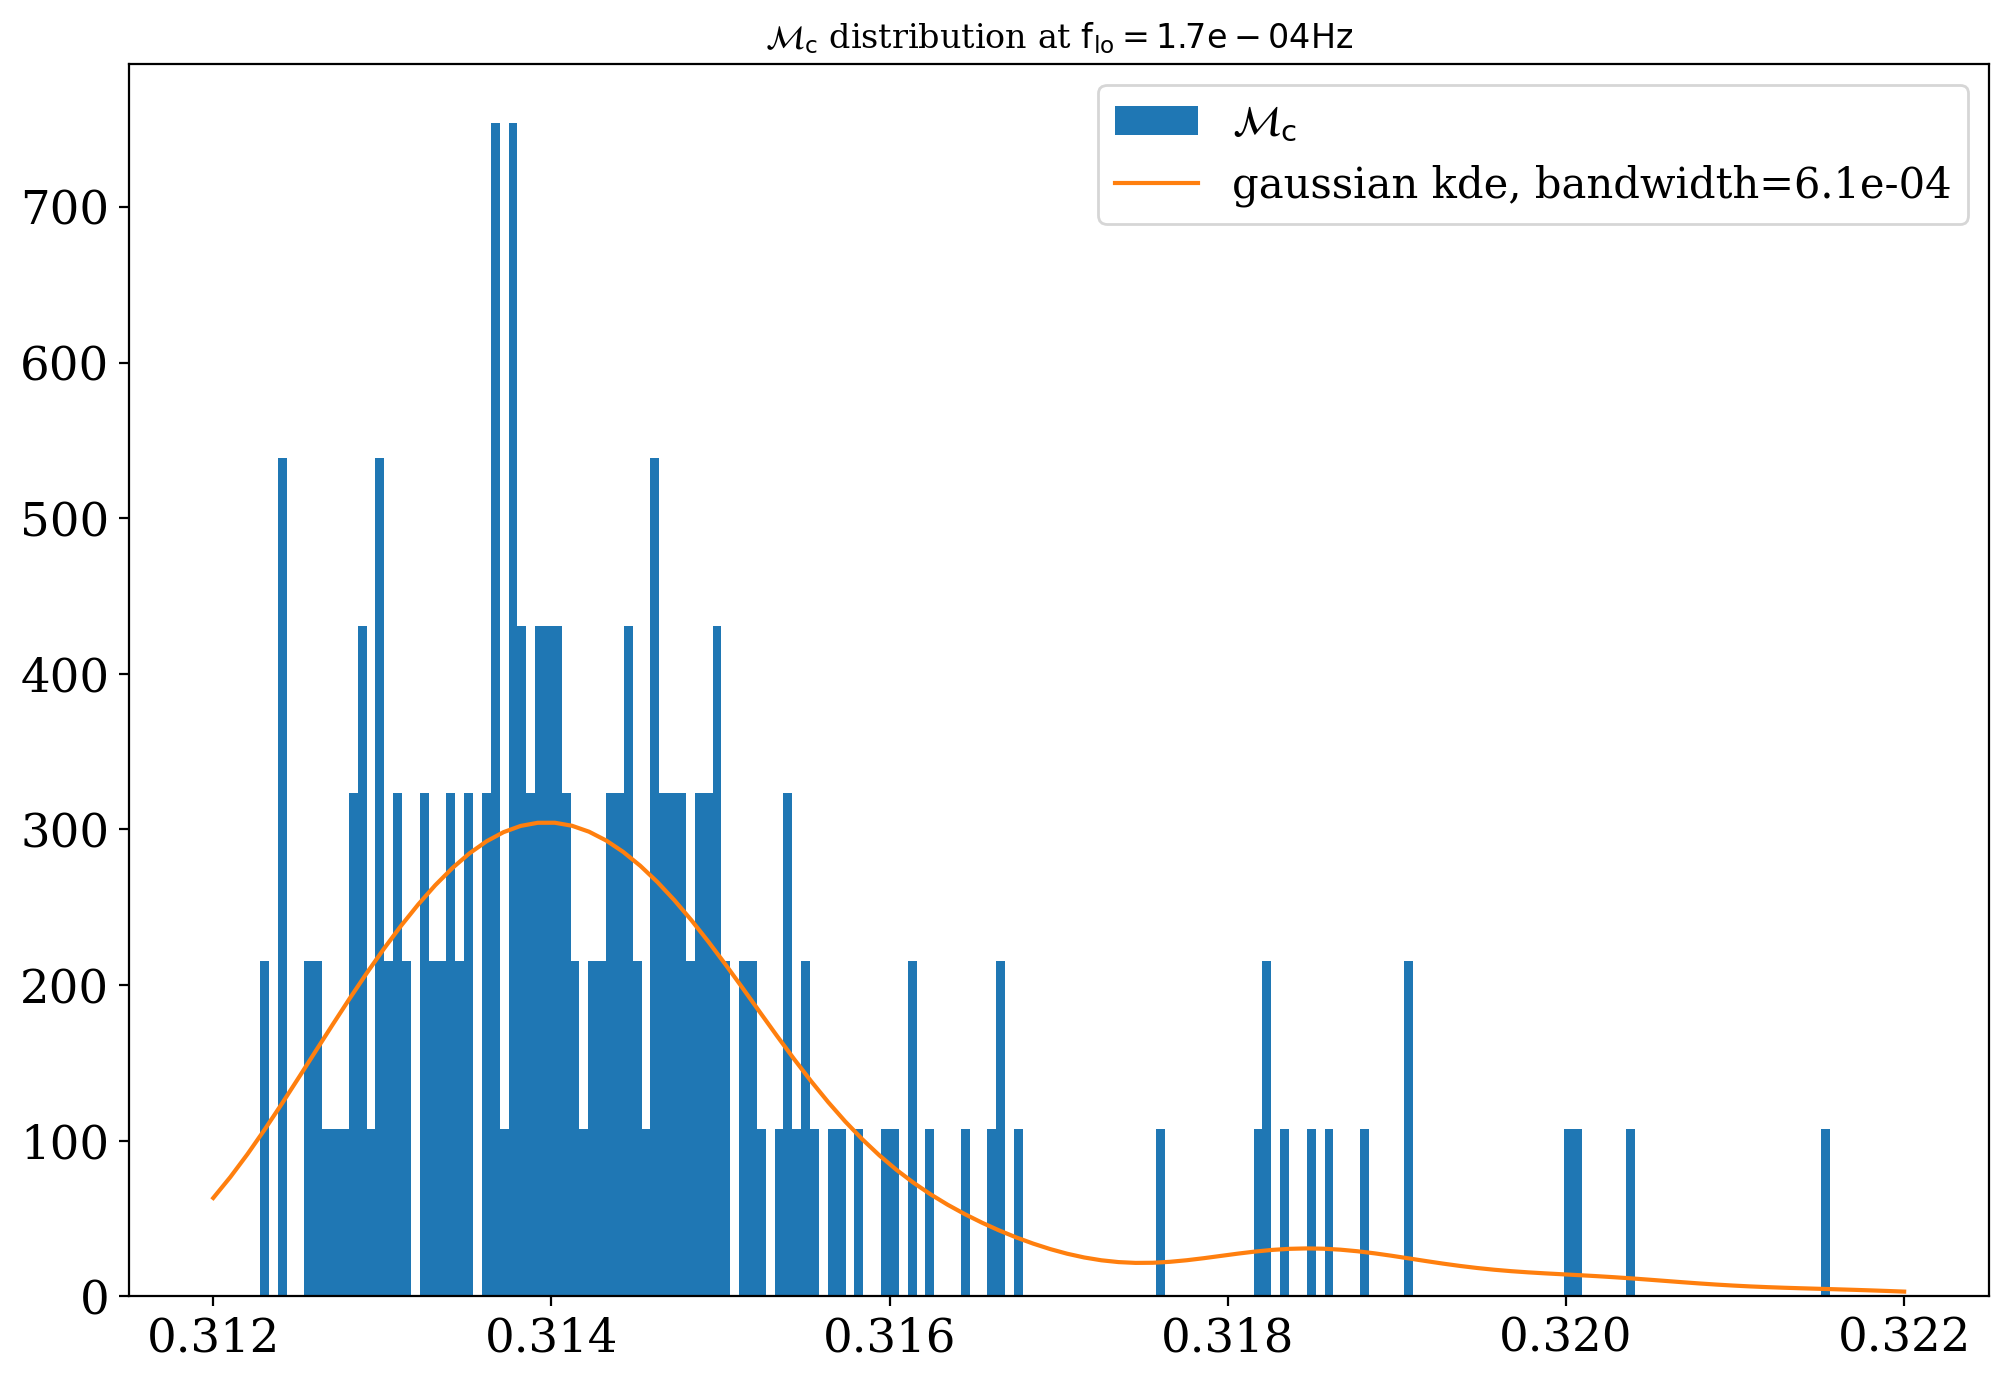

In [14]:
plt.title(rf'$\mathcal{{M}}_{{\rm c}}$ distribution at $\rm f_{{\rm lo}} = {flo:.1e} Hz$')
plt.hist(flo_mc, bins=len(flo_mc), label=r'$\mathcal{M}_{\rm c}$', density=True)
mc_range = np.linspace(0.312, 0.322, 100)
mc_kde = KernelDensity(kernel=kern, bandwidth=h_opt).fit(np.array(flo_mc)[:, None])
log_dens = mc_kde.score_samples(mc_range[:, None])
# plt.plot(mc_range, np.exp(log_dens)*.01, label=f'cosine kde, bandwidth={h_opt:.1e}')
plt.plot(mc_range, np.exp(log_dens), label=f'{kern} kde, bandwidth={h_opt:.1e}')

plt.legend(fontsize=15)

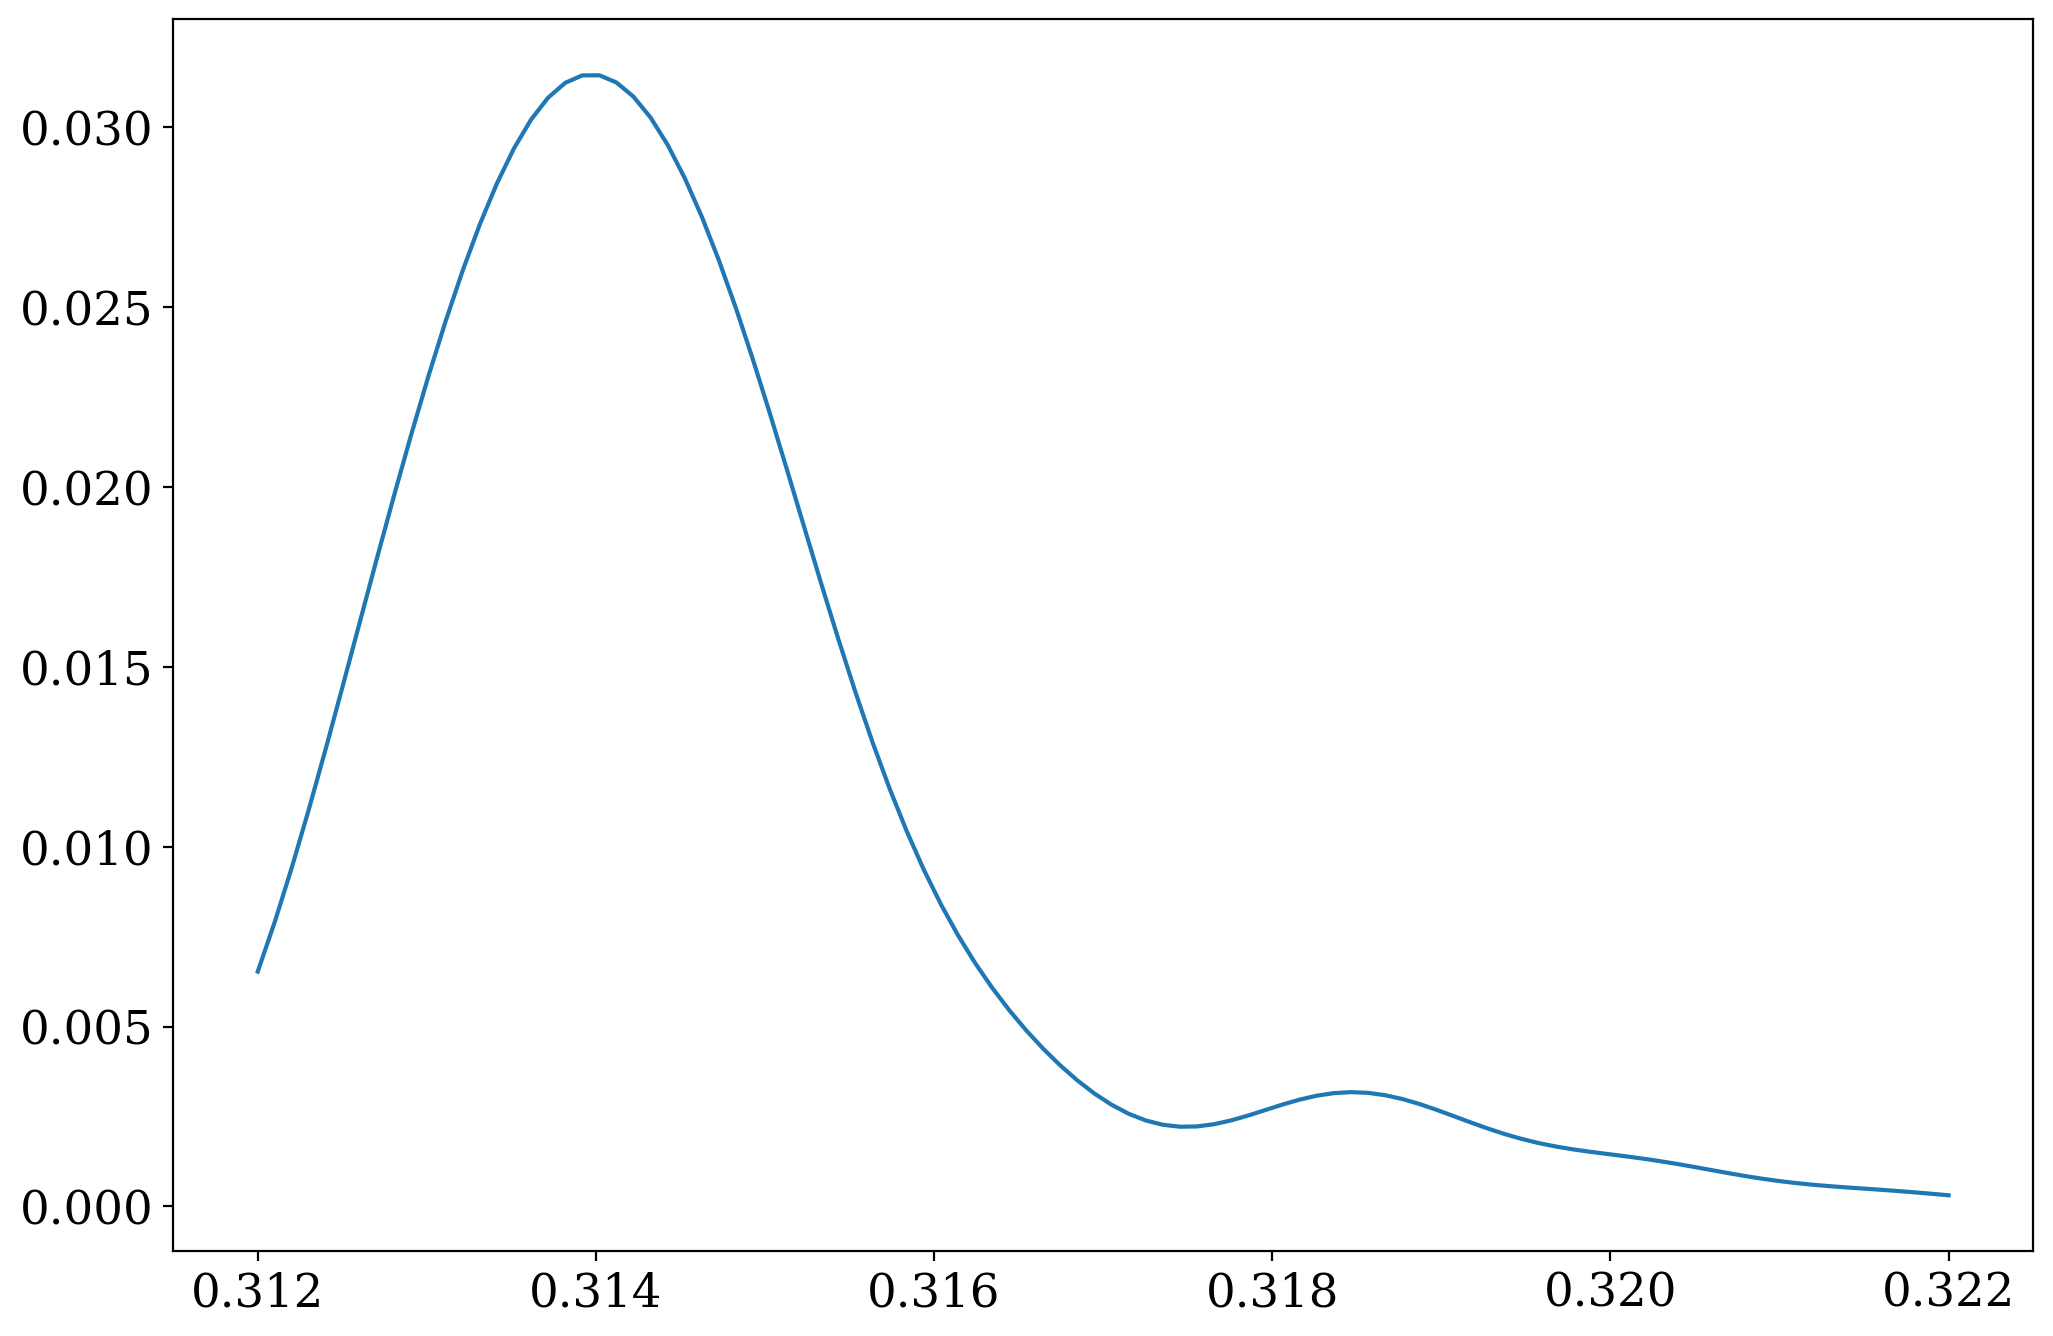

In [15]:
# normalize
plt.plot(mc_range, np.exp(log_dens)/np.sum(np.exp(log_dens)), label=f'{kern} kde, bandwidth={h_opt:.1e}')

In [16]:
# fit the above likelihood values with interpolation 
mc_flo_interp = interpolate.interp1d(mc_range, np.exp(log_dens)/np.sum(np.exp(log_dens)))

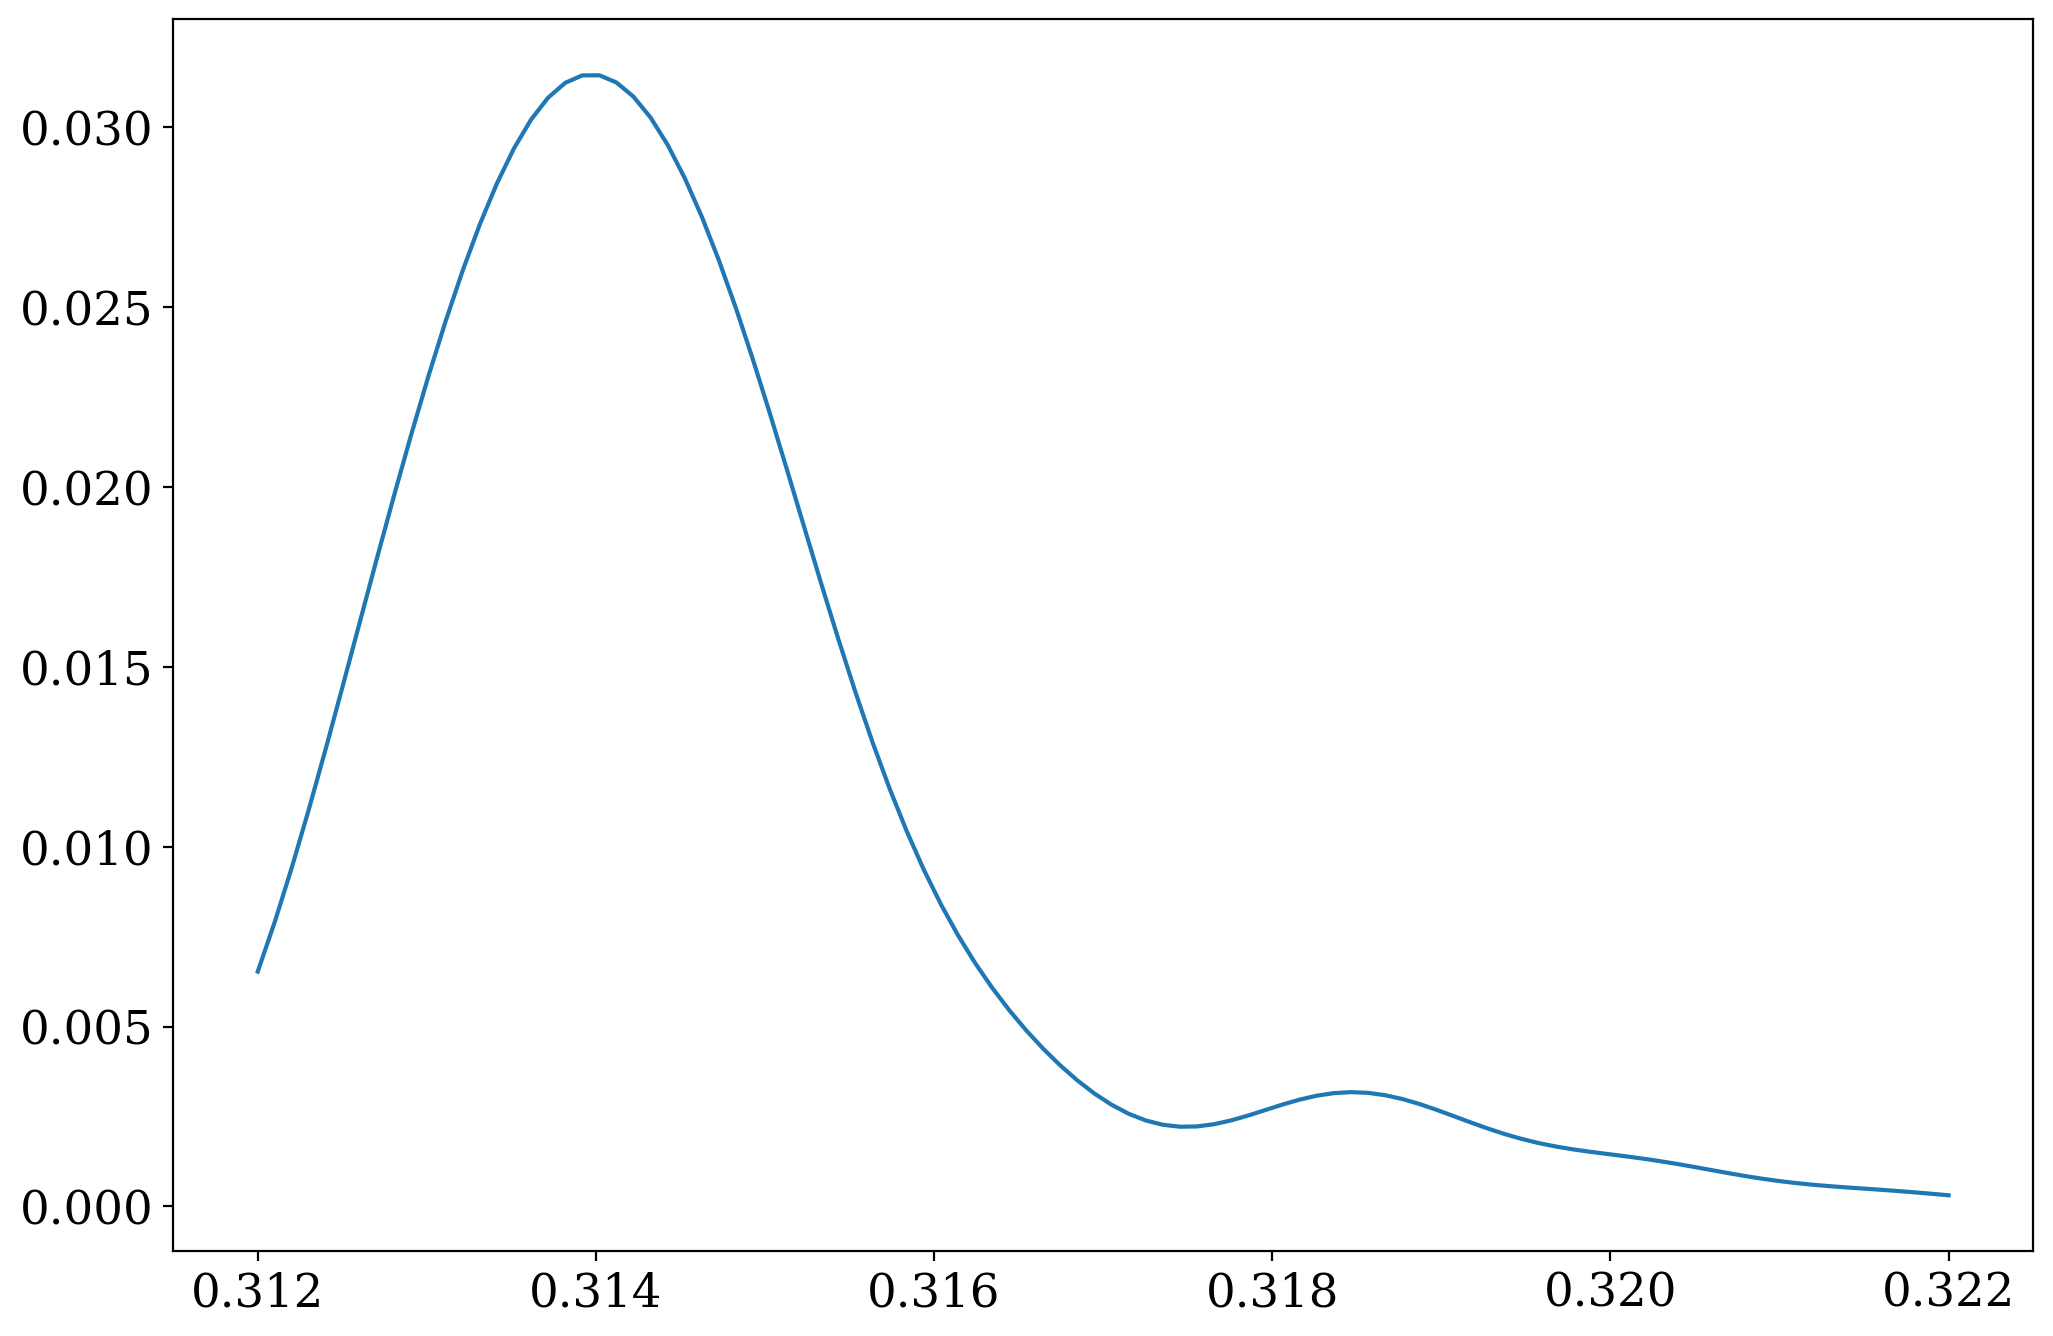

In [17]:
plt.plot(mc_range, mc_flo_interp(mc_range))

In [18]:
apyconst.M_sun

<<class 'astropy.constants.iau2015.IAU2015'> name='Solar mass' value=1.988409870698051e+30 uncertainty=4.468805426856864e+25 unit='kg' reference='IAU 2015 Resolution B 3 + CODATA 2018'>

In [19]:
normfact = 1.3843284291803618e+34

## testing KDE bandwidth items - how does binning affect things

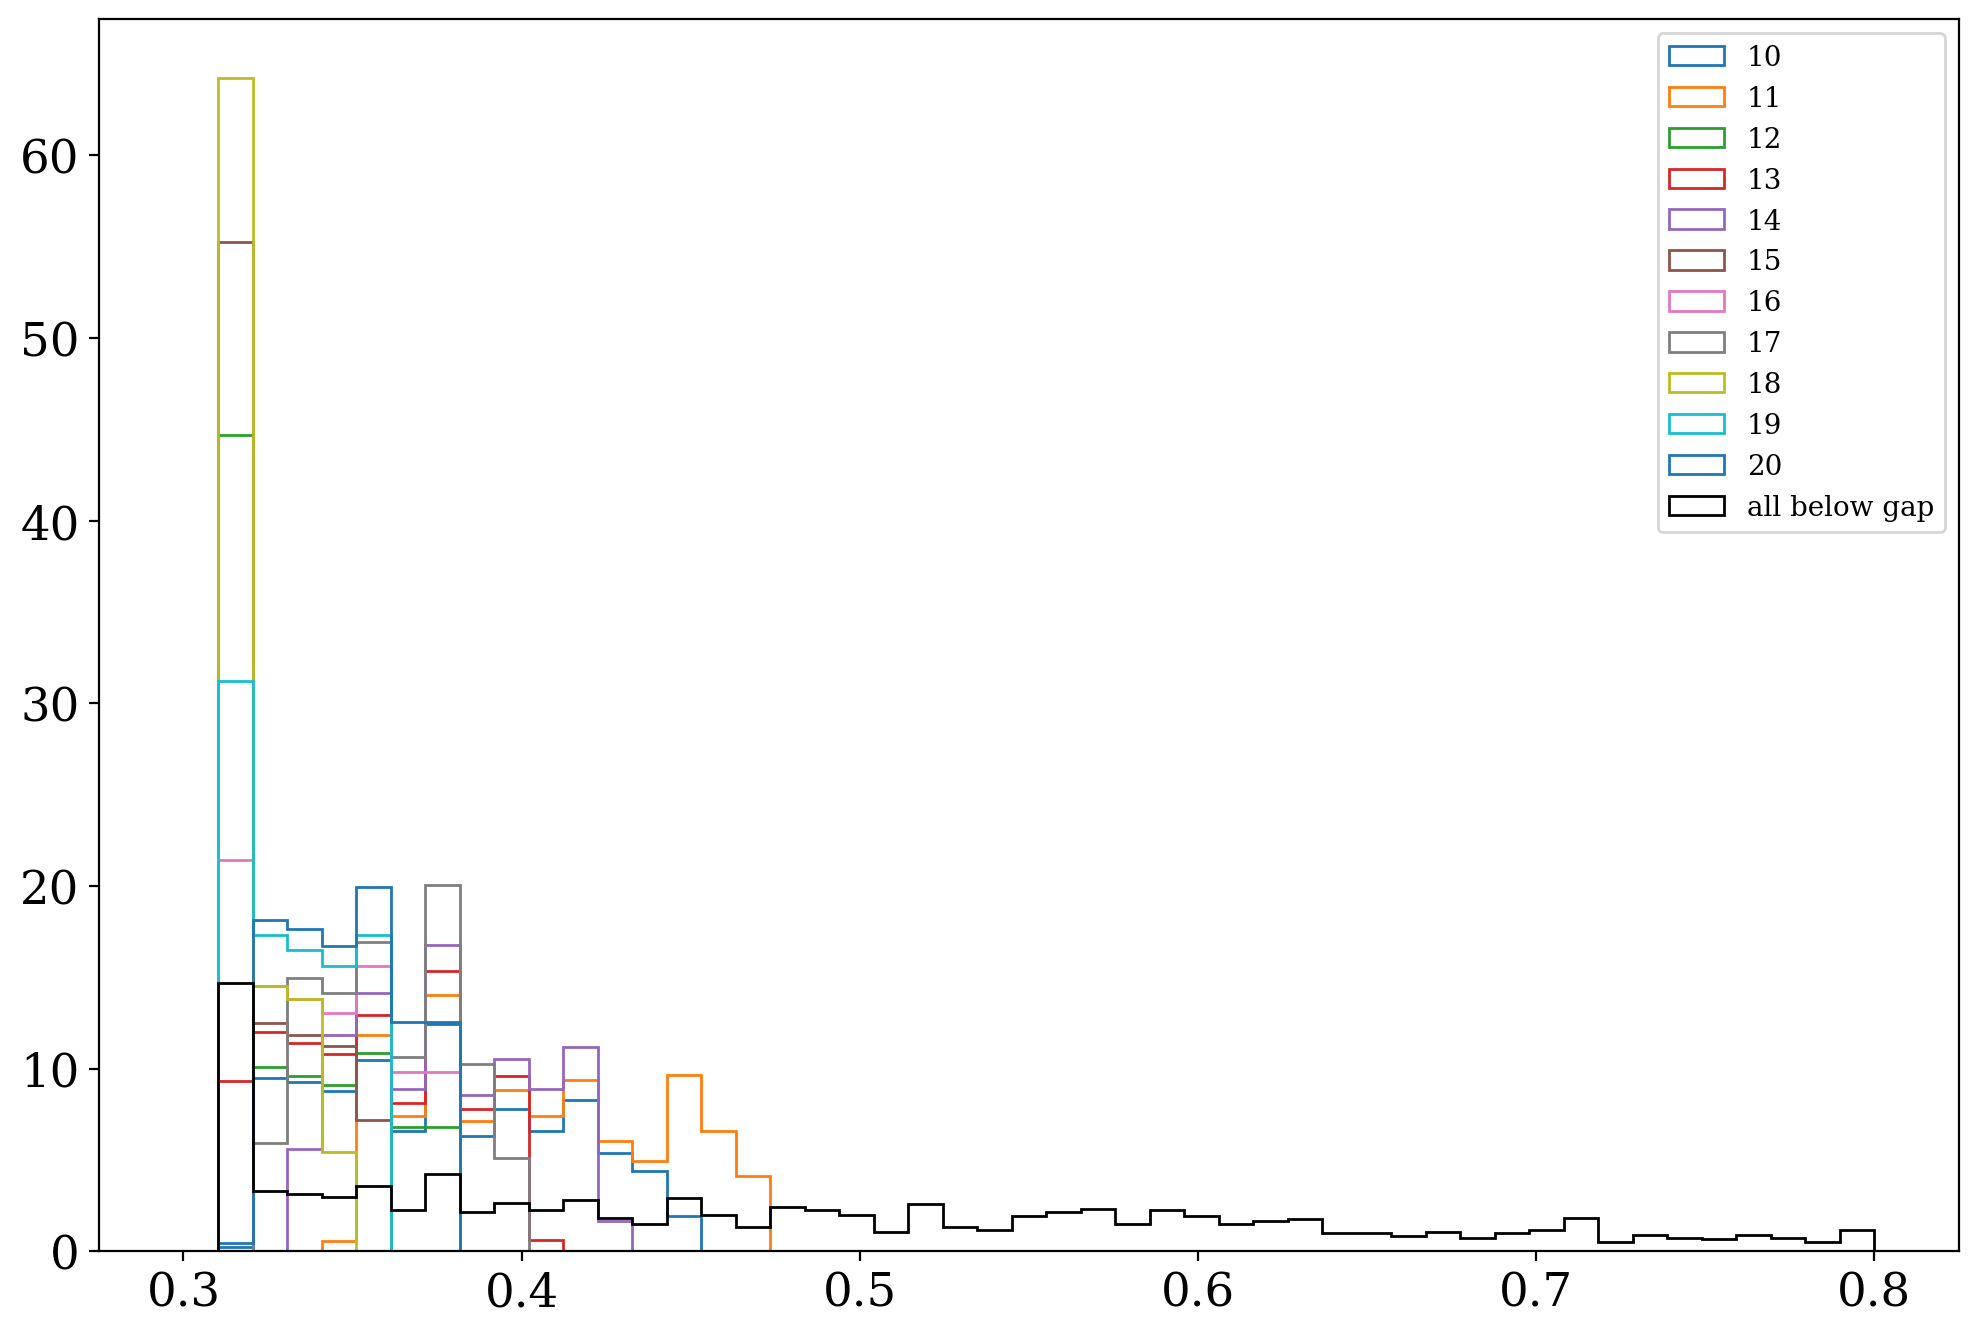

In [23]:
holdNbns = np.linspace(0.3, 0.8, 50)
for Nbns in range(10, 21):
    countsN, binsN = np.histogram(CV_pop[' f_gw[Hz]'], bins=Nbns)
    df = binsN[1]-binsN[0]
    #plt.hist(CV_pop[' f_gw[Hz]'], bins=Nbns)

    emgap_inds = np.where(countsN==0)[0]
    fprime_inds = emgap_inds[0]-1 # fprime = flo
    fprime_inds = np.argmax(countsN[:emgap_inds[0]]) # fprime = max before gap
    fprime_CV_inds = np.where((CV_pop[' f_gw[Hz]']>binsN[fprime_inds]) &
                        (CV_pop[' f_gw[Hz]']<binsN[fprime_inds]+df))[0]

    #print(countsN[fprime_inds], len(fprime_CV_inds))
    # LSS or we can do all the CVs before the em gap
    CV_belowgap_inds = np.where(CV_pop[' f_gw[Hz]']<binsN[emgap_inds[0]])[0]

    fprime_CVs = CV_pop.iloc[fprime_CV_inds]
    CV_belowgap = CV_pop.iloc[CV_belowgap_inds]
    fprime_mc = lw.utils.chirp_mass(fprime_CVs['# m1[Msun]'] * u.Msun, fprime_CVs[' m2[Msun]'] * u.Msun)
    CV_belowgap_mc = lw.utils.chirp_mass(CV_belowgap['# m1[Msun]'] * u.Msun, CV_belowgap[' m2[Msun]'] * u.Msun)

    plt.hist(fprime_mc, bins=holdNbns, histtype='step', label=f'{Nbns}', density=True)

plt.hist(CV_belowgap_mc, bins=holdNbns, histtype='step', label='all below gap', color='k', density=True)
plt.legend(fontsize='medium')
plt.show()

0.0006105405405405406


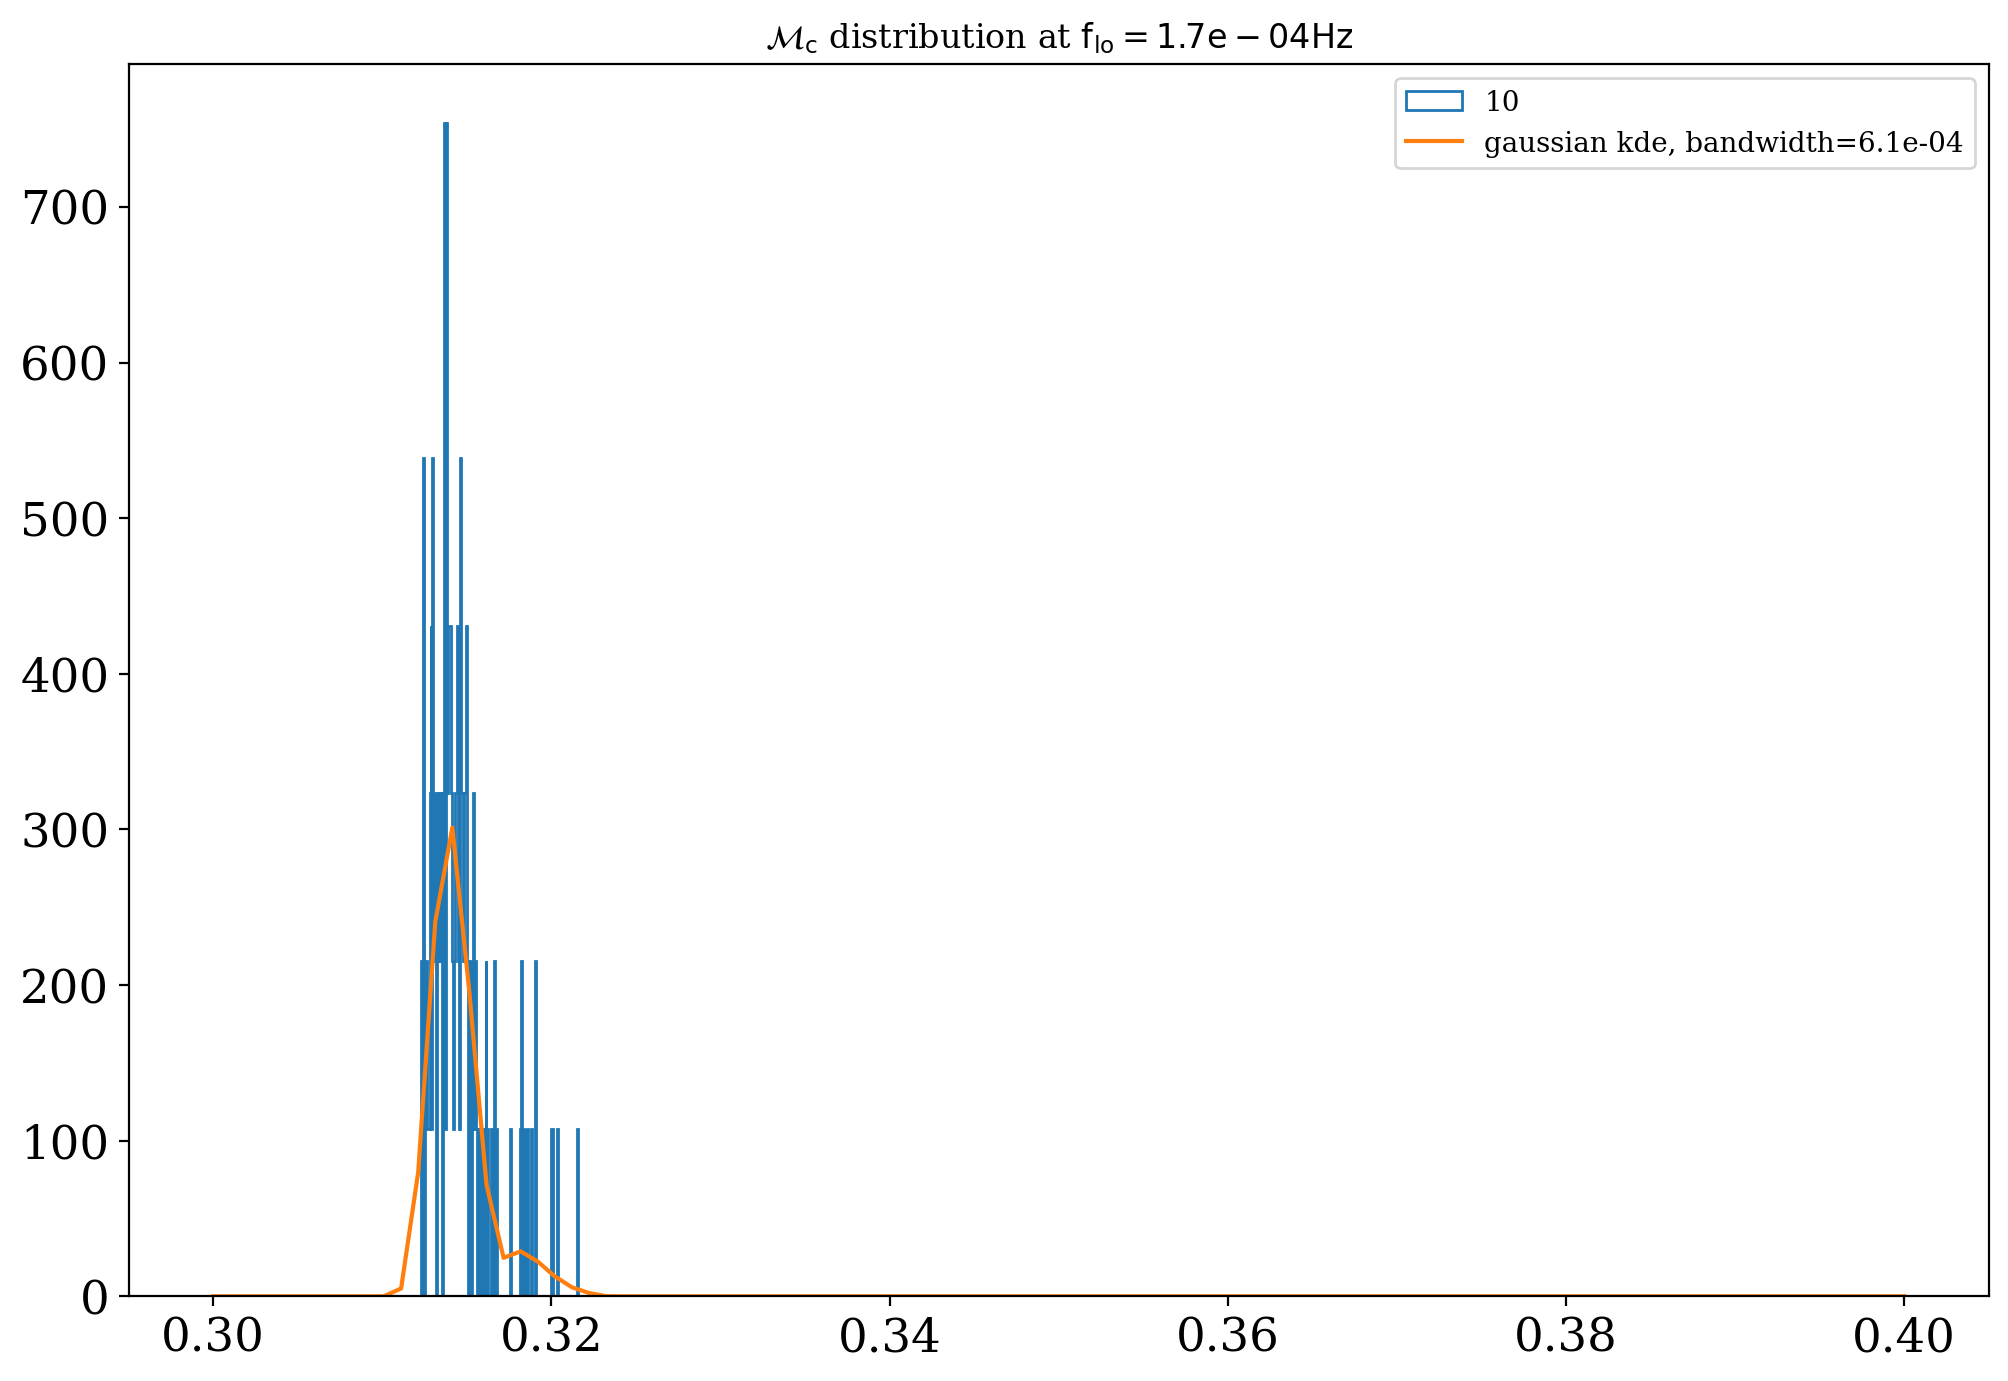

0.0006105405405405406


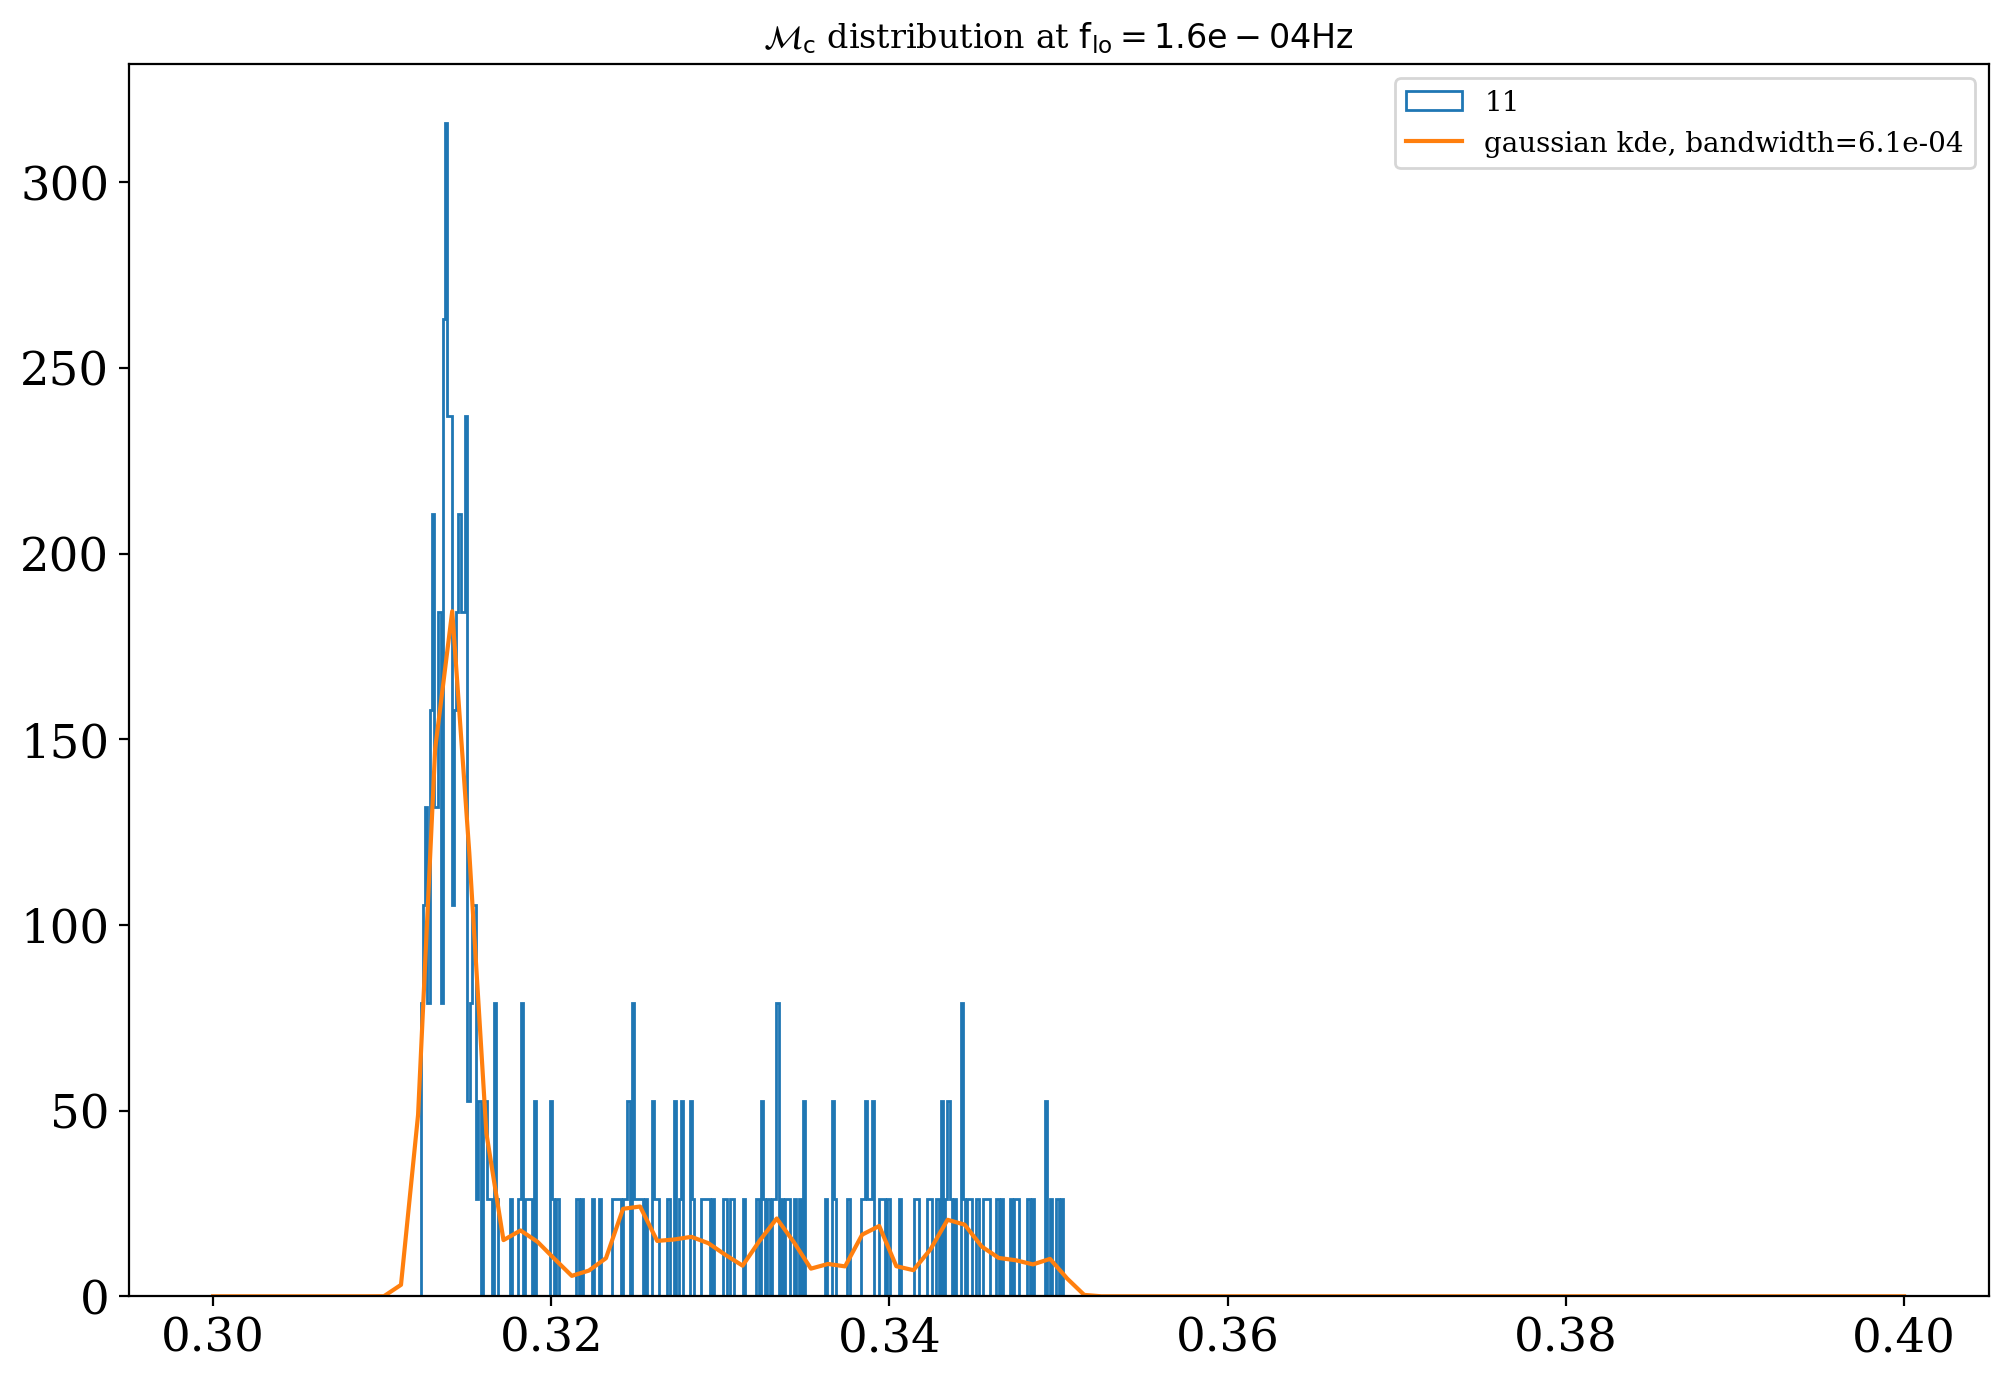

0.0006105405405405406


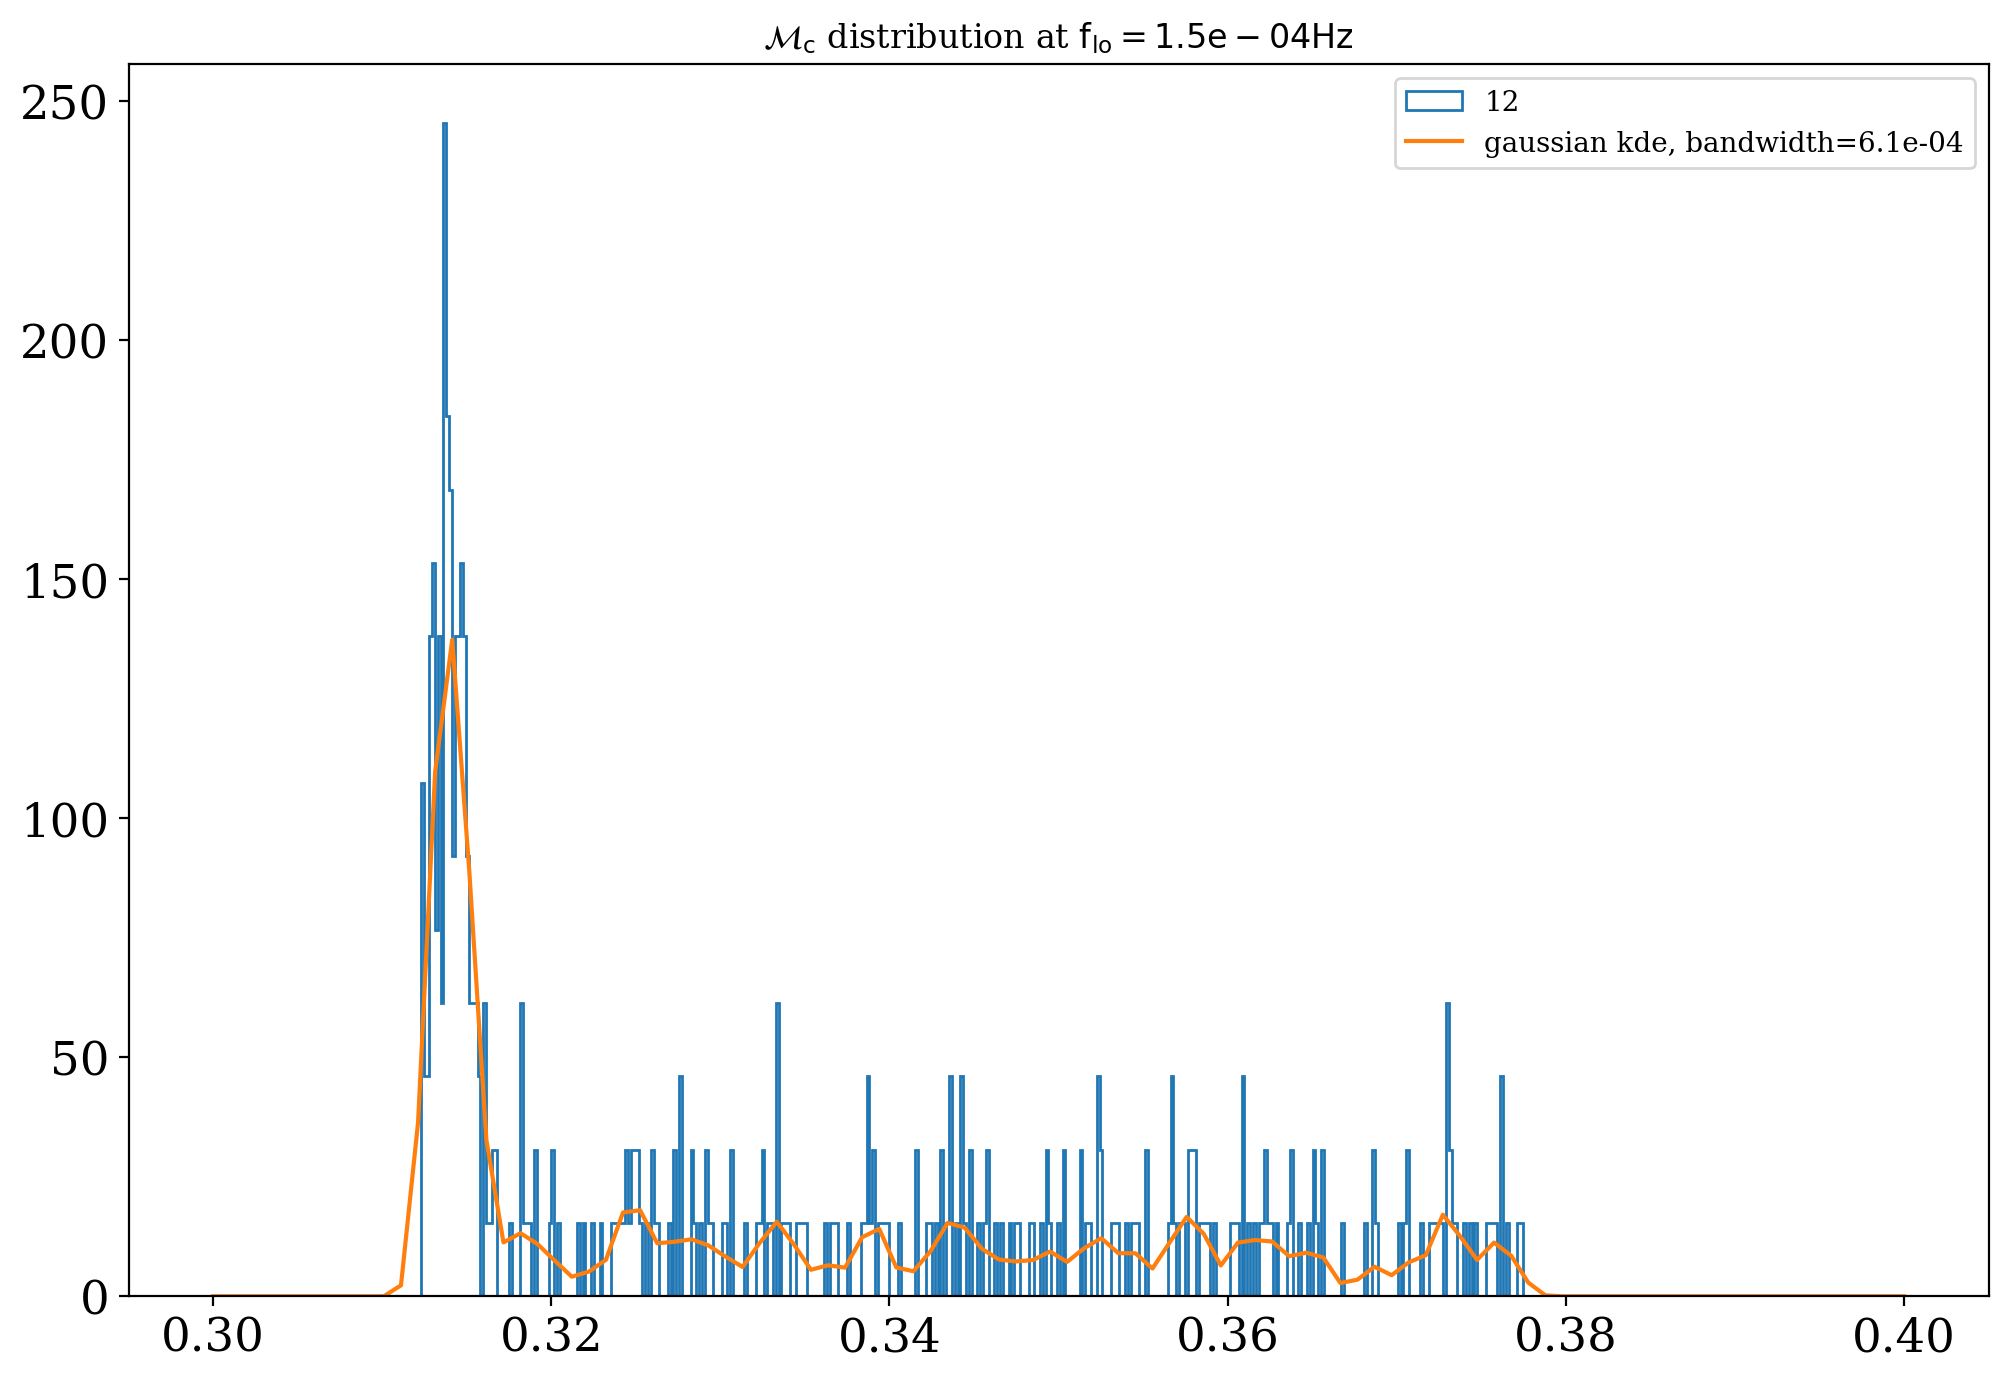

0.0003102702702702703


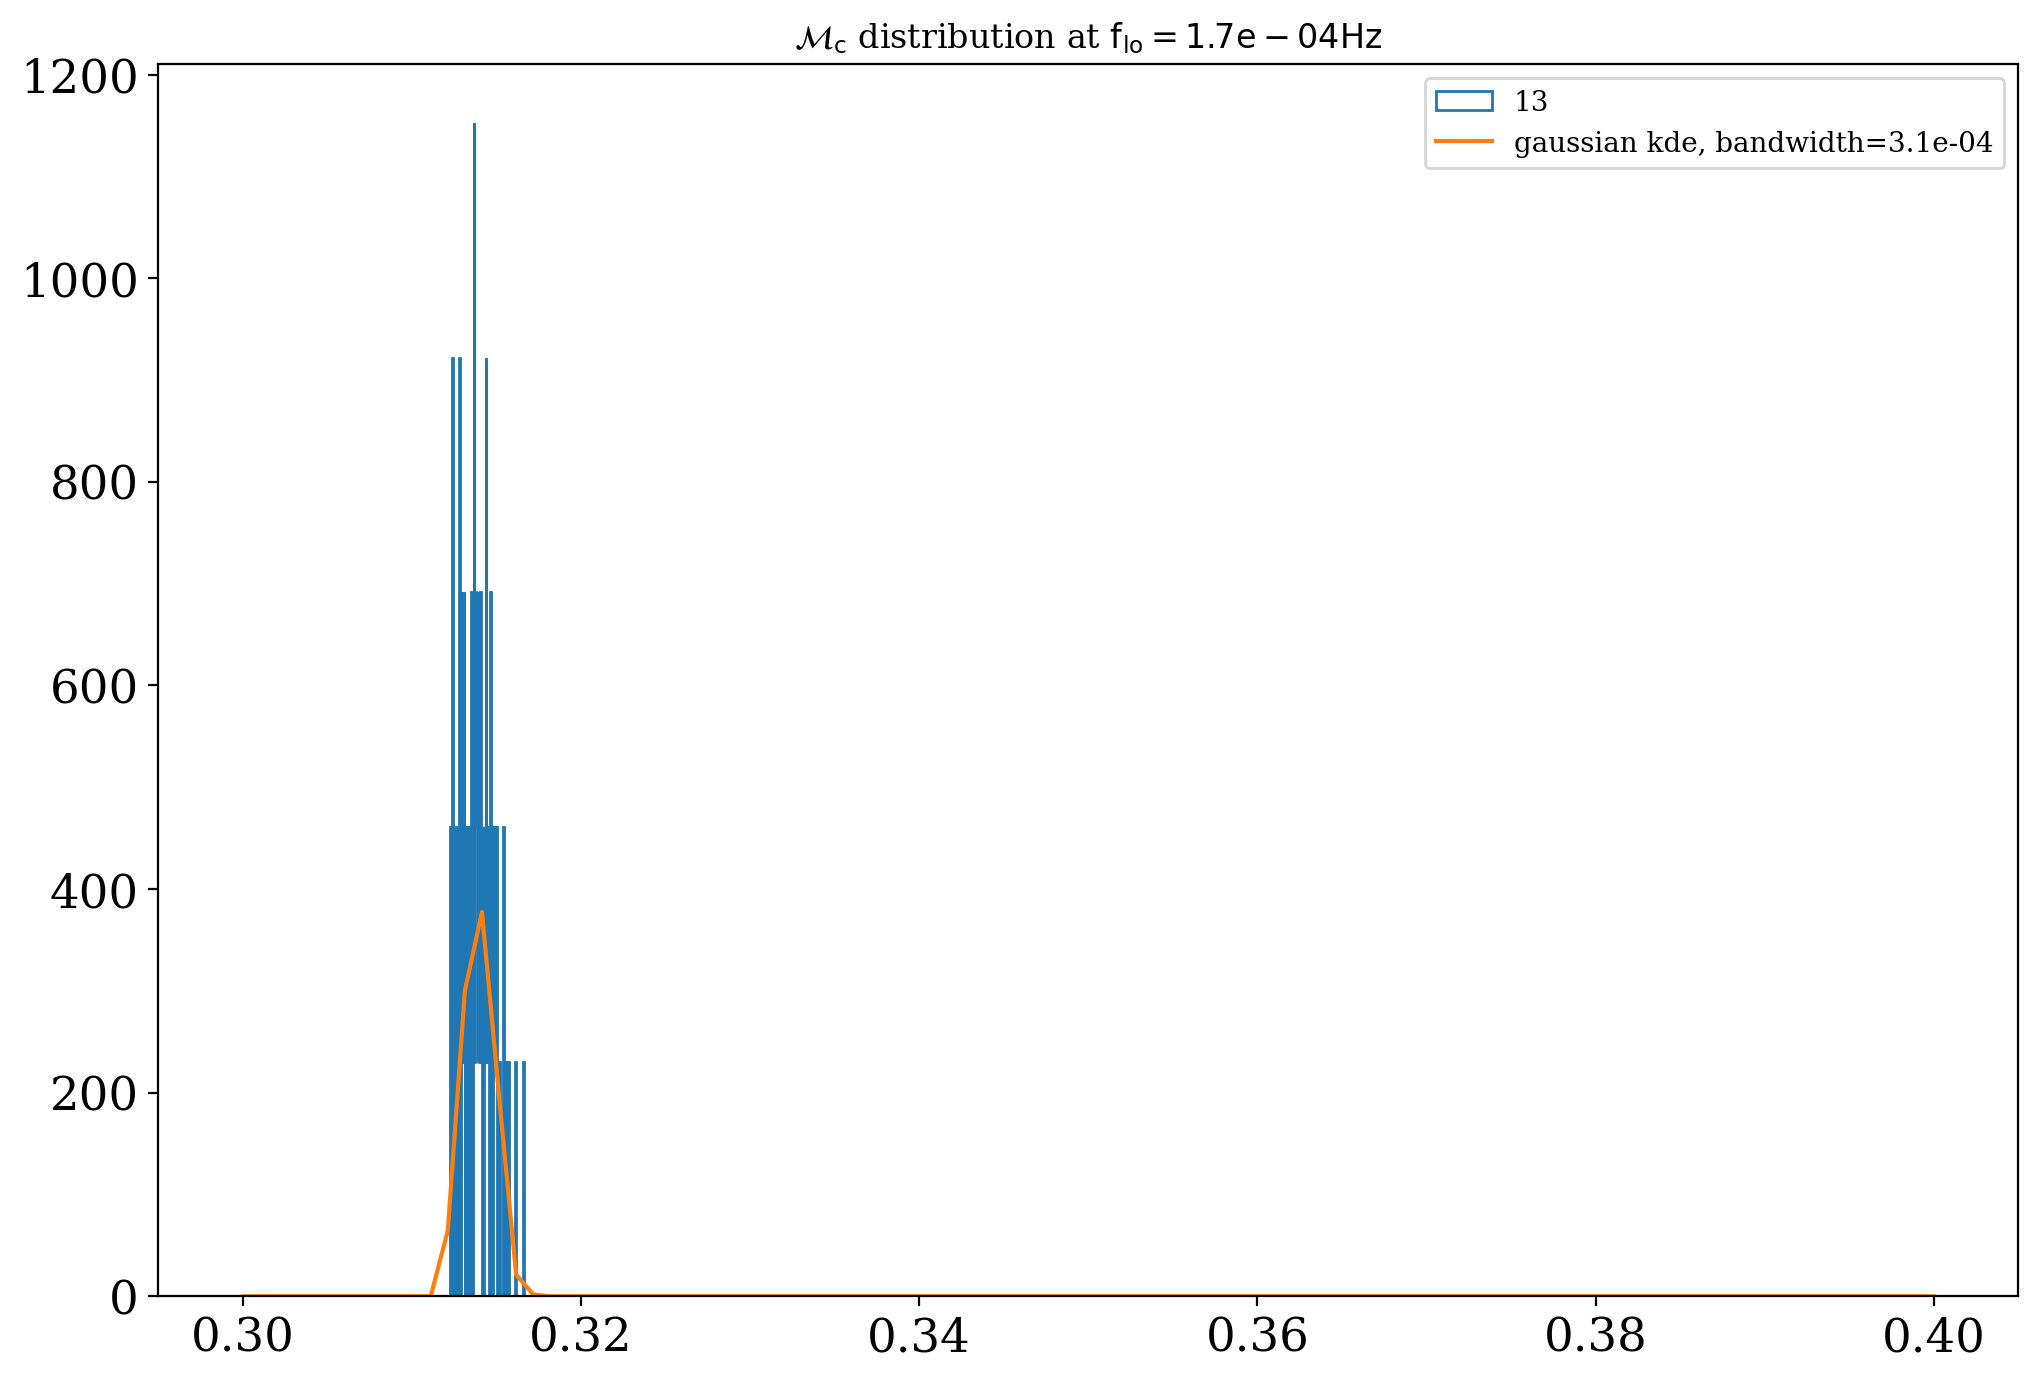

0.0006105405405405406


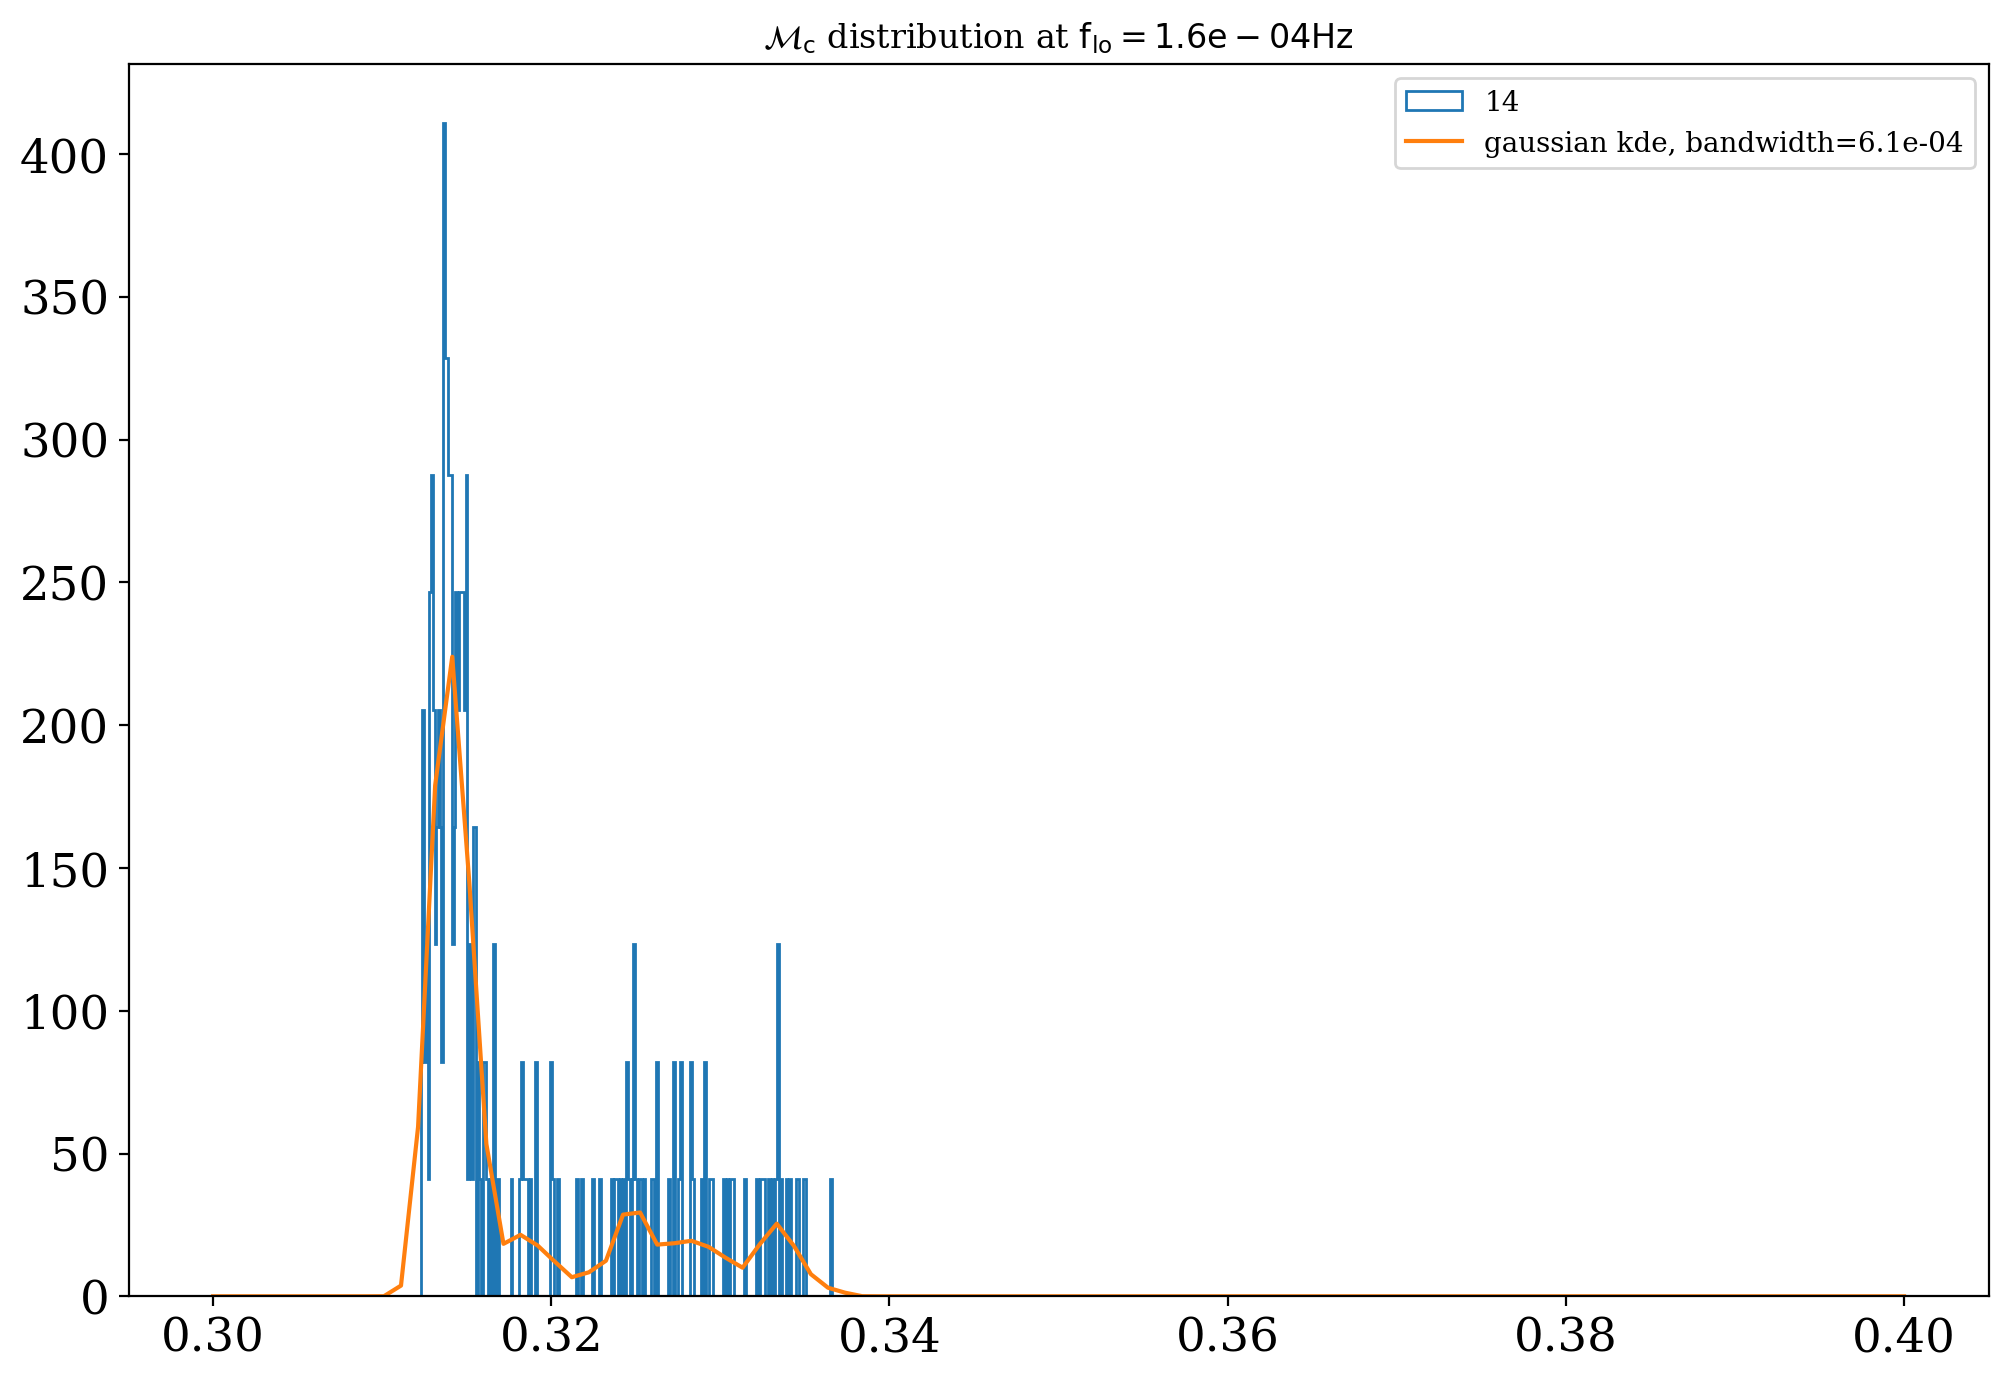

0.0006105405405405406


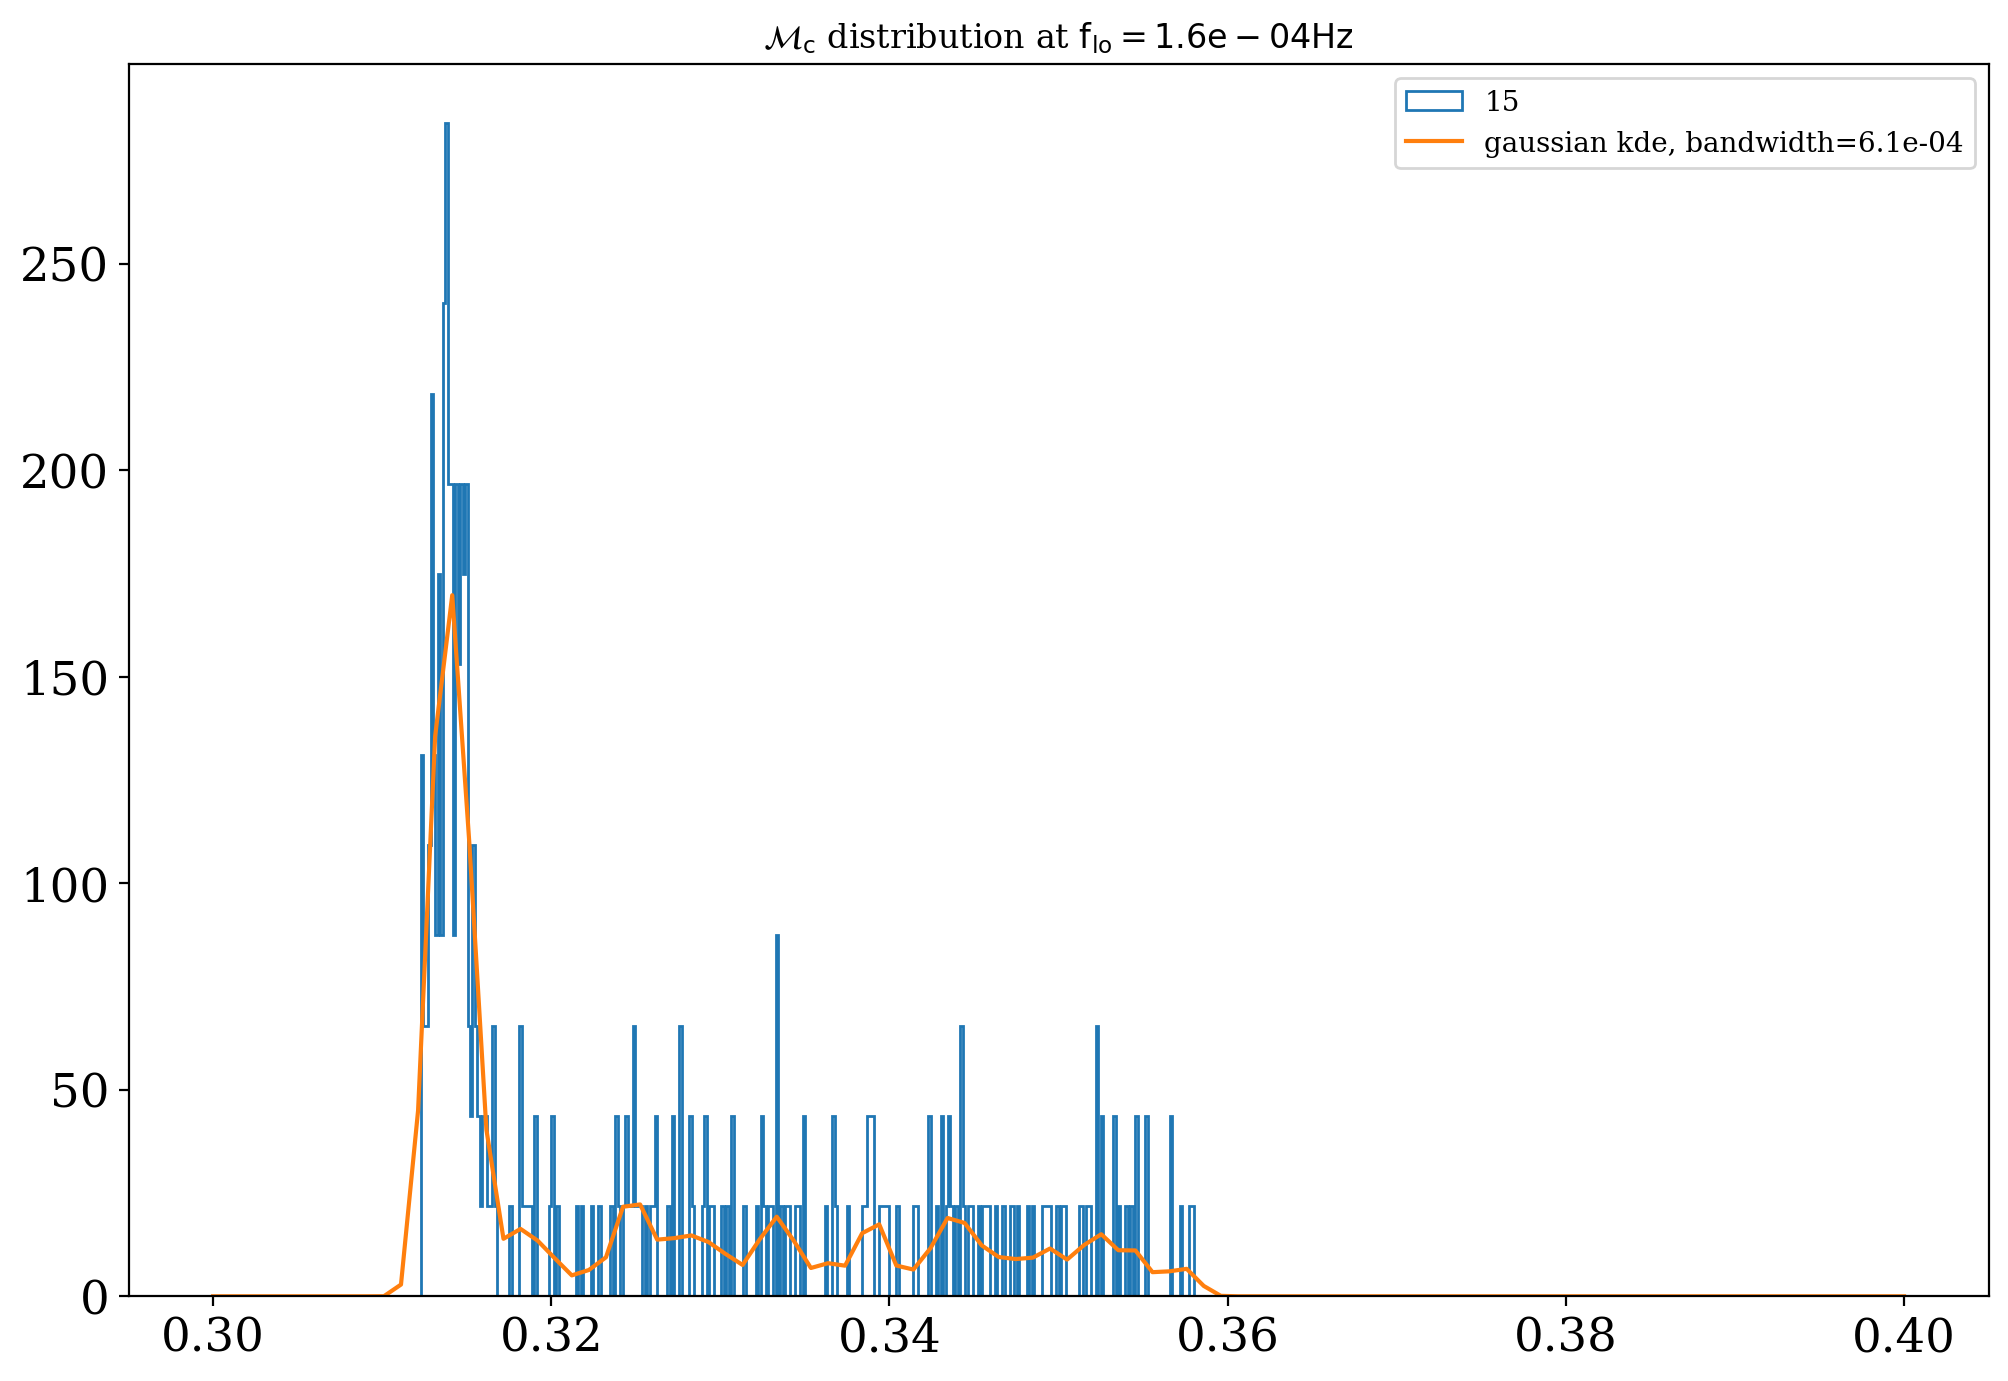

0.00041036036036036044


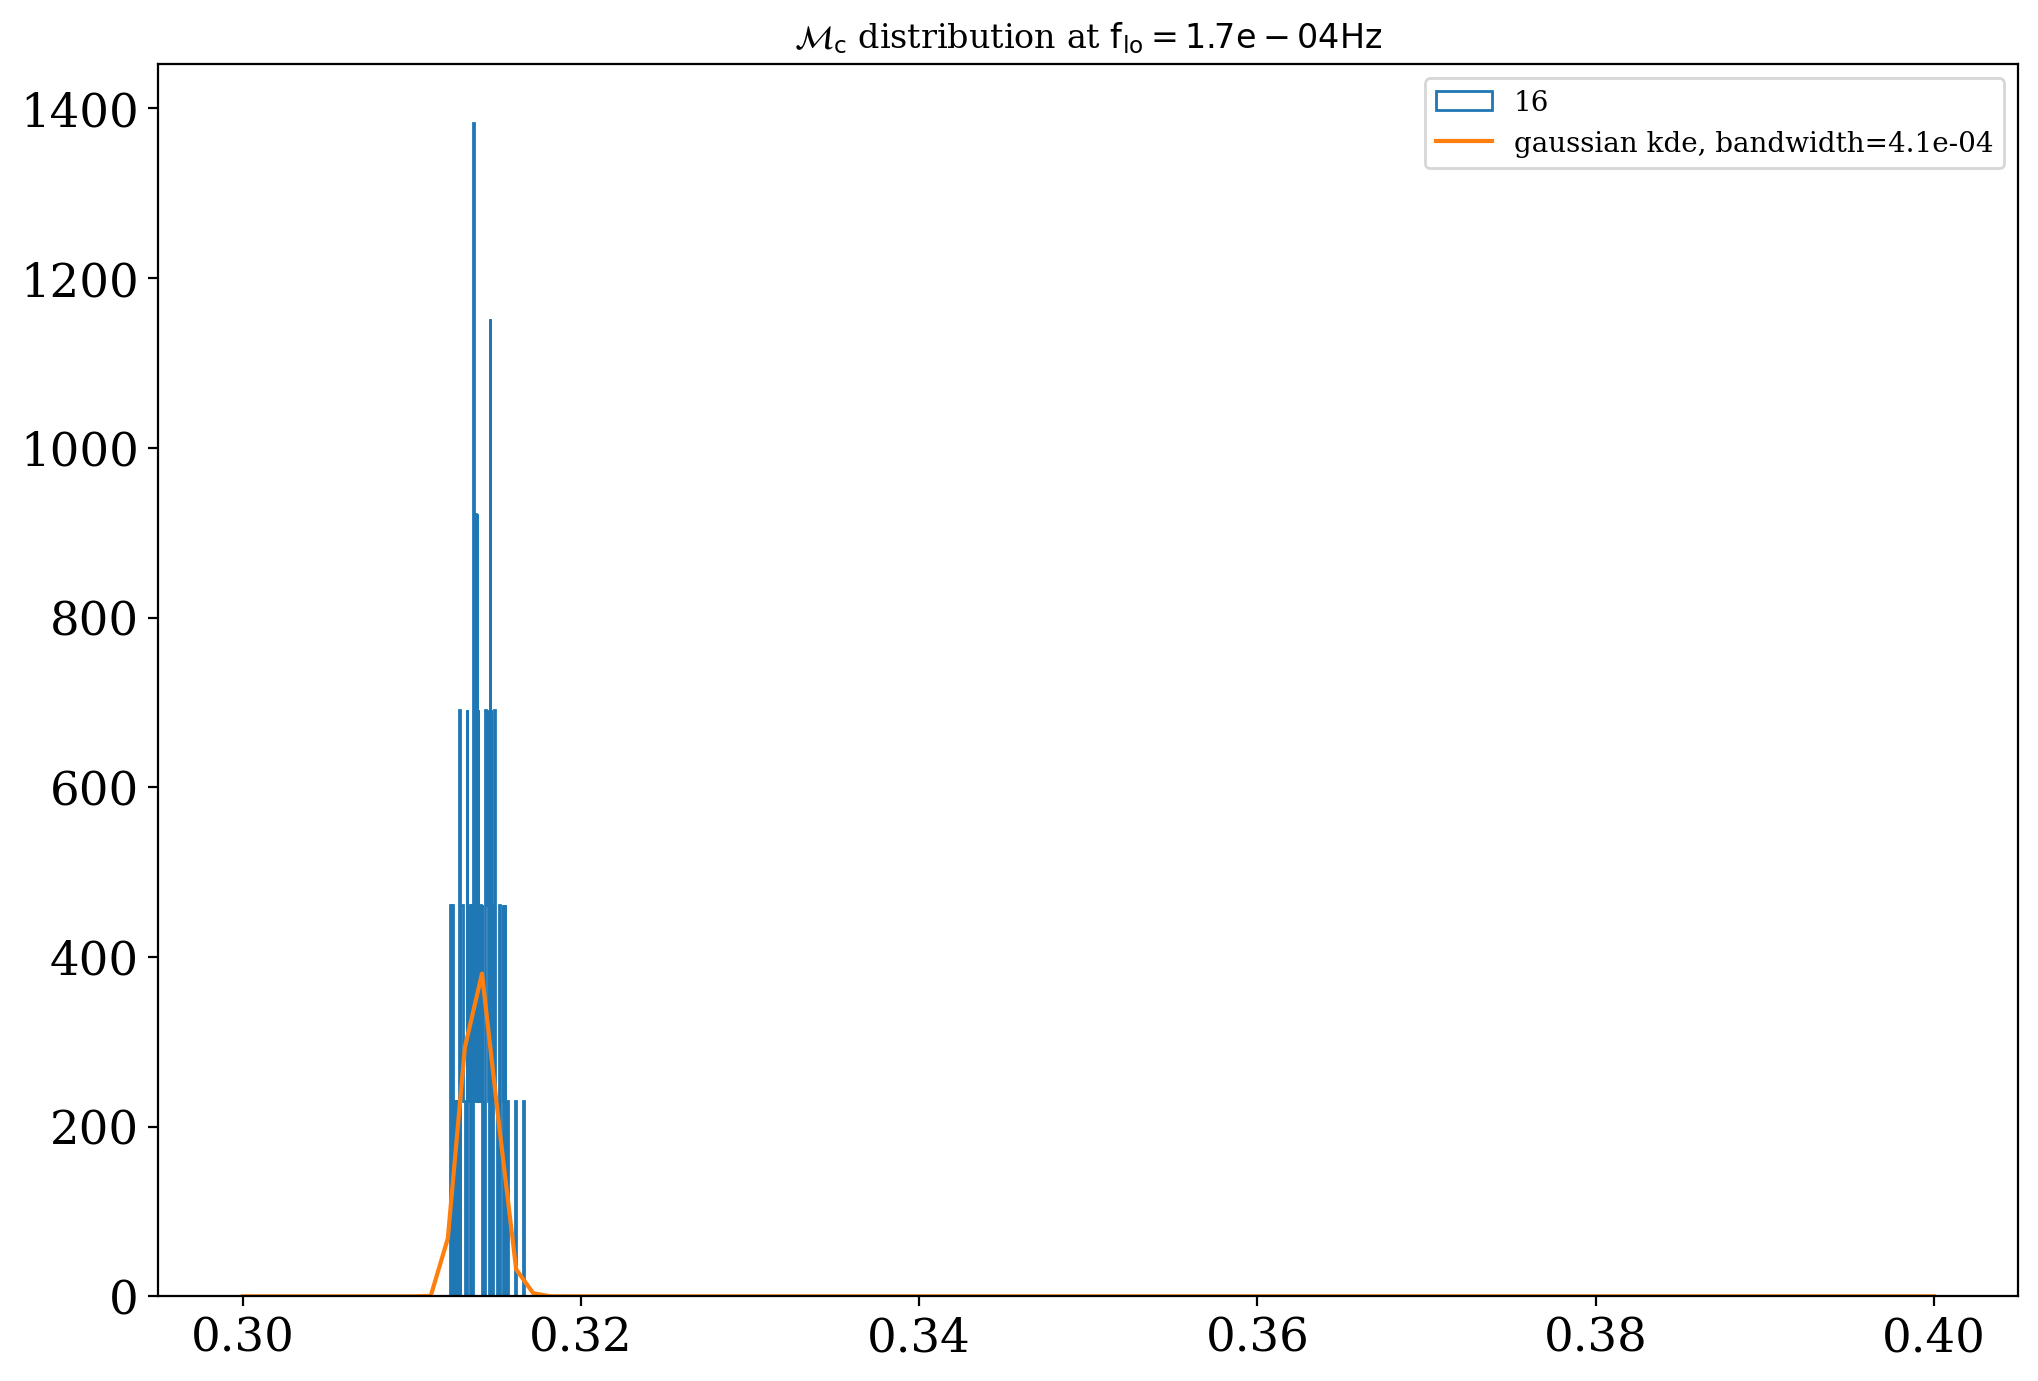

0.00041036036036036044


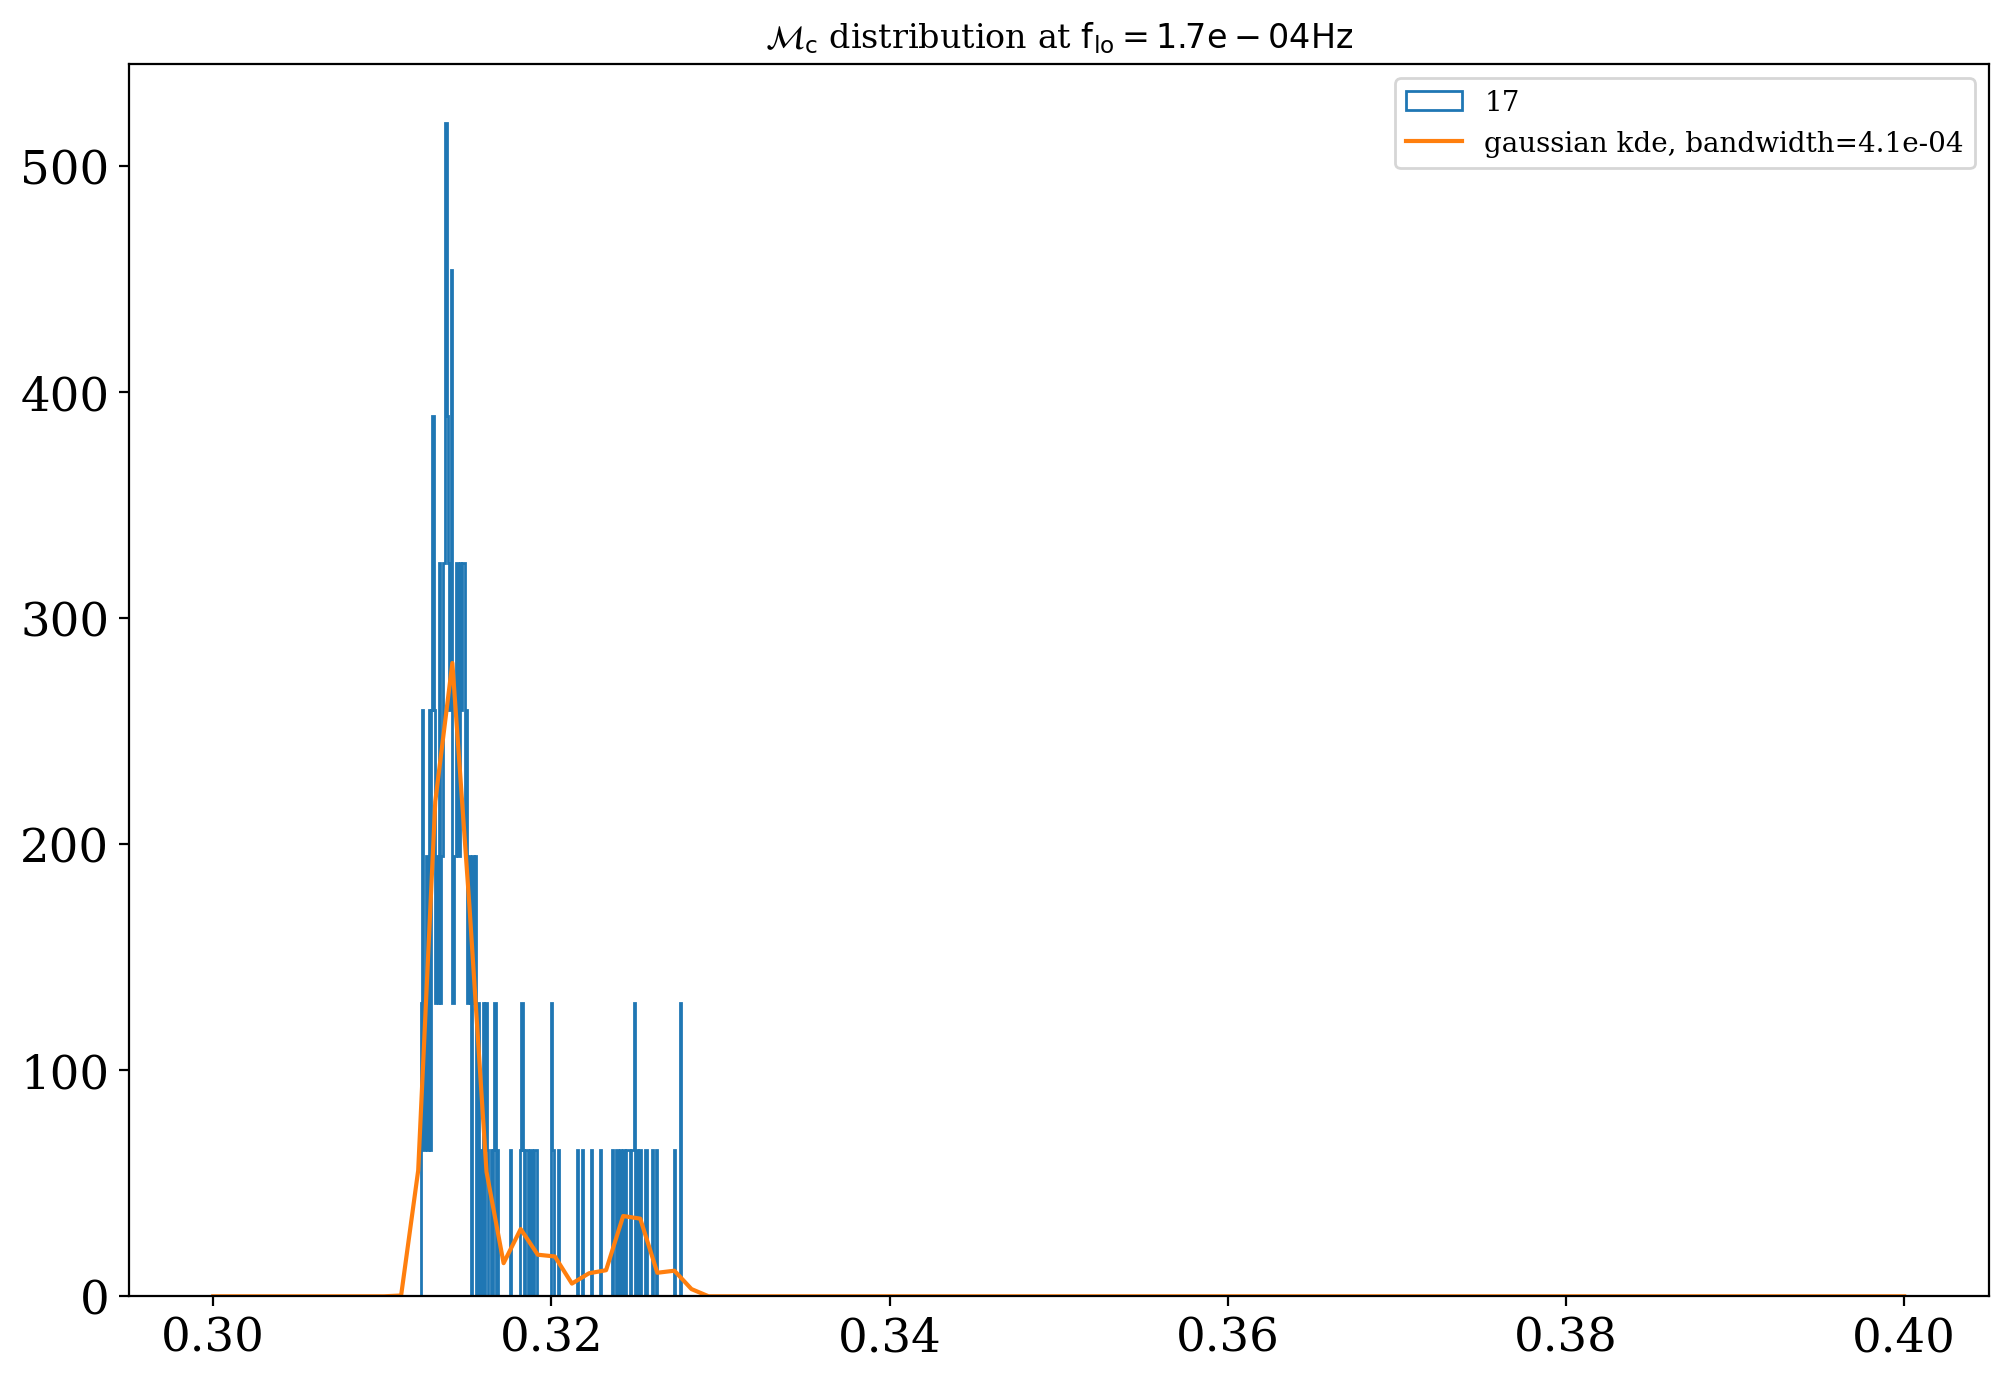

0.0005104504504504506


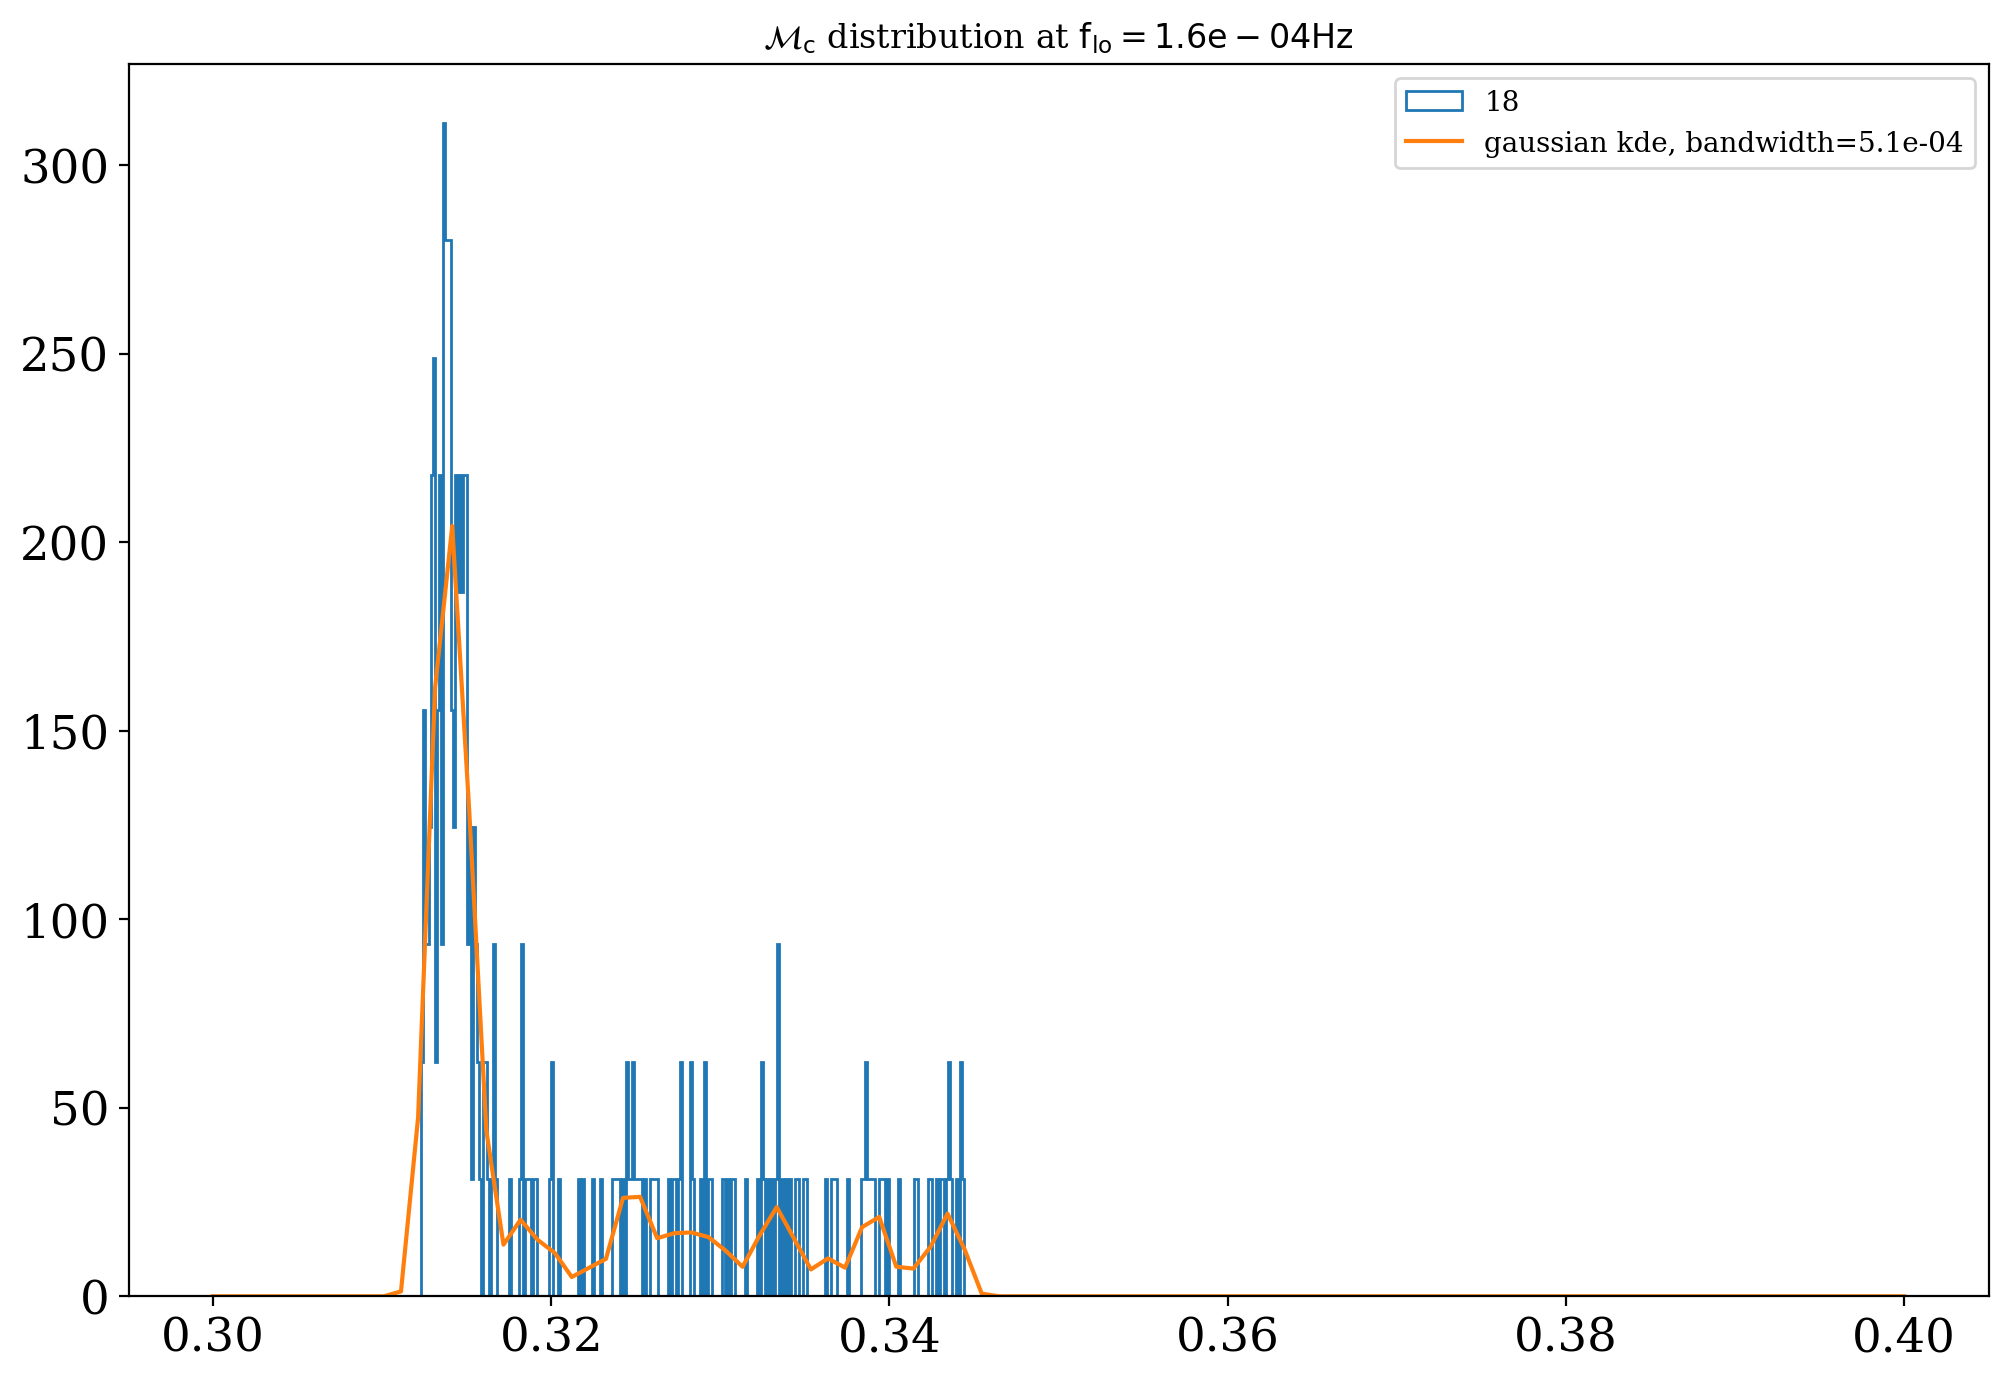

0.00041036036036036044


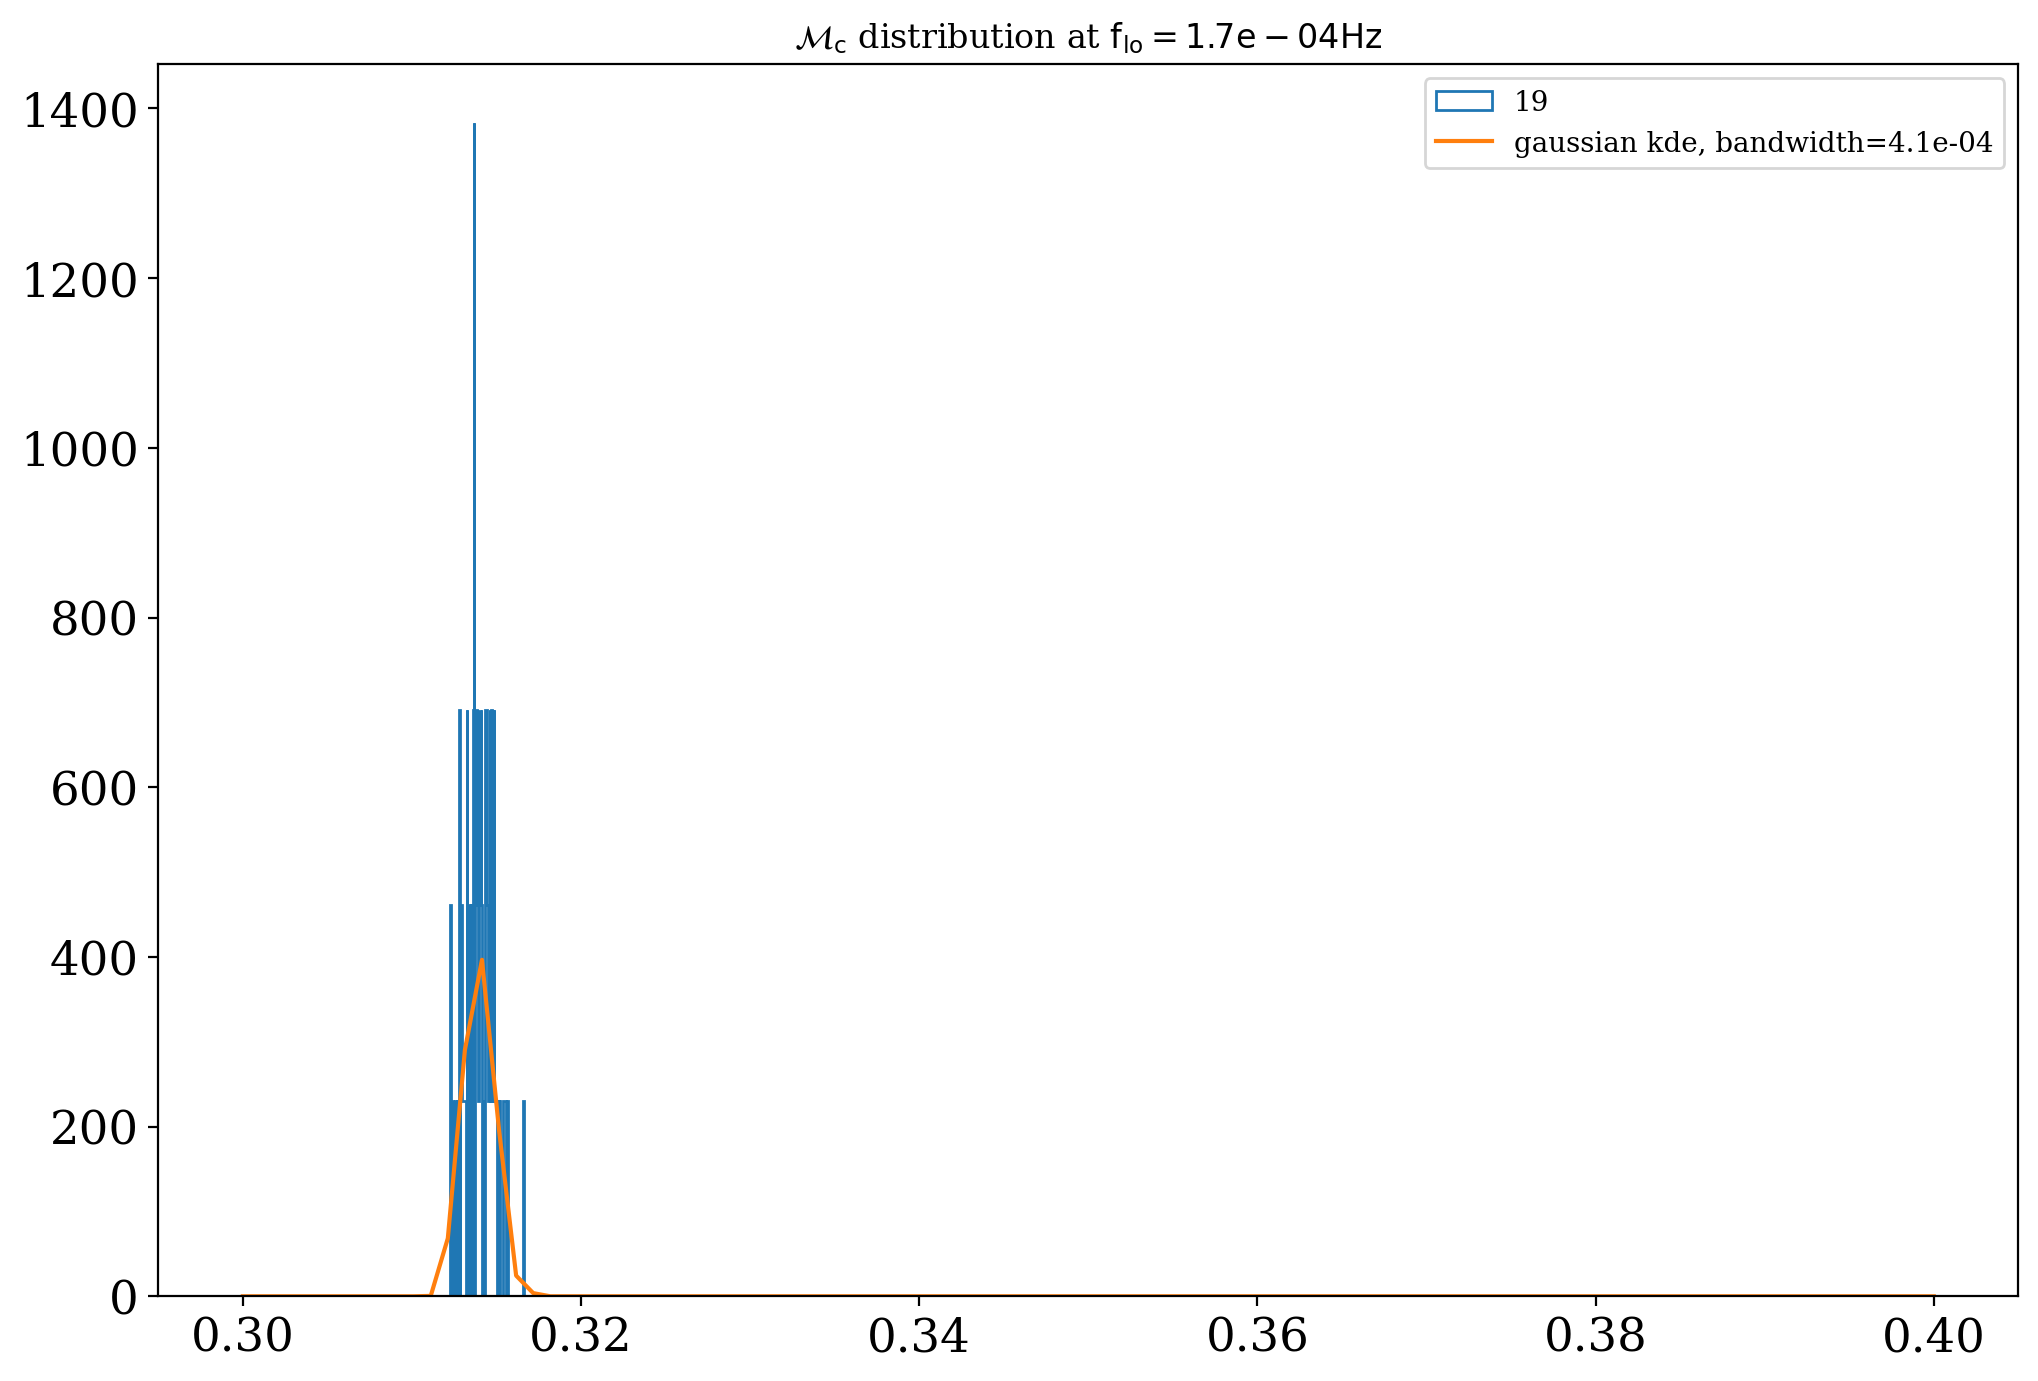

0.0006105405405405406


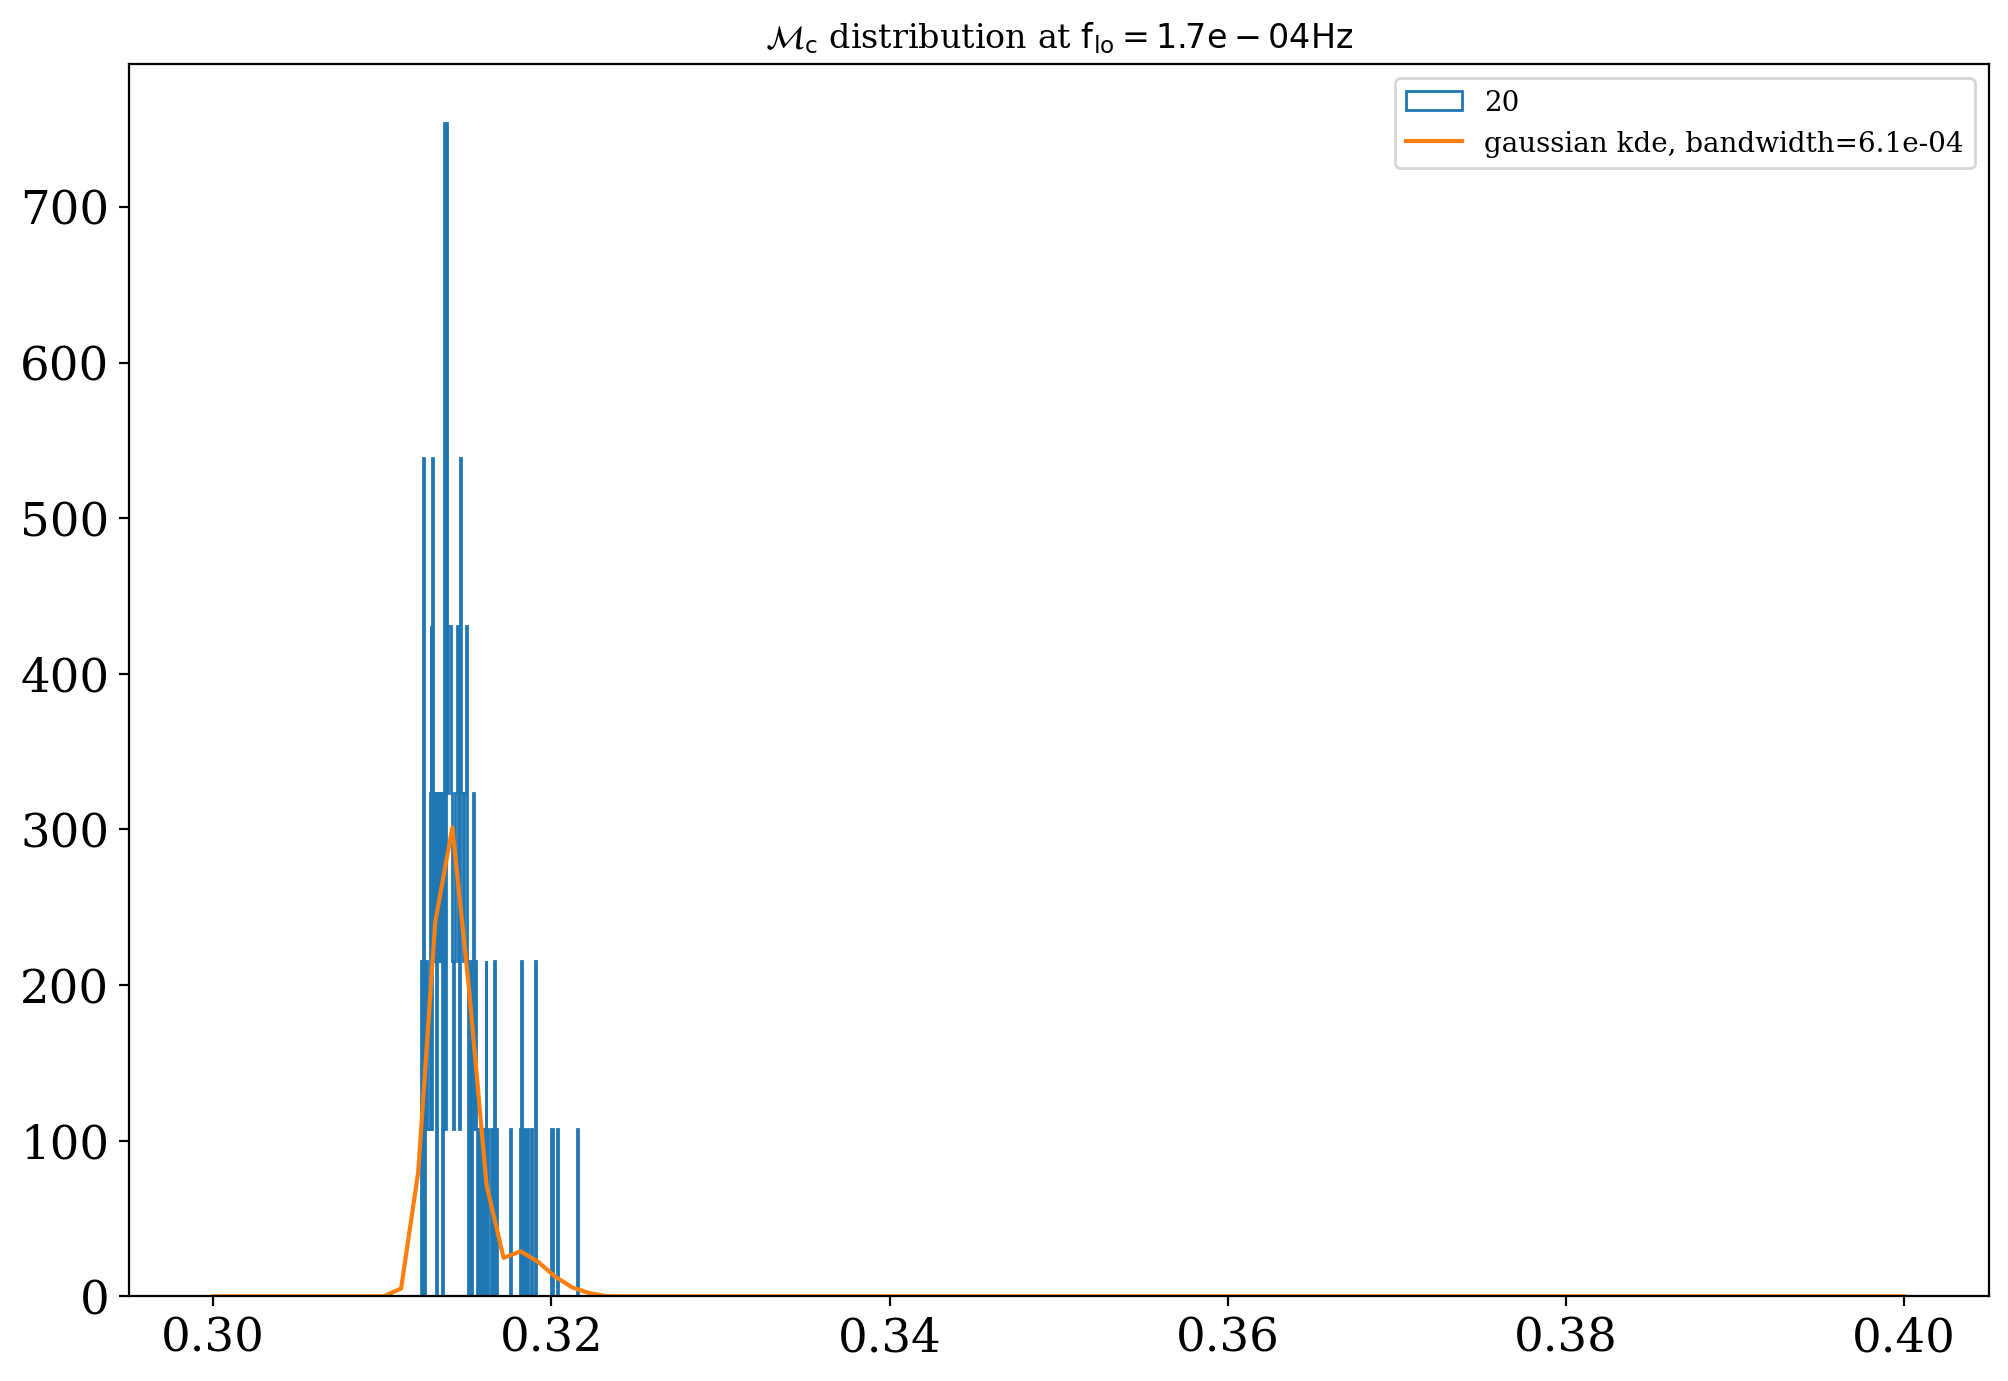

In [15]:
kern = 'gaussian'

Nbns = 20
for Nbns in range(10, 21):
    countsN, binsN = np.histogram(CV_pop[' f_gw[Hz]'], bins=Nbns)
    df = binsN[1]-binsN[0]
    #plt.hist(CV_pop[' f_gw[Hz]'], bins=Nbns)

    emgap_inds = np.where(countsN==0)[0]
    fprime_inds = emgap_inds[0]-1 # fprime = flo
    #fprime_inds = np.argmax(countsN[:emgap_inds[0]]) # fprime = max before gap
    fprime_CV_inds = np.where((CV_pop[' f_gw[Hz]']>binsN[fprime_inds]) &
                        (CV_pop[' f_gw[Hz]']<binsN[fprime_inds]+df))[0]

    #print(countsN[fprime_inds], len(fprime_CV_inds))
    # LSS or we can do all the CVs before the em gap
    #CV_belowgap_inds = np.where(CV_pop[' f_gw[Hz]']<binsN[emgap_inds[0]])[0]

    fprime_CVs = CV_pop.iloc[fprime_CV_inds]
    # CV_belowgap = CV_pop.iloc[CV_belowgap_inds]
    fprime_mc = lw.utils.chirp_mass(fprime_CVs['# m1[Msun]'] * u.Msun, fprime_CVs[' m2[Msun]'] * u.Msun)
    # CV_belowgap_mc = lw.utils.chirp_mass(CV_belowgap['# m1[Msun]'] * u.Msun, CV_belowgap[' m2[Msun]'] * u.Msun)

    plt.hist(fprime_mc, bins=len(fprime_mc), histtype='step', label=f'{Nbns}', density=True)
    bwrange = np.linspace(1e-5, 1e-1, 1000) # Test 100 bandwidths from 0.1 to 1.0
    K = 20 # Do 20-fold cross validation
    grid = GridSearchCV(KernelDensity(kernel=kern), {'bandwidth': bwrange}, cv=K) # Try each bandwidth with K-folds
    grid.fit(np.array(fprime_mc)[:, None]) #Fit the histogram data that we started the lecture with.
    h_opt = grid.best_params_['bandwidth']
    print(h_opt)
    plt.title(rf'$\mathcal{{M}}_{{\rm c}}$ distribution at $\rm f_{{\rm lo}} = {binsN[fprime_inds]:.1e} Hz$')
    # plt.hist(flo_mc, bins=len(flo_mc), label=r'$\mathcal{M}_{\rm c}$', density=True)
    mc_range = np.linspace(0.3, 0.4, 100)
    mc_kde = KernelDensity(kernel=kern, bandwidth=h_opt).fit(np.array(fprime_mc)[:, None])
    #mc_kde = KernelDensity(kernel=kern, bandwidth='scott').fit(np.array(fprime_mc)[:, None])
    log_dens = mc_kde.score_samples(mc_range[:, None])
    # plt.plot(mc_range, np.exp(log_dens)*.01, label=f'cosine kde, bandwidth={h_opt:.1e}')
    plt.plot(mc_range, np.exp(log_dens), label=f'{kern} kde, bandwidth={h_opt:.1e}')

#plt.hist(CV_belowgap_mc, bins='auto', histtype='step', label='all below gap', color='k')
    plt.legend(fontsize='medium')
    plt.show()





0.0006056060000000001


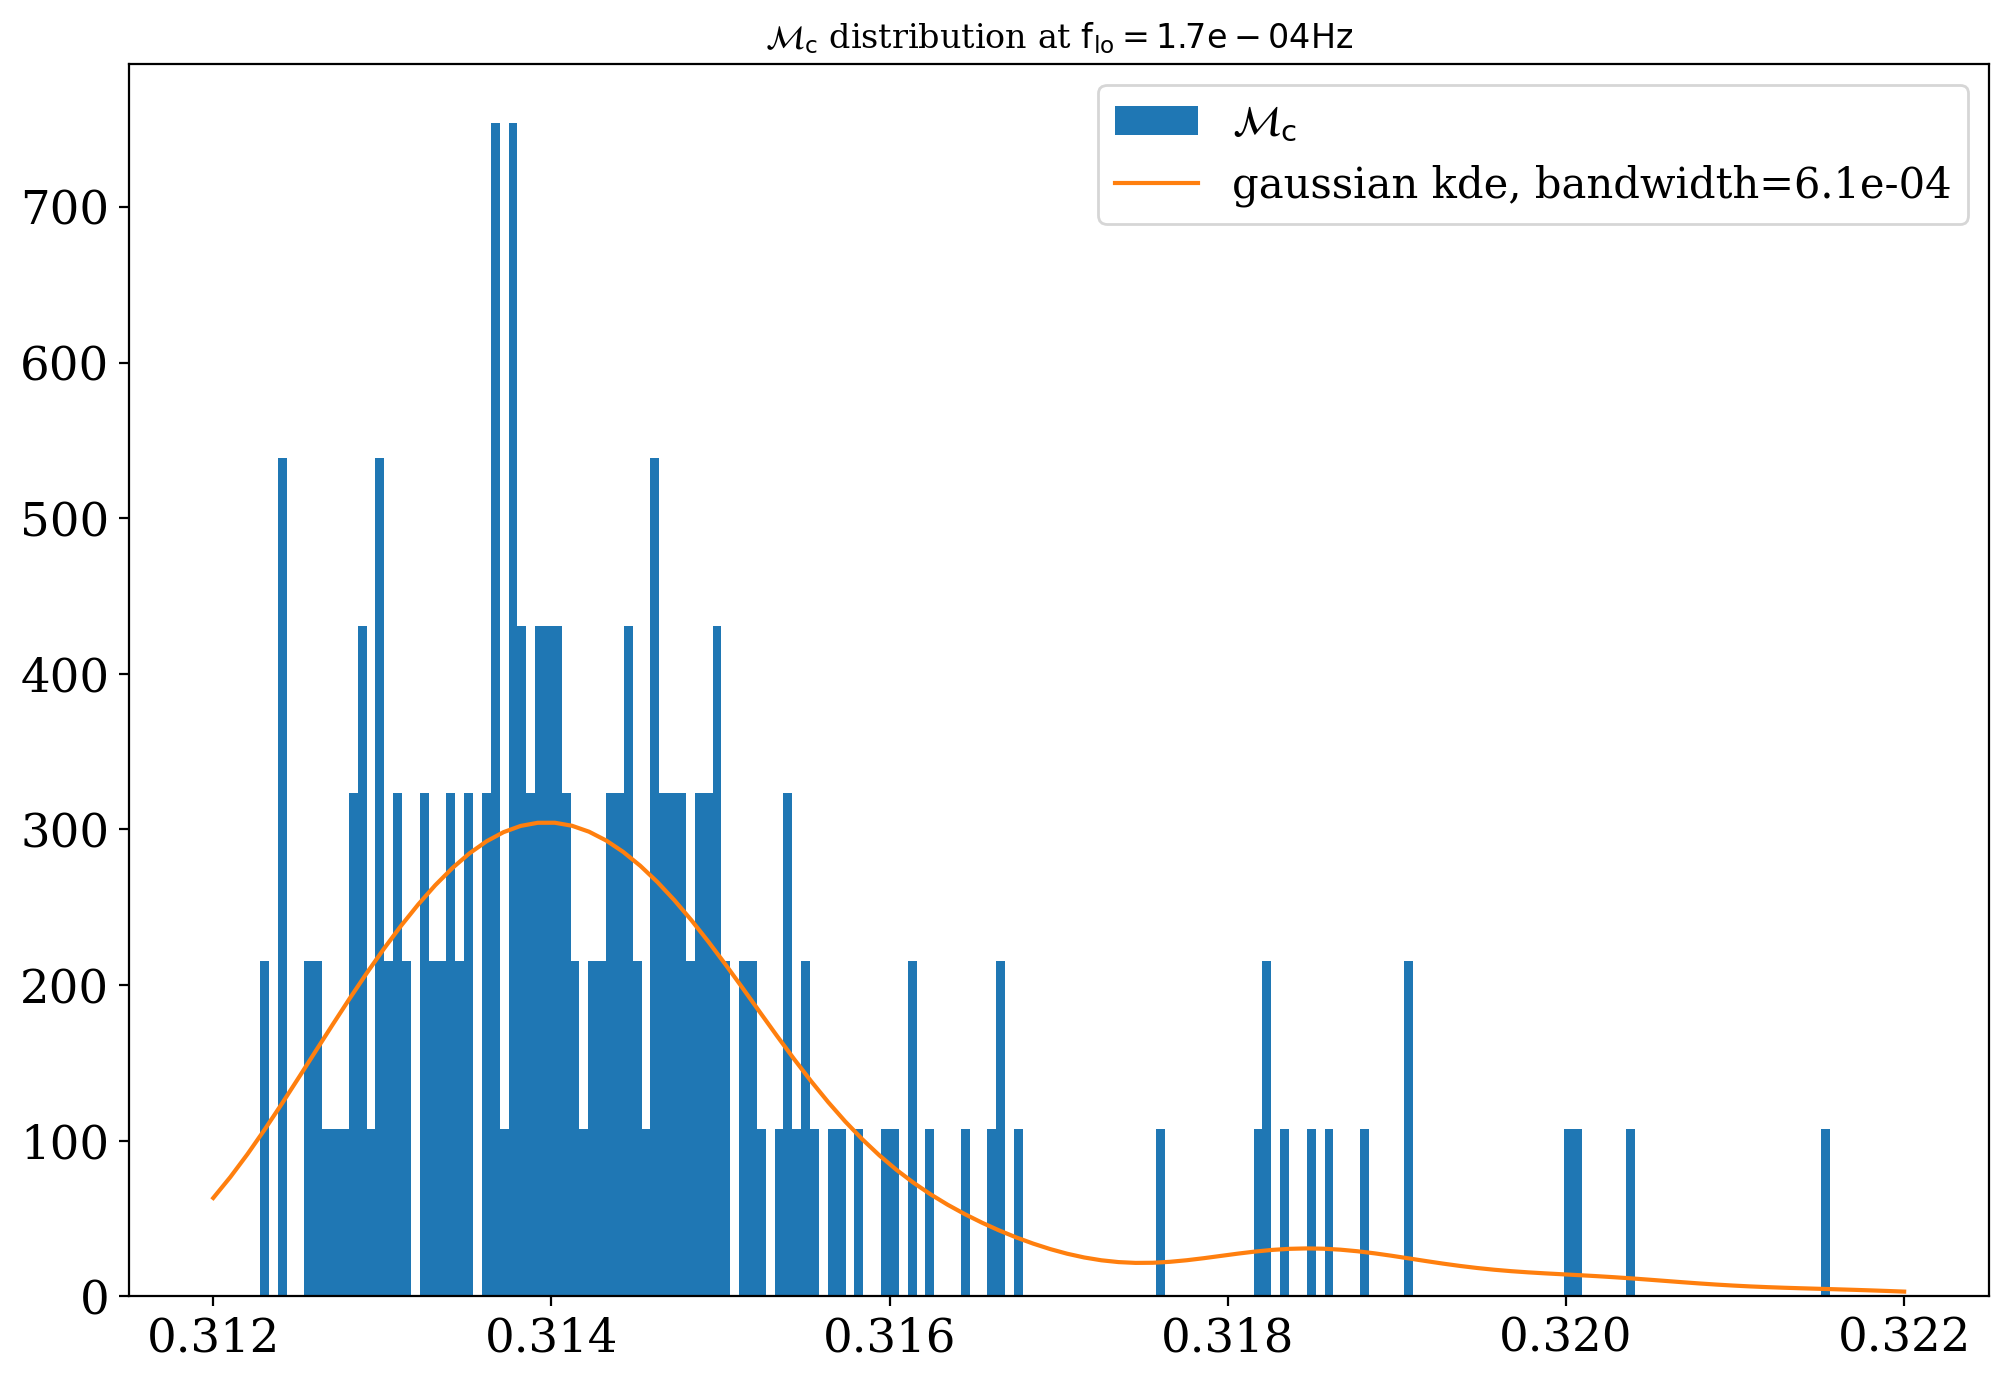

In [28]:
kern = 'gaussian'

bwrange = np.linspace(1e-9, 1e-3, 1000) # Test 100 bandwidths from 0.1 to 1.0
K = 20 # Do 20-fold cross validation
grid = GridSearchCV(KernelDensity(kernel=kern), {'bandwidth': bwrange}, cv=K) # Try each bandwidth with K-folds
grid.fit(np.array(flo_mc)[:, None]) #Fit the histogram data that we started the lecture with.
h_opt = grid.best_params_['bandwidth']
print(h_opt)
plt.title(rf'$\mathcal{{M}}_{{\rm c}}$ distribution at $\rm f_{{\rm lo}} = {flo:.1e} Hz$')
plt.hist(flo_mc, bins=len(flo_mc), label=r'$\mathcal{M}_{\rm c}$', density=True)
mc_range = np.linspace(0.312, 0.322, 100)
mc_kde = KernelDensity(kernel=kern, bandwidth=h_opt).fit(np.array(flo_mc)[:, None])
log_dens = mc_kde.score_samples(mc_range[:, None])
# plt.plot(mc_range, np.exp(log_dens)*.01, label=f'cosine kde, bandwidth={h_opt:.1e}')
plt.plot(mc_range, np.exp(log_dens), label=f'{kern} kde, bandwidth={h_opt:.1e}')

plt.legend(fontsize=15)
plt.show()

## making freq bins based on CVs themselves

(array([ 76.,  81.,  76., 103.,  83., 106., 105., 108., 124., 125., 146.,
         56.,   0.,   0.,   0.,   0.,   0.,   0.,  97., 357., 325., 331.,
        317., 365., 375., 362., 338., 383., 420., 421., 479., 473., 463.,
        589.]),
 array([5.33372000e-05, 6.45878294e-05, 7.58384588e-05, 8.70890882e-05,
        9.83397176e-05, 1.09590347e-04, 1.20840976e-04, 1.32091606e-04,
        1.43342235e-04, 1.54592865e-04, 1.65843494e-04, 1.77094124e-04,
        1.88344753e-04, 1.99595382e-04, 2.10846012e-04, 2.22096641e-04,
        2.33347271e-04, 2.44597900e-04, 2.55848529e-04, 2.67099159e-04,
        2.78349788e-04, 2.89600418e-04, 3.00851047e-04, 3.12101676e-04,
        3.23352306e-04, 3.34602935e-04, 3.45853565e-04, 3.57104194e-04,
        3.68354824e-04, 3.79605453e-04, 3.90856082e-04, 4.02106712e-04,
        4.13357341e-04, 4.24607971e-04, 4.35858600e-04]),
 <BarContainer object of 34 artists>)

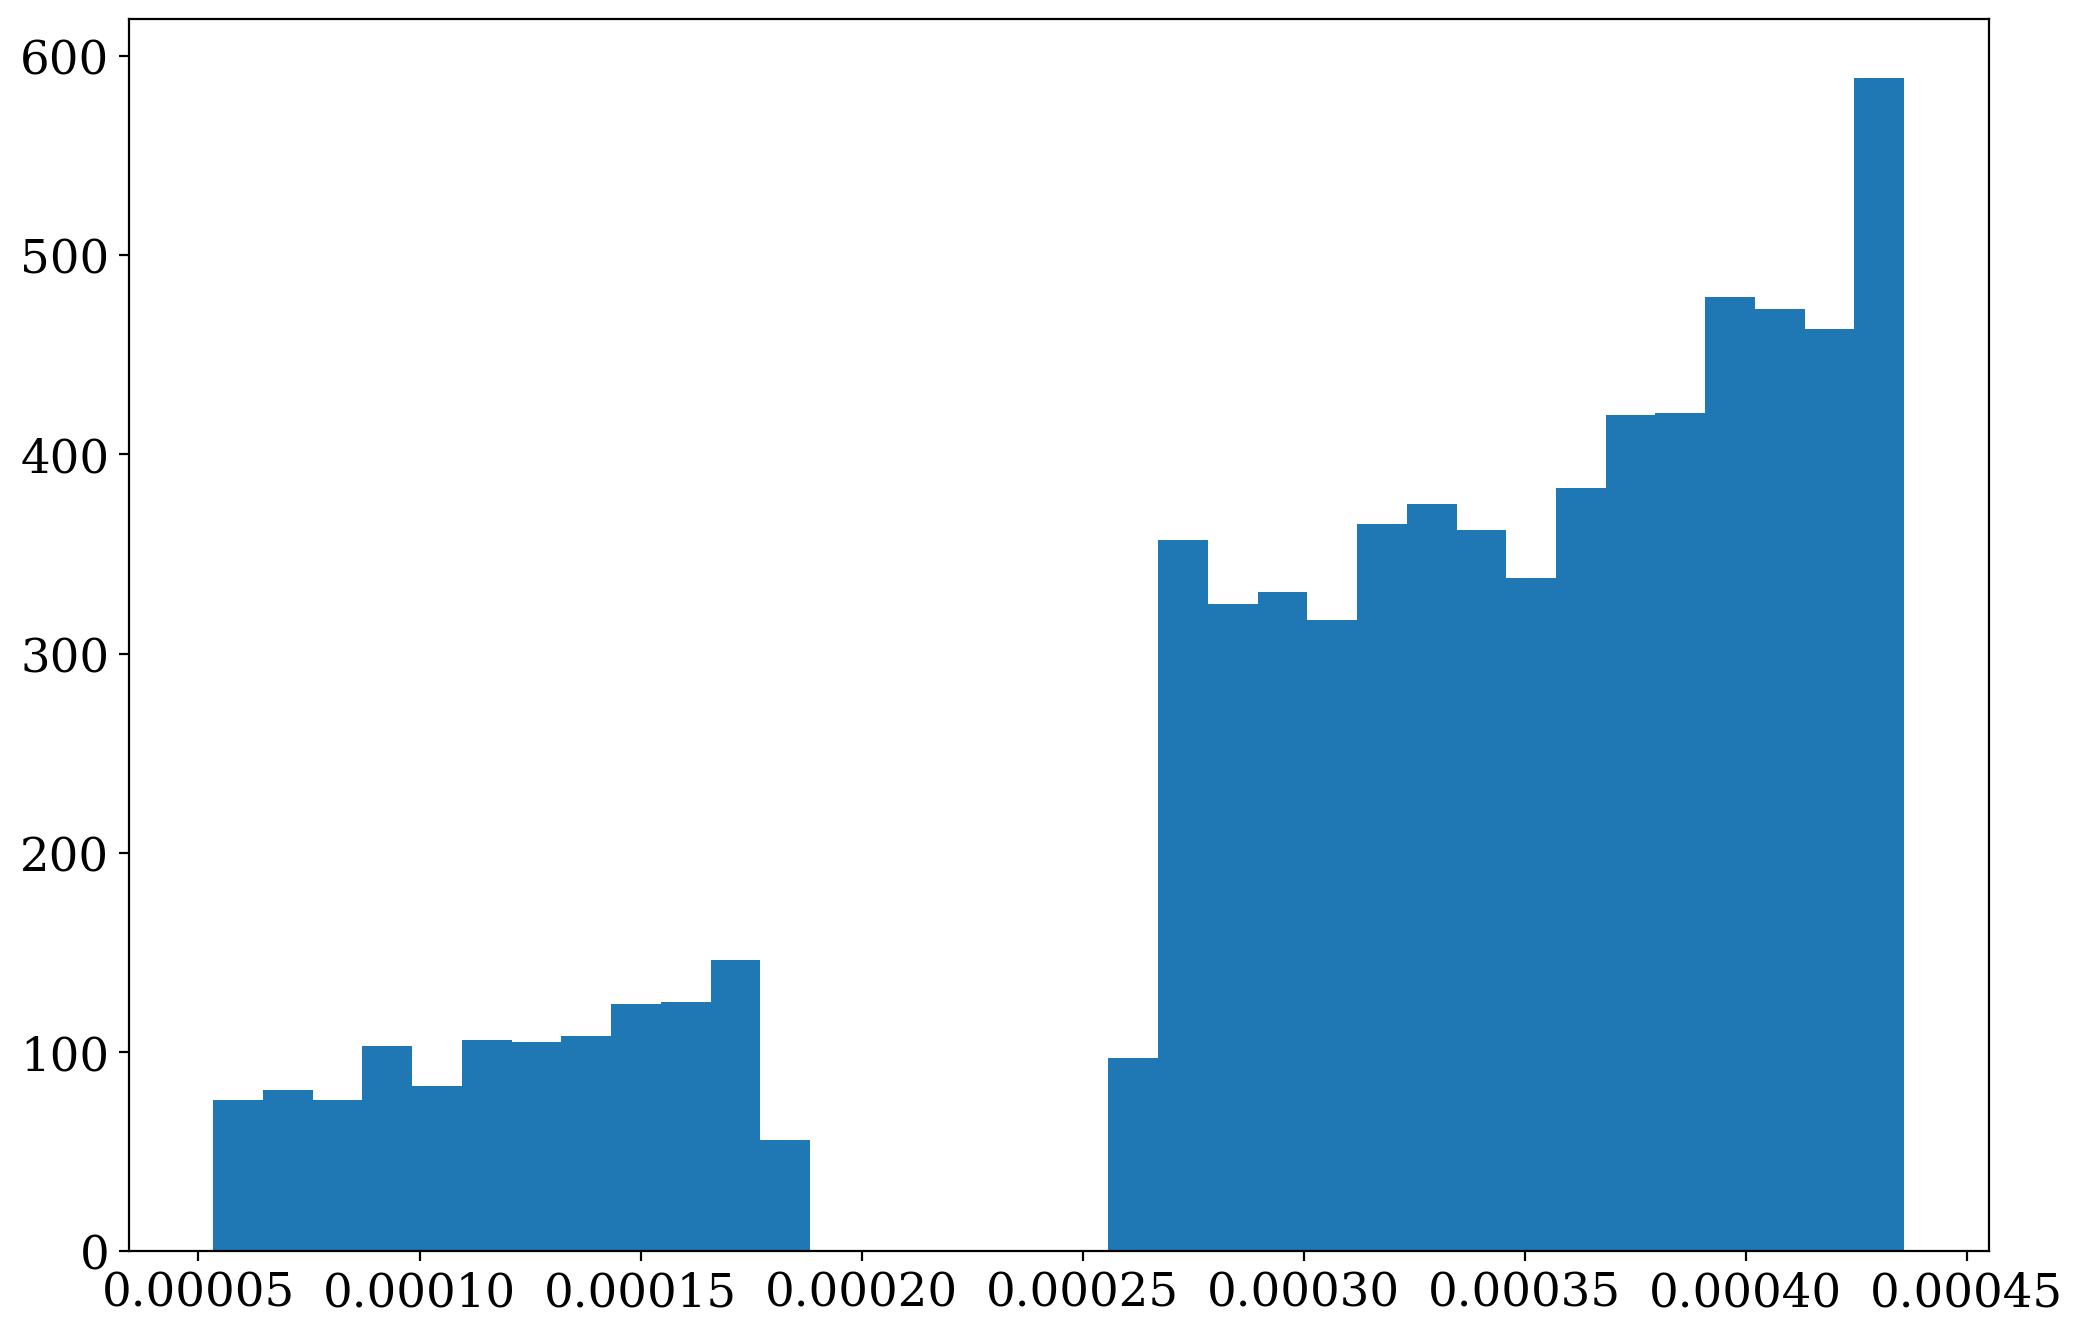

In [26]:
plt.hist(CV_pop[' f_gw[Hz]'], bins='auto')

(array([ 79.,  80.,  83., 108.,  90., 104., 104., 113., 139., 124., 165.,
          0.,   0.,   0.,   0.,   0.,   0.,   0., 324., 313., 359., 327.,
        369., 385., 361., 349., 390., 433., 439., 467., 501., 480., 598.]),
 array([5.33372000e-05, 6.49287576e-05, 7.65203152e-05, 8.81118727e-05,
        9.97034303e-05, 1.11294988e-04, 1.22886545e-04, 1.34478103e-04,
        1.46069661e-04, 1.57661218e-04, 1.69252776e-04, 1.80844333e-04,
        1.92435891e-04, 2.04027448e-04, 2.15619006e-04, 2.27210564e-04,
        2.38802121e-04, 2.50393679e-04, 2.61985236e-04, 2.73576794e-04,
        2.85168352e-04, 2.96759909e-04, 3.08351467e-04, 3.19943024e-04,
        3.31534582e-04, 3.43126139e-04, 3.54717697e-04, 3.66309255e-04,
        3.77900812e-04, 3.89492370e-04, 4.01083927e-04, 4.12675485e-04,
        4.24267042e-04, 4.35858600e-04]),
 <BarContainer object of 33 artists>)

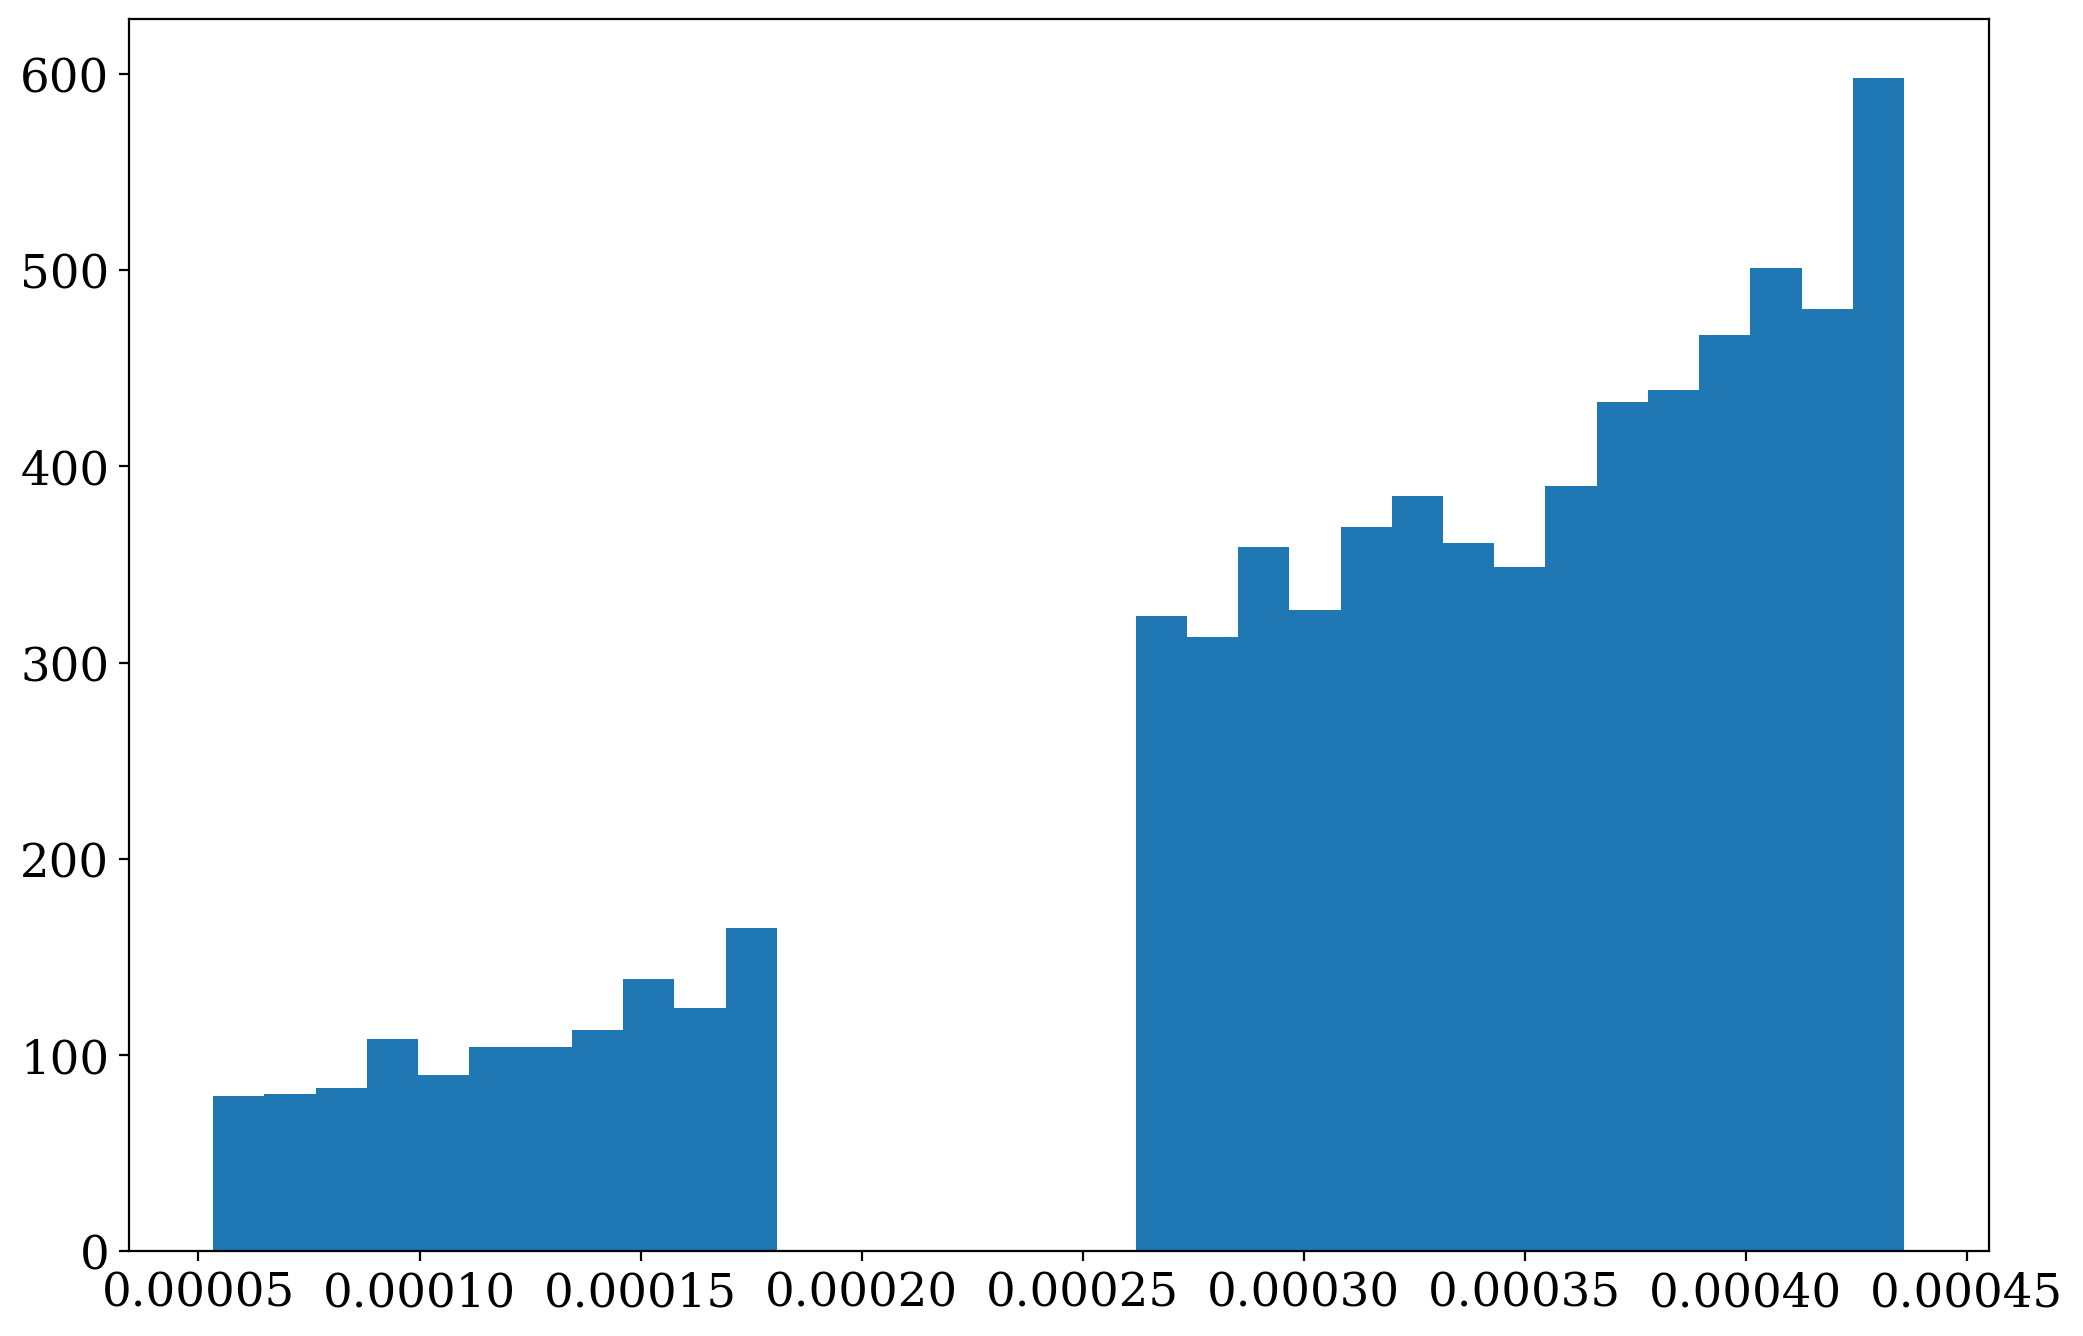

In [85]:
CV_freq_bins = np.linspace(np.min(CV_pop[' f_gw[Hz]']), np.max(CV_pop[' f_gw[Hz]']), 34)
plt.hist(CV_pop[' f_gw[Hz]'], bins=CV_freq_bins)

0.0006056060000000001
N CVs below EM gap 1189
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.0014000000000000002


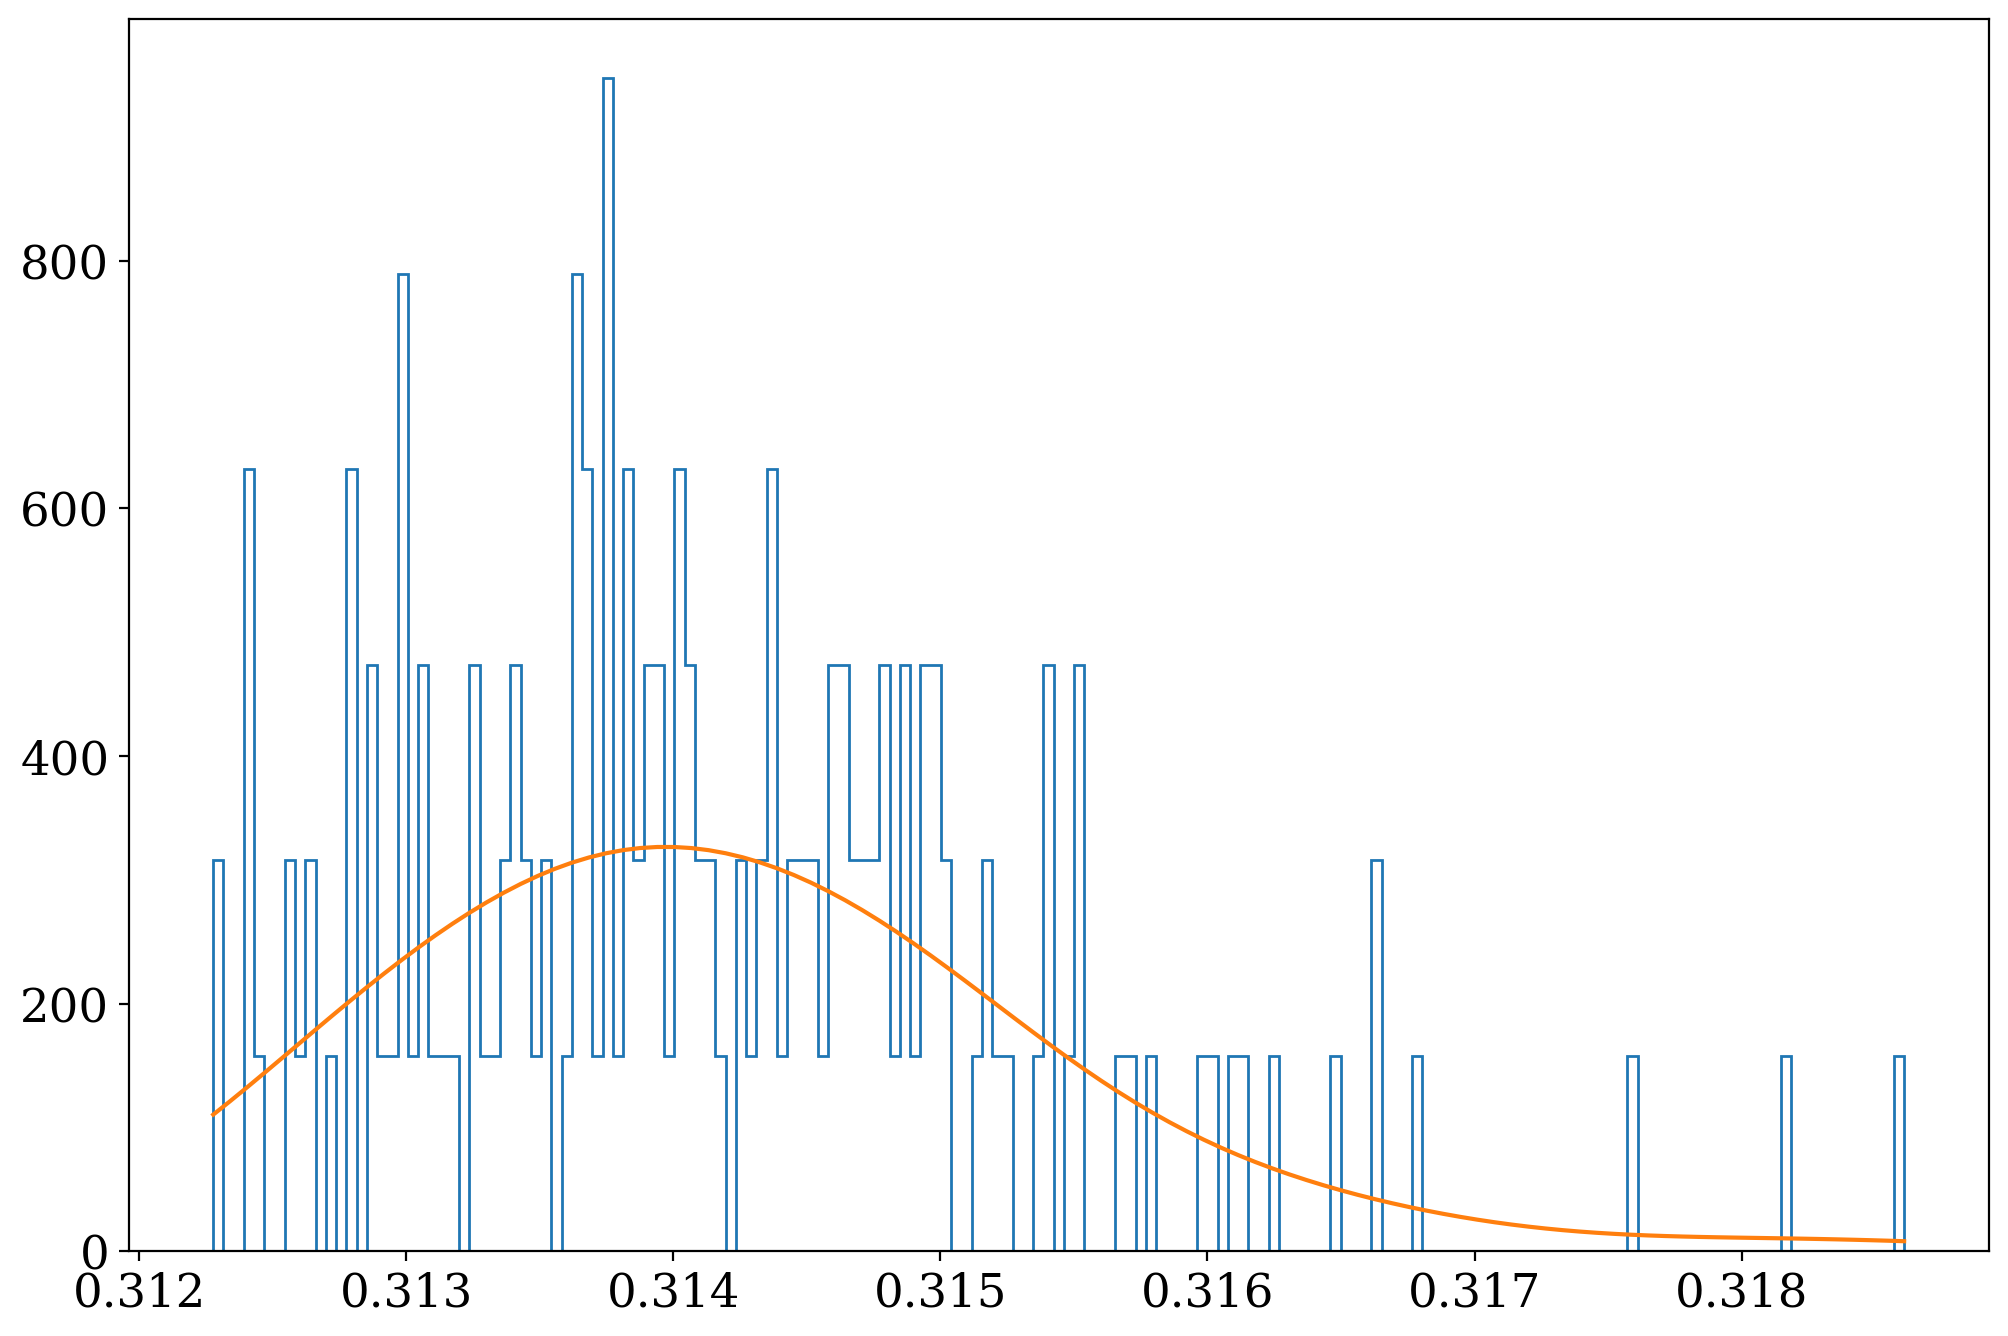

In [ ]:
countsN, binsN = np.histogram(CV_pop[' f_gw[Hz]'], bins=CV_freq_bins)
df = binsN[1]-binsN[0]
#plt.hist(CV_pop[' f_gw[Hz]'], bins=Nbns)
emgap_inds = np.where(countsN==0)[0]
fprime_inds = emgap_inds[0]-1 # fprime = flo
fprime_inds = np.argmax(countsN[:emgap_inds[0]]) # fprime = max before gap
fprime_CV_inds = np.where((CV_pop[' f_gw[Hz]']>binsN[fprime_inds]) &
                    (CV_pop[' f_gw[Hz]']<binsN[fprime_inds]+df))[0]

#print(countsN[fprime_inds], len(fprime_CV_inds))
# LSS or we can do all the CVs before the em gap
#CV_belowgap_inds = np.where(CV_pop[' f_gw[Hz]']<binsN[emgap_inds[0]])[0]

fprime_CVs = CV_pop.iloc[fprime_CV_inds]
#CV_belowgap = CV_pop.iloc[CV_belowgap_inds]
fprime_mc = lw.utils.chirp_mass(fprime_CVs['# m1[Msun]'] * u.Msun, fprime_CVs[' m2[Msun]'] * u.Msun)
#CV_belowgap_mc = lw.utils.chirp_mass(CV_belowgap['# m1[Msun]'] * u.Msun, CV_belowgap[' m2[Msun]'] * u.Msun)

plt.hist(fprime_mc, bins=len(fprime_CVs), histtype='step', label=f'{Nbns}', density=True);
bwrange = np.linspace(1e-9, 1e-3, 1000) # Test 100 bandwidths from 0.1 to 1.0
K = 20 # Do 20-fold cross validation
grid = GridSearchCV(KernelDensity(kernel=kern), {'bandwidth': bwrange}, cv=K) # Try each bandwidth with K-folds
grid.fit(np.array(flo_mc)[:, None]) #Fit the histogram data that we started the lecture with.
h_opt = grid.best_params_['bandwidth']
print(h_opt)
#plt.title(rf'$\mathcal{{M}}_{{\rm c}}$ distribution at $\rm f_{{\rm lo}} = {flo:.1e} Hz$')
#plt.hist(flo_mc, bins=len(flo_mc), label=r'$\mathcal{M}_{\rm c}$', density=True)
mc_range = np.linspace(np.min(fprime_mc), np.max(fprime_mc), 100)
mc_kde = KernelDensity(kernel=kern, bandwidth=h_opt).fit(np.array(fprime_mc)[:, None])
log_dens = mc_kde.score_samples(mc_range[:, None])
plt.plot(mc_range, np.exp(log_dens), label=f'{kern} kde, bandwidth={h_opt:.1e}')

mc_interp = interpolate.interp1d(mc_range, np.exp(log_dens)/np.sum(np.exp(log_dens)), fill_value=0, bounds_error=False)

fprime_and_fgap = [binsN[fprime_inds]]
fprime_and_fgap.extend(binsN[emgap_inds])
fill_CVs =  N_CVs_gwevol(fprime_and_fgap, mc_range, Nbin=CV_freq_bins)[1:]
#N_CVs_gwevol(fprime_and_fgap, mc_range, Nbin=CV_freq_bins)

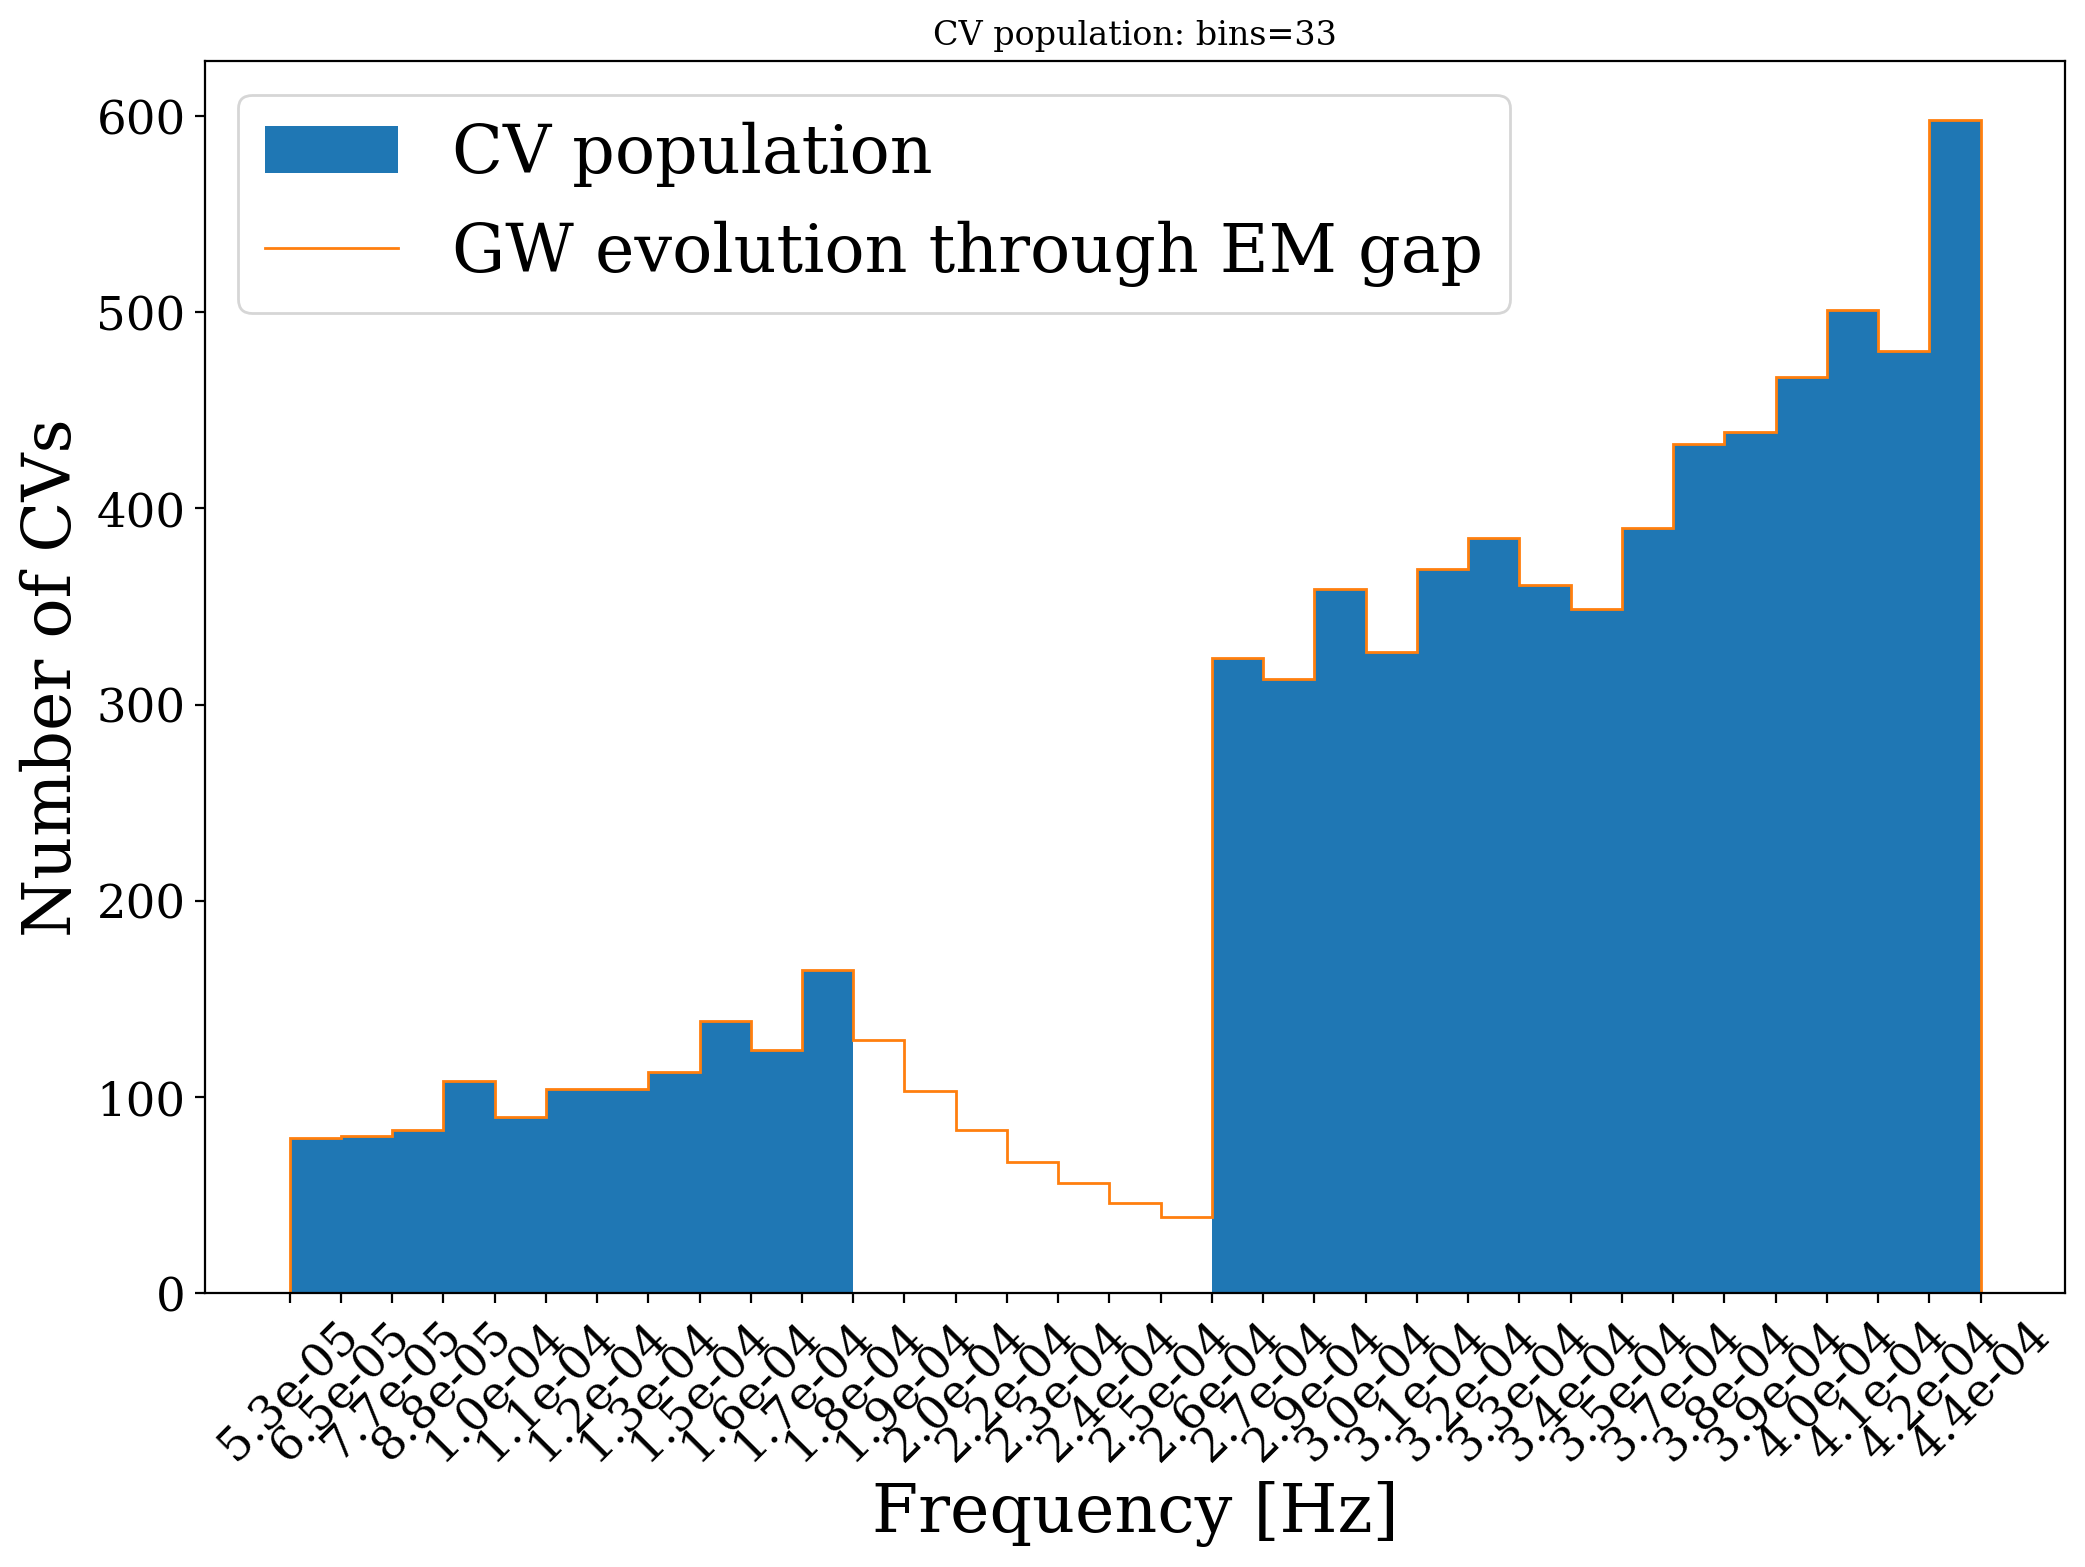

In [88]:
countsNfilled = copy.deepcopy(countsN)
countsNfilled[emgap_inds] = fill_CVs
plot_em_gap_fill(countsN, countsNfilled, CV_freq_bins)

## test at filling pop at certain freq given chirpmasses 

In [20]:
# now lets make a function that calculates the number of CVs at a given freq/chirp mass

def dNdfdmc_CVs_gwevol(f, mchirp):
    """_summary_

    Parameters
    ----------
    f : float
        frequency in Hz
    mchirp : float
        chirp mass in solar masses
    """
    # See eqn A2 of Nissanke et al. 2012
    # G, c in m, s, kg
    dfdt_fact = (96/5)*np.pow(np.pi, -8/3)*np.pow(apyconst.G.value, -5/3)*np.pow(apyconst.c.value, 5)
    # LSS convert chirp mass from solar masses to kg
    mc_kg = mchirp * apyconst.M_sun.value
    dfdt_vars = np.pow(mc_kg, -5/3)*np.pow(f, -11/3)
    dtdf = (dfdt_fact*dfdt_vars)**-1
    # print(dtdf)
    dNdmc = mc_flo_interp(mchirp)
    flo_norm = 1
    dNdfdmc = dtdf * dNdmc * normfact
    return dNdfdmc

In [21]:
# LSS sum over mass 
# mult by freq binsize and mass binsize to get total number
unnormN = np.sum(dNdfdmc_CVs_gwevol(np.array(flo), mc_range)) * df * (mc_range[1]-mc_range[0])

In [22]:
Fgrid, Mgrid = np.meshgrid([flo, fhi], mc_range)

In [23]:
tstN = dNdfdmc_CVs_gwevol(Fgrid, Mgrid)

In [24]:
tstN.shape

(100, 2)

In [25]:
tstNflo = np.sum(tstN[:, 0])

In [26]:
mcbinsize = mc_range[1]-mc_range[0]
tstNflo * mcbinsize * df # LSS need to multiply by binsize because we are calculating a density and need to convert to a real number.

np.float64(177.0)

In [27]:
tstNfhi = np.sum(tstN[:, 1])

In [28]:
mcbinsize = mc_range[1]-mc_range[0]
Nfhi_est = tstNfhi * mcbinsize * df # LSS need to multiply by binsize because we are calculating a density and need to convert to a real number.

In [29]:
counts

array([ 277.,  333.,  402.,  177.,    0.,  579., 1147., 1221., 1433.,
       1715.])

make some figures out of this with filled populations
write this up and send to katie and steve 
bootstrap over mc and f binning to get uncertainties
be careful of bin edges 

not sure how to do it
conditioning this on poisson realization of the rate in the previous bin
getting rate from previous bin
what we have computed is estimated rate in connecting bins
- poisson realizations from estimated rate to get uncertainties

lets do this not worrying about first bin being poisson realization so far

In [30]:
bins[np.where(counts==0)[0]]

array([0.00020635])

In [31]:
emptyfbin = bins[np.where(counts==0)[0]]

In [32]:
Fgrid, Mgrid = np.meshgrid([emptyfbin], mc_range)
tstN = dNdfdmc_CVs_gwevol(Fgrid, Mgrid)
mcbinsize = mc_range[1]-mc_range[0]
fillnum = np.sum(tstN, axis=0) * mcbinsize * df # LSS need to multiply by binsize because we are calculating a density and need to convert to a real number.


In [33]:
filledcts = copy.deepcopy(counts)
filledcts[4] = fillnum[0]
filledcts[5] = Nfhi_est

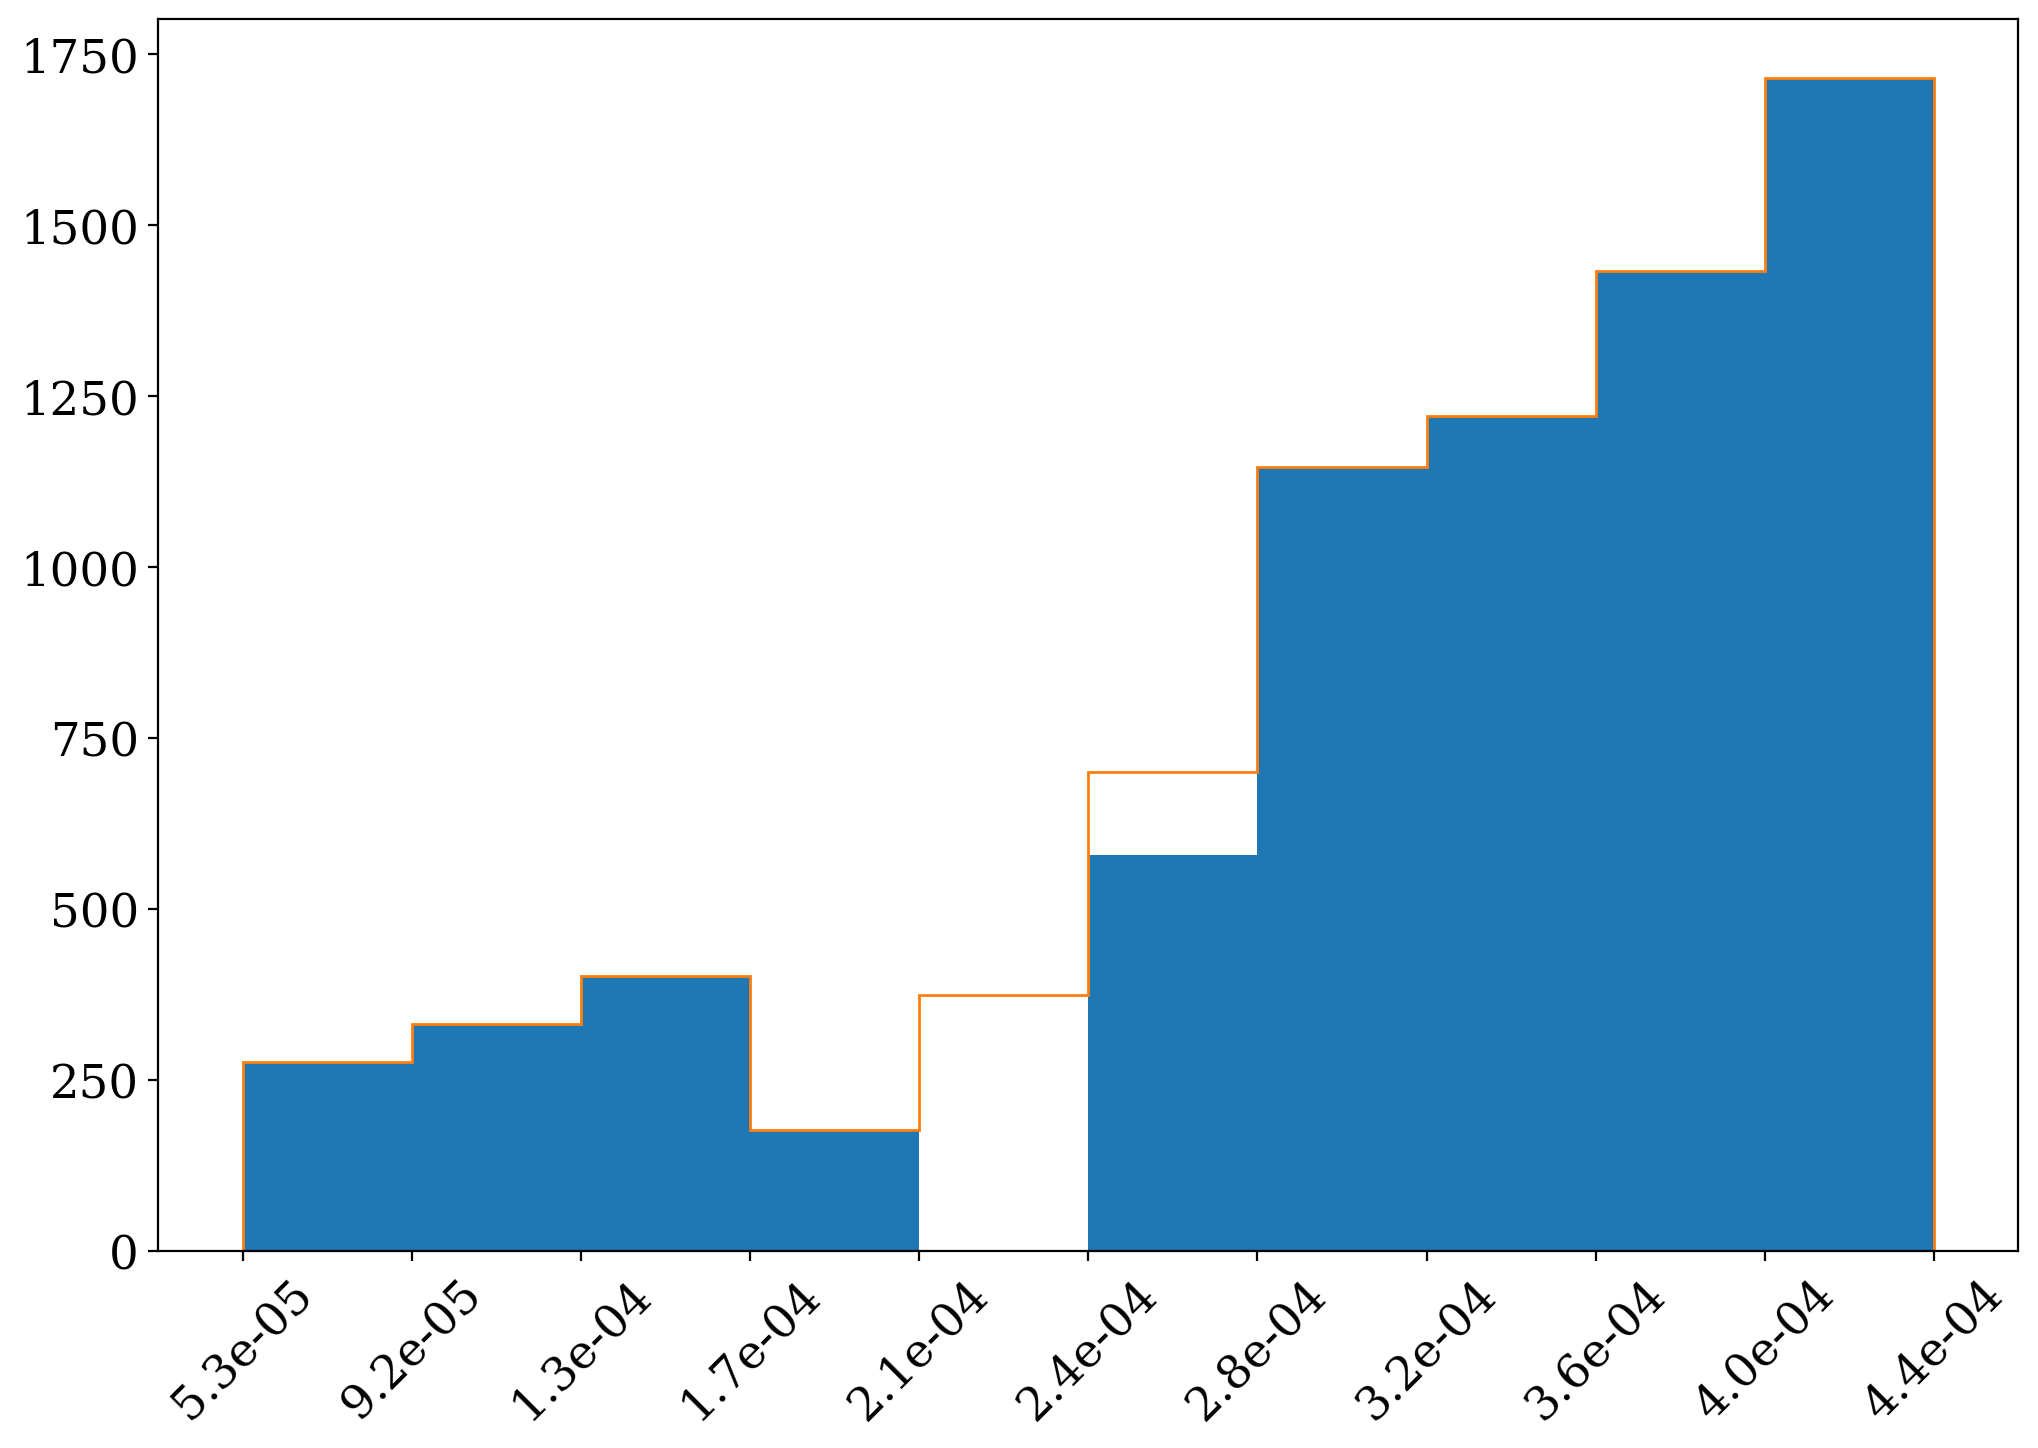

In [34]:
fig, ax = plt.subplots()
ax.stairs(counts, bins, fill=True)
ax.stairs(filledcts, bins)
ax.set_xticks(bins)
ax.set_xticklabels([f'{b:.1e}' for b in bins], rotation=45);

## make general purpose funcs

In [89]:
# now lets make a function that calculates the number of CVs at a given freq/chirp mass
# lets include freq bin and chirp mass bins to get true number rather than density
# also will create meshgrid from input arrays now

def dNdmchirp(cvpop, Nbins, freqcolname=' f_gw[Hz]', mass1colname='# m1[Msun]', mass2colname=' m2[Msun]'):
    """
    Create chirp mass distribution from given CV population using KDE.

    Nbins is used to bin the CVs according to frequency, this function then 
    finds the frequency bin with the most CVs before the EM freq gap and 
    uses the CVs in that bin to form a chirp mass distribution using a KDE. This distribution
    is then returned as an interpolation function and can be used to fill the 
    missing CV population in the EM gap using the N_CVs_gwevol function.

    Parameters
    ----------
    cvpop : DataFrame
        DataFrame containing CV population data.
    Nbins : int
        Number of bins for CV population.
    freqcolname : str, optional
        Column name for frequency in the CV population DataFrame 
        (default is ' f_gw[Hz]').
    mass1colname : str, optional
        Column name for primary mass in the CV population DataFrame
        (default is '# m1[Msun]').
    mass2colname : str, optional
        Column name for secondary mass in the CV population DataFrame
        (default is ' m2[Msun]').

    Returns
    -------
    mc_interp : scipy.interpolate.interp1d (function)
        Interpolation of chirp mass distribution at lowest frequency bin.
        to get value at mchirp_val, use mc_interp(mchirp_val).
    """
    # LSS bin up the CV population to find EM gap
    counts, bins = np.histogram(cvpop[freqcolname], bins=Nbins)
    df = bins[1]-bins[0]
    emgap_inds = np.where(counts==0)[0] # LSS get indices of EM gap

    # LSS 20260129 - getting f bin with most CVs before gap. 
    # some CVs may have detached already and are not visible in the lowest freq bin before EM gap.
    fprime_ind = np.argmax(counts[:emgap_inds[0]])
    fprime = bins[fprime_ind]

    # using flo as fprime
    # flo_ind = emgap_inds[0]-1 # LSS get index of lowest freq bin before gap
    # fprime_ind = flo_ind
    # fprime = bins[flo_ind]

    # LSS now use entire CV population below EM gap to get mchirp distribution.
    fprime_CVs_ind = np.where(CV_pop[freqcolname]<bins[emgap_inds[0]])[0]
    #print(f'N CVs below EM gap {fprime_CVs_ind.shape[0]}')
    
    # LSS get the CVs in fprime
    fprime_CVs_ind = np.where((CV_pop[freqcolname]>bins[fprime_ind]) &
                    (CV_pop[freqcolname]<bins[fprime_ind]+df))[0]
    
    #print('N CVs in fprime bin:', fprime_CVs_ind.shape[0])
    fprime_CVs = cvpop.iloc[fprime_CVs_ind]
    
    # LSS check that we recovered the right number of CVs
    # if fprime_CVs_ind.shape[0] != counts[fprime_ind]:
    #     print(f'{fprime_CVs_ind.shape[0]=}, {counts[fprime_ind]=}')
    #     raise Exception('Number of CVs in fprime bin does not match histogram count!')

    fprime_mc = lw.utils.chirp_mass(fprime_CVs[mass1colname] * u.Msun, fprime_CVs[mass2colname] * u.Msun)
    
    kern = 'gaussian'
    
    #bwrange = np.linspace(1e-9, 1e-3, 1000) 
    bwrange = np.linspace(1e-4, 1e-1, 1000) 
    K = 20 # Do 20-fold cross validation
    grid = GridSearchCV(KernelDensity(kernel=kern), {'bandwidth': bwrange}, cv=K) 
    
    # LSS find optimal bandwidth based on chirp mass distribution at fprime
    grid.fit(np.array(fprime_mc)[:, None]) 
    h_opt = grid.best_params_['bandwidth']
    print(f"Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: {h_opt}")

    # LSS make KDE over range of chirp masses in fprime bin
    mc_range = np.linspace(min(fprime_mc), max(fprime_mc), 100)
    mc_kde = KernelDensity(kernel=kern, bandwidth=h_opt).fit(np.array(fprime_mc)[:, None])
    #mc_kde = KernelDensity(kernel=kern, bandwidth='scott').fit(np.array(fprime_mc)[:, None])
    #mc_kde1 = KernelDensity(kernel=kern, bandwidth='scott').fit(np.array(fprime_mc)[:, None])
    #print(f"Bandwidth using Scott's rule: {mc_kde1.bandwidth_}")
    # LSS get log density values from KDE
    log_dens = mc_kde.score_samples(mc_range[:, None])
    
    # normalize and return 0 if chirp mass out of interpolation range
    mc_interp = interpolate.interp1d(mc_range, np.exp(log_dens)/np.sum(np.exp(log_dens)), fill_value=0, bounds_error=False)
    
    return mc_interp



def N_CVs_gwevol(f, mchirp, Nbin, cvpop=CV_pop):
    """
    Calculate the number of CVs at given frequencies assuming only GW evolution.

    This function assumes the chirp mass distribution is the same as that at the
    frequency bin with the most CVs before the EM freq gap.

    Parameters
    ----------
    f : array
        array of frequencies in Hz. Must include fprime (freq with most CVs before EM gap) 
        as first frequency to ensure proper normalization.
    mchirp : array
        array of chirp masses in solar masses
    
    Returns
    -------
    N : array
        number of CVs at each frequency (summed over chirp mass)
    """
    # LSS get df and dm for converting later density to number
    df = f[1]-f[0]
    dm = mchirp[1]-mchirp[0]

    # LSS get population binned by freq
    cvcounts, fbins = np.histogram(cvpop[' f_gw[Hz]'], bins=Nbin)
    emgap_inds = np.where(cvcounts==0)[0] # LSS get indices of EM gap
    # LSS 20260129 - getting f bin with most CVs before gap. 
    # some CVs may have detached already and are not visible 
    # in the lowest freq bin before EM gap.
    fprime_ind = np.argmax(cvcounts[:emgap_inds[0]])
    
    #flo_ind = emgap_inds[0]-1 # LSS get index flo

    # LSS create meshgrid from input arrays
    Fgrid, Mgrid = np.meshgrid(f, mchirp)

    # See eqn A2 of Nissanke et al. 2012
    # G, c in m, s, kg
    dfdt_fact = (96/5)*np.pow(np.pi, -8/3)*np.pow(apyconst.G.value, -5/3)*np.pow(apyconst.c.value, 5)

    # LSS convert chirp mass from solar masses to kg
    mc_kg = Mgrid * apyconst.M_sun.value
    dfdt_vars = np.pow(mc_kg, 5/3)*np.pow(Fgrid, 11/3)
    dtdf = (dfdt_fact*dfdt_vars)**-1

    # LSS get chirp mass distribution based on input binning of CV population
    dNdmc_func = dNdmchirp(cvpop, Nbin)
    try:
        dNdmc = dNdmc_func(Mgrid)
    except ValueError:
        print("Chirp mass values out of interpolation range, setting those values to zero.")
        dNdmc = np.zeros_like(Mgrid)
        mchirp_min = min(dNdmc_func.x)
        mchirp_max = max(dNdmc_func.x)
        print(f"Chirp mass interpolation range: {mchirp_min} - {mchirp_max} Msun")
        valid_inds = np.where((Mgrid >= mchirp_min) & (Mgrid <= mchirp_max))
        dNdmc[valid_inds] = dNdmc_func(Mgrid[valid_inds])
    
    # LSS calculate normalization via number in fprime bin
    normfact = cvcounts[fprime_ind] / np.sum(dtdf[:, 0] * dNdmc[:, 0] * df * dm)

    # LSS sanity check with normalization
    tstNfprime = np.sum(dtdf[:, 0] * dNdmc[:, 0] * normfact * df * dm)
    if np.round(tstNfprime) != cvcounts[fprime_ind]:
        print(f'{tstNfprime=}, {cvcounts[fprime_ind]=}')
        raise Exception("Normalization check failed: calculated number in fprime bin does not match histogram count!")


    N = dtdf * dNdmc * normfact * df * dm
    # LSS Sum over chirp mass to get total number at each frequency
    N = np.sum(N, axis=0)  
    return N

def plot_em_gap_fill(rawcts, fillcts, bns, log=False):
    """Plot histogram of raw counts and filled counts over frequency bins.

    Parameters
    ----------
    rawcts : array
        Array of raw counts in each frequency bin.
    fillcts : array
        Array of filled counts in each frequency bin.
    bns : array
        Array of frequency bin edges.
    """
    fig, ax = plt.subplots()
    ax.stairs(rawcts, bns, fill=True, label='CV population')
    ax.stairs(fillcts, bns, label='GW evolution through EM gap')
    ax.set_xticks(bns)
    ax.set_xticklabels([f'{b:.1e}' for b in bns], rotation=45)
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Number of CVs')
    ax.set_title(f'CV population: bins={bns.shape[0]-1}') # LSS account for extra bin edge
    if log:
        ax.set_yscale('log')
    ax.legend()
    plt.show()

## test general purpose function with 20 bins for f binning CV pop

In [40]:
counts20, bins20 = np.histogram(CV_pop[' f_gw[Hz]'], bins=20)

In [41]:
np.argmax(counts20[:np.where(counts20==0)[0][0]])

np.int64(5)

In [42]:
counts20

array([134, 143, 156, 177, 191, 211, 177,   0,   0,   0,   0, 579, 554,
       593, 622, 599, 682, 751, 780, 935])

In [43]:
# LSS get the mchirp range from the interpolation
nb = 20
dndmc_func = dNdmchirp(CV_pop, Nbins=nb)
mc_range = np.linspace(dndmc_func.x[0], dndmc_func.x[-1], 10)
fgap_ind = np.where(counts20 == 0)[0]
print(fgap_ind)
fprime_and_fgap_ind = np.arange(nb)[np.argmax(counts20[:fgap_ind[0]]):fgap_ind[-1]+1]
print(fprime_and_fgap_ind)
#flo_and_fgap_ind = [np.argmax(counts20[:np.where(counts20 == 0)[0][0]])] + list(np.where(counts20 == 0)[0])
fprime_and_fgap = bins20[fprime_and_fgap_ind]
print(fprime_and_fgap)
N_CVs_gwevol(fprime_and_fgap, mc_range, Nbin=20)

N CVs below EM gap 1189
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.0014000000000000002
[ 7  8  9 10]
[ 5  6  7  8  9 10]
[0.00014897 0.00016809 0.00018722 0.00020635 0.00022547 0.0002446 ]
N CVs below EM gap 1189


KeyboardInterrupt: 

In [40]:
fprime_and_fgap_ind[1:]

array([ 6,  7,  8,  9, 10])

In [41]:
counts20filled = copy.deepcopy(counts20)
counts20filled[fprime_and_fgap_ind[1:]] = counts20filled[fprime_and_fgap_ind[1:]] +N_CVs_gwevol(fprime_and_fgap, mc_range, Nbin=20)[1:]

N CVs in fprime bin: 211
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001


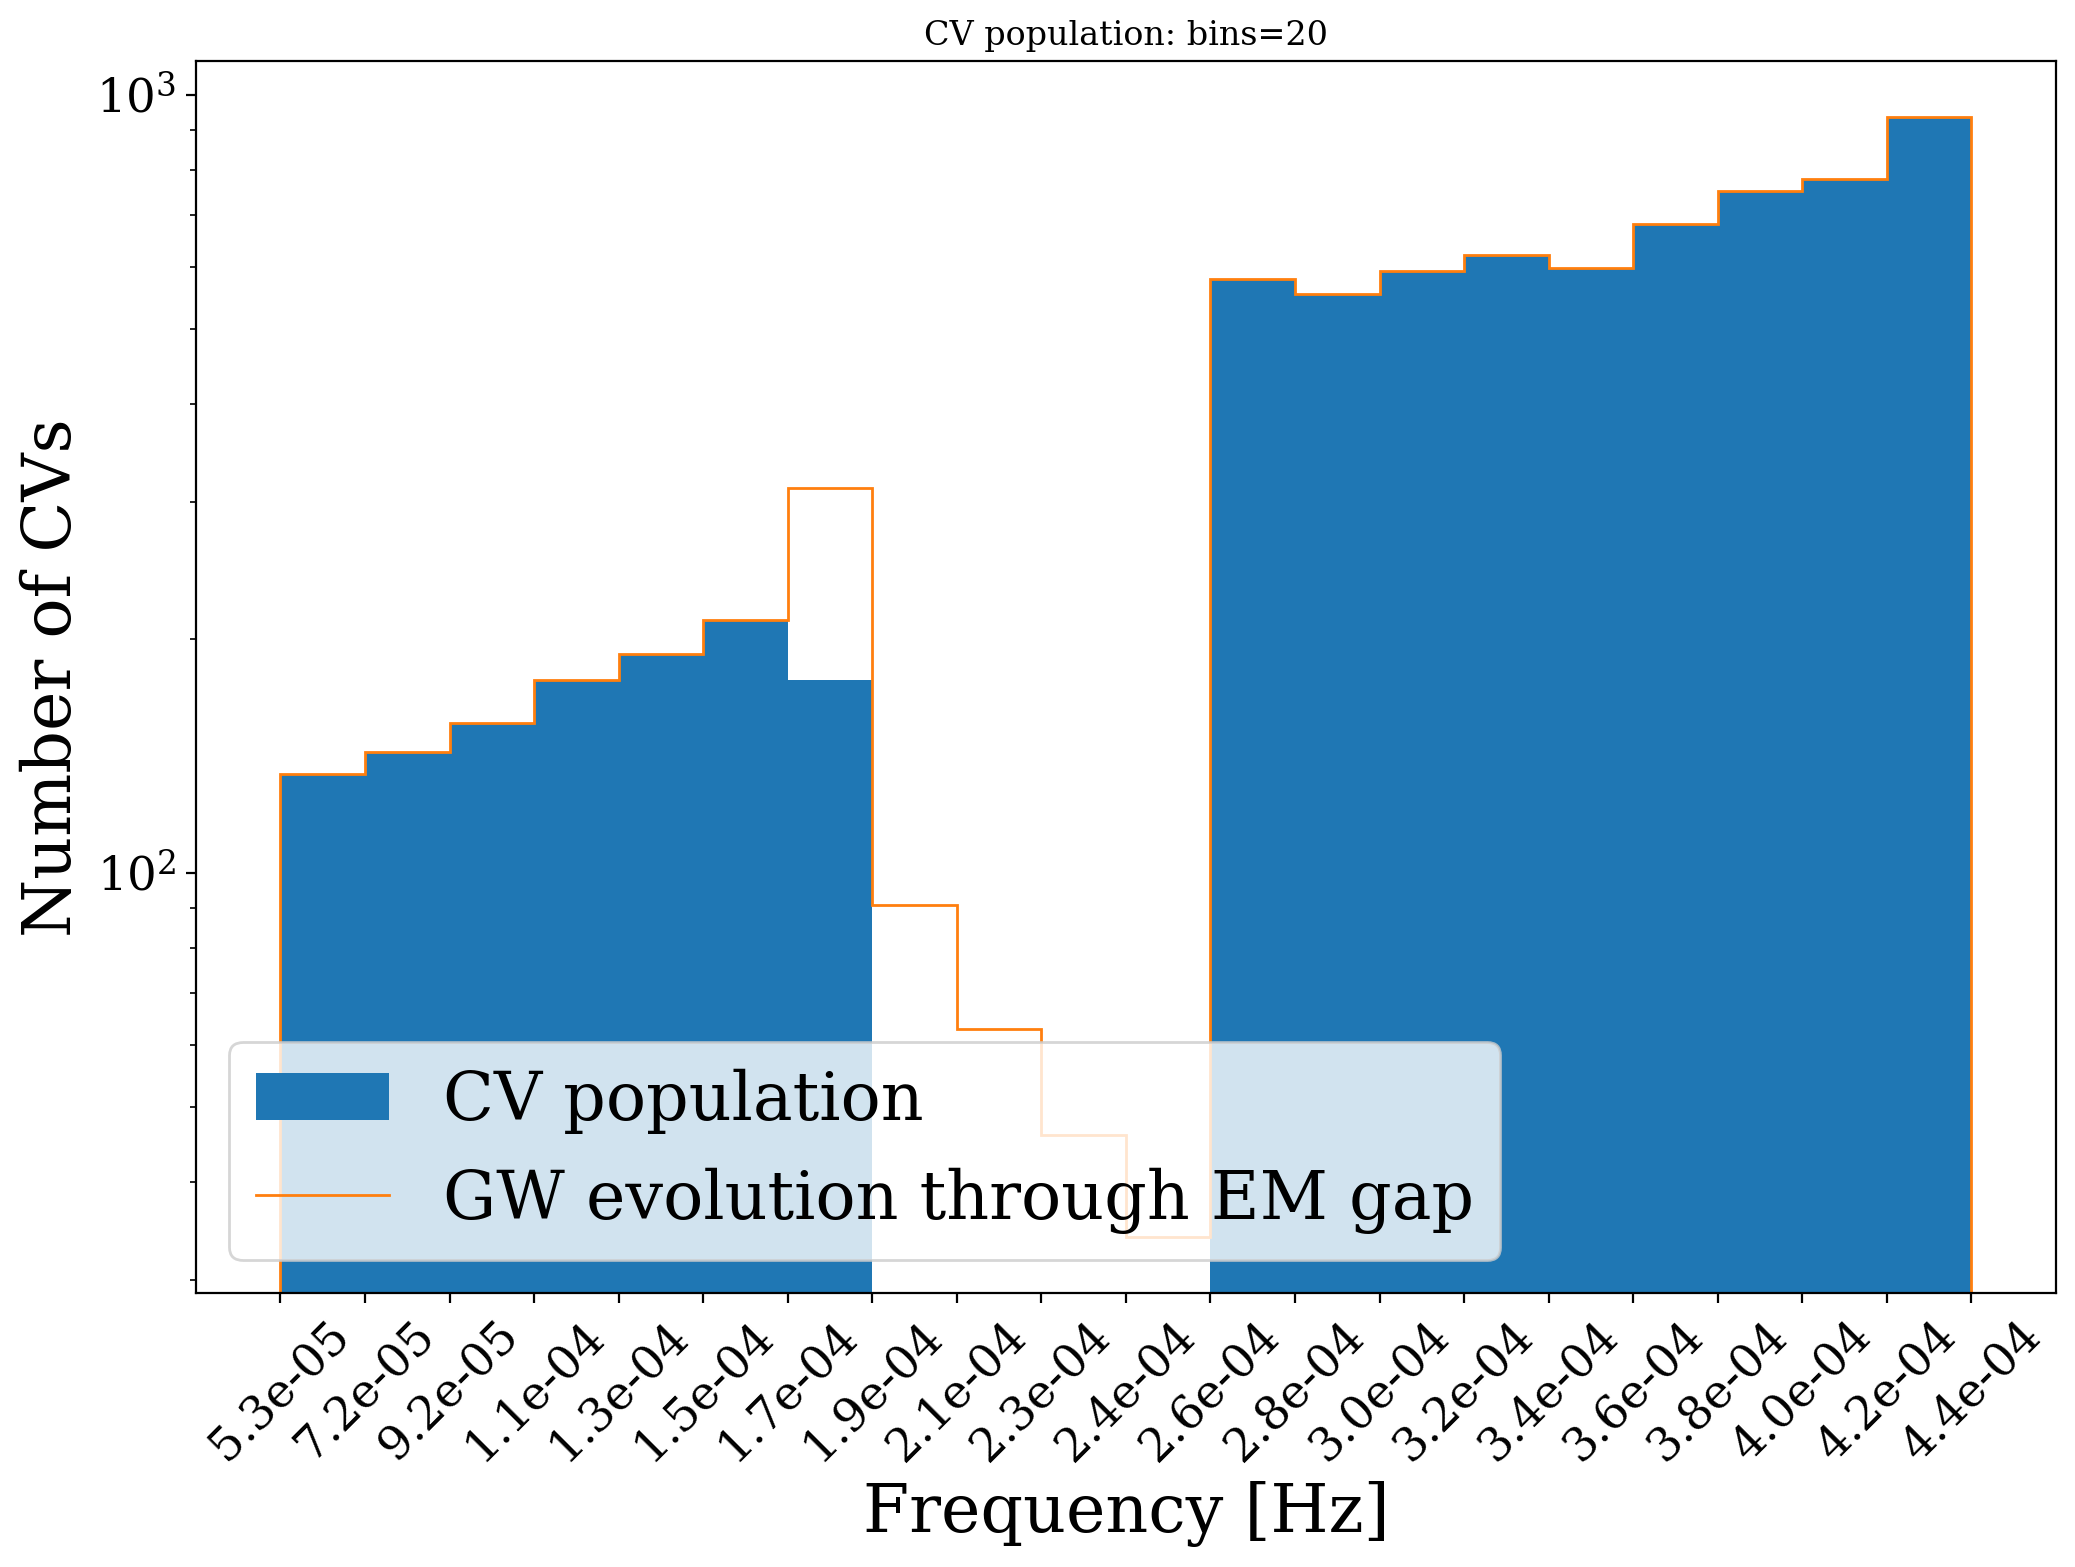

In [42]:
plot_em_gap_fill(counts20, counts20filled, bins20, log=True)

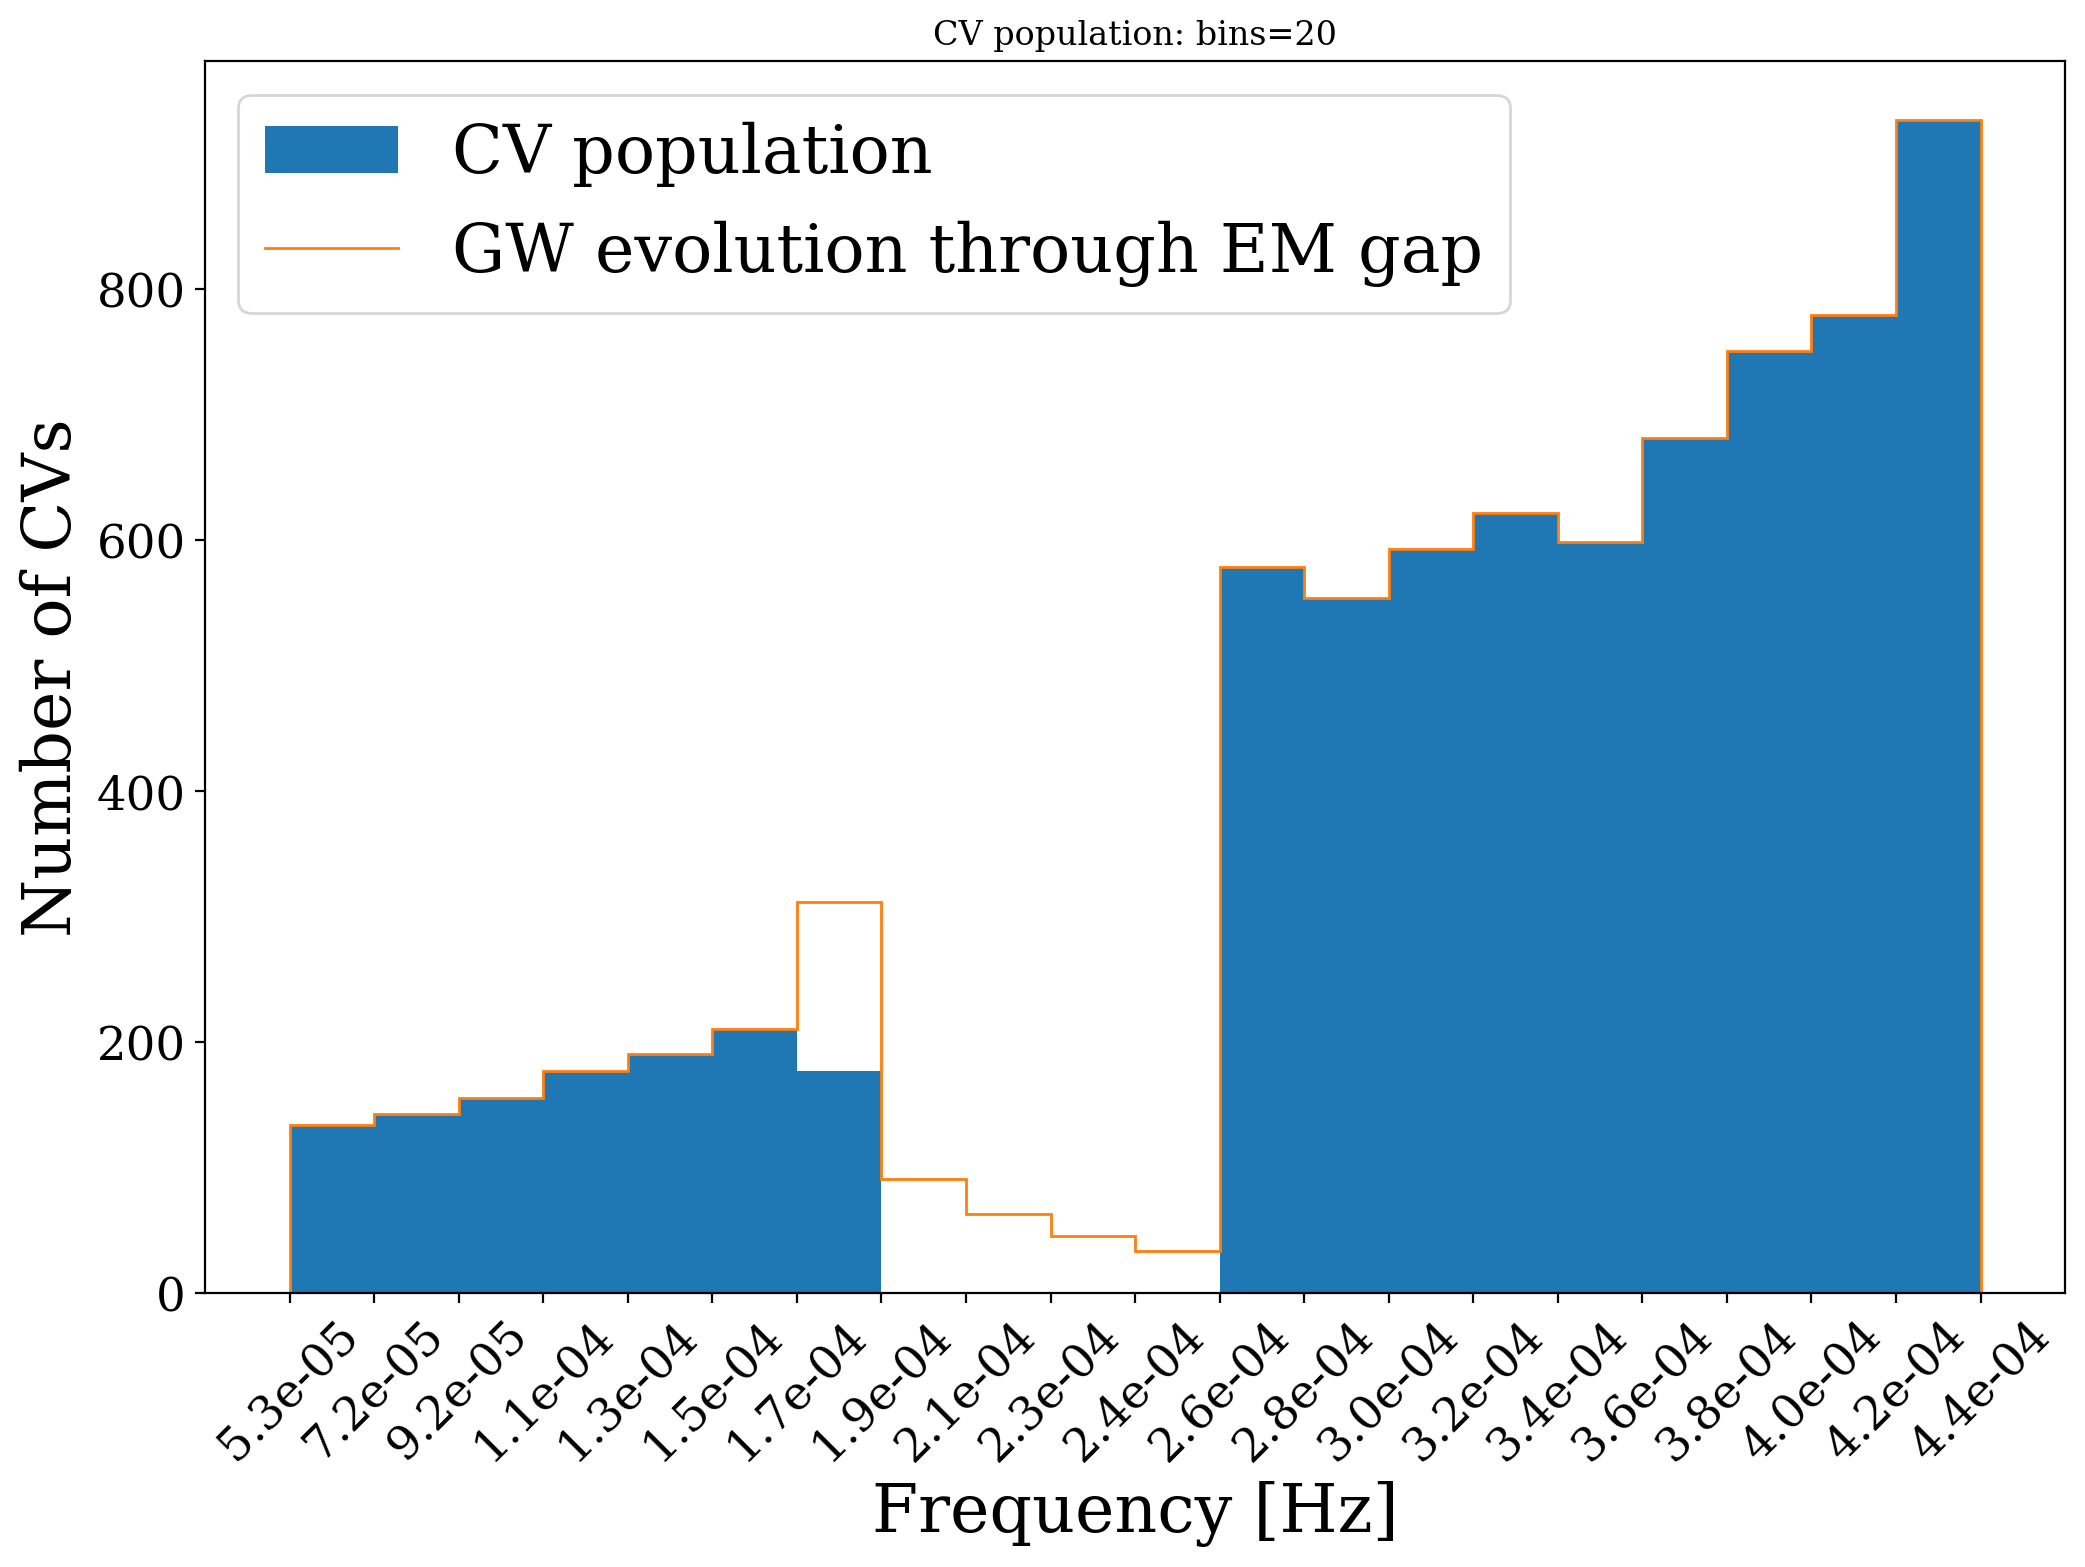

In [43]:
plot_em_gap_fill(counts20, counts20filled, bins20)

## seeing the effect of different binning
- on chirp mass dist

In [44]:
dndmc_interp = dNdmchirp(CV_pop, Nbins=20)

N CVs below EM gap 1189
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.0014000000000000002


In [45]:
plt.plot(mc_range,dndmc_interp(mc_range), label=f'Nbins={i}')


NameError: name 'i' is not defined

In [63]:
counts20, bins20 = np.histogram(CV_pop[' f_gw[Hz]'], bins=20)
counts20[:7].sum()

np.int64(1189)

In [64]:
counts20

array([134, 143, 156, 177, 191, 211, 177,   0,   0,   0,   0, 579, 554,
       593, 622, 599, 682, 751, 780, 935])

(array([134., 143., 156., 177., 191., 211., 177.,   0.,   0.,   0.,   0.,
        579., 554., 593., 622., 599., 682., 751., 780., 935.]),
 array([5.3337200e-05, 7.2463270e-05, 9.1589340e-05, 1.1071541e-04,
        1.2984148e-04, 1.4896755e-04, 1.6809362e-04, 1.8721969e-04,
        2.0634576e-04, 2.2547183e-04, 2.4459790e-04, 2.6372397e-04,
        2.8285004e-04, 3.0197611e-04, 3.2110218e-04, 3.4022825e-04,
        3.5935432e-04, 3.7848039e-04, 3.9760646e-04, 4.1673253e-04,
        4.3585860e-04]),
 <BarContainer object of 20 artists>)

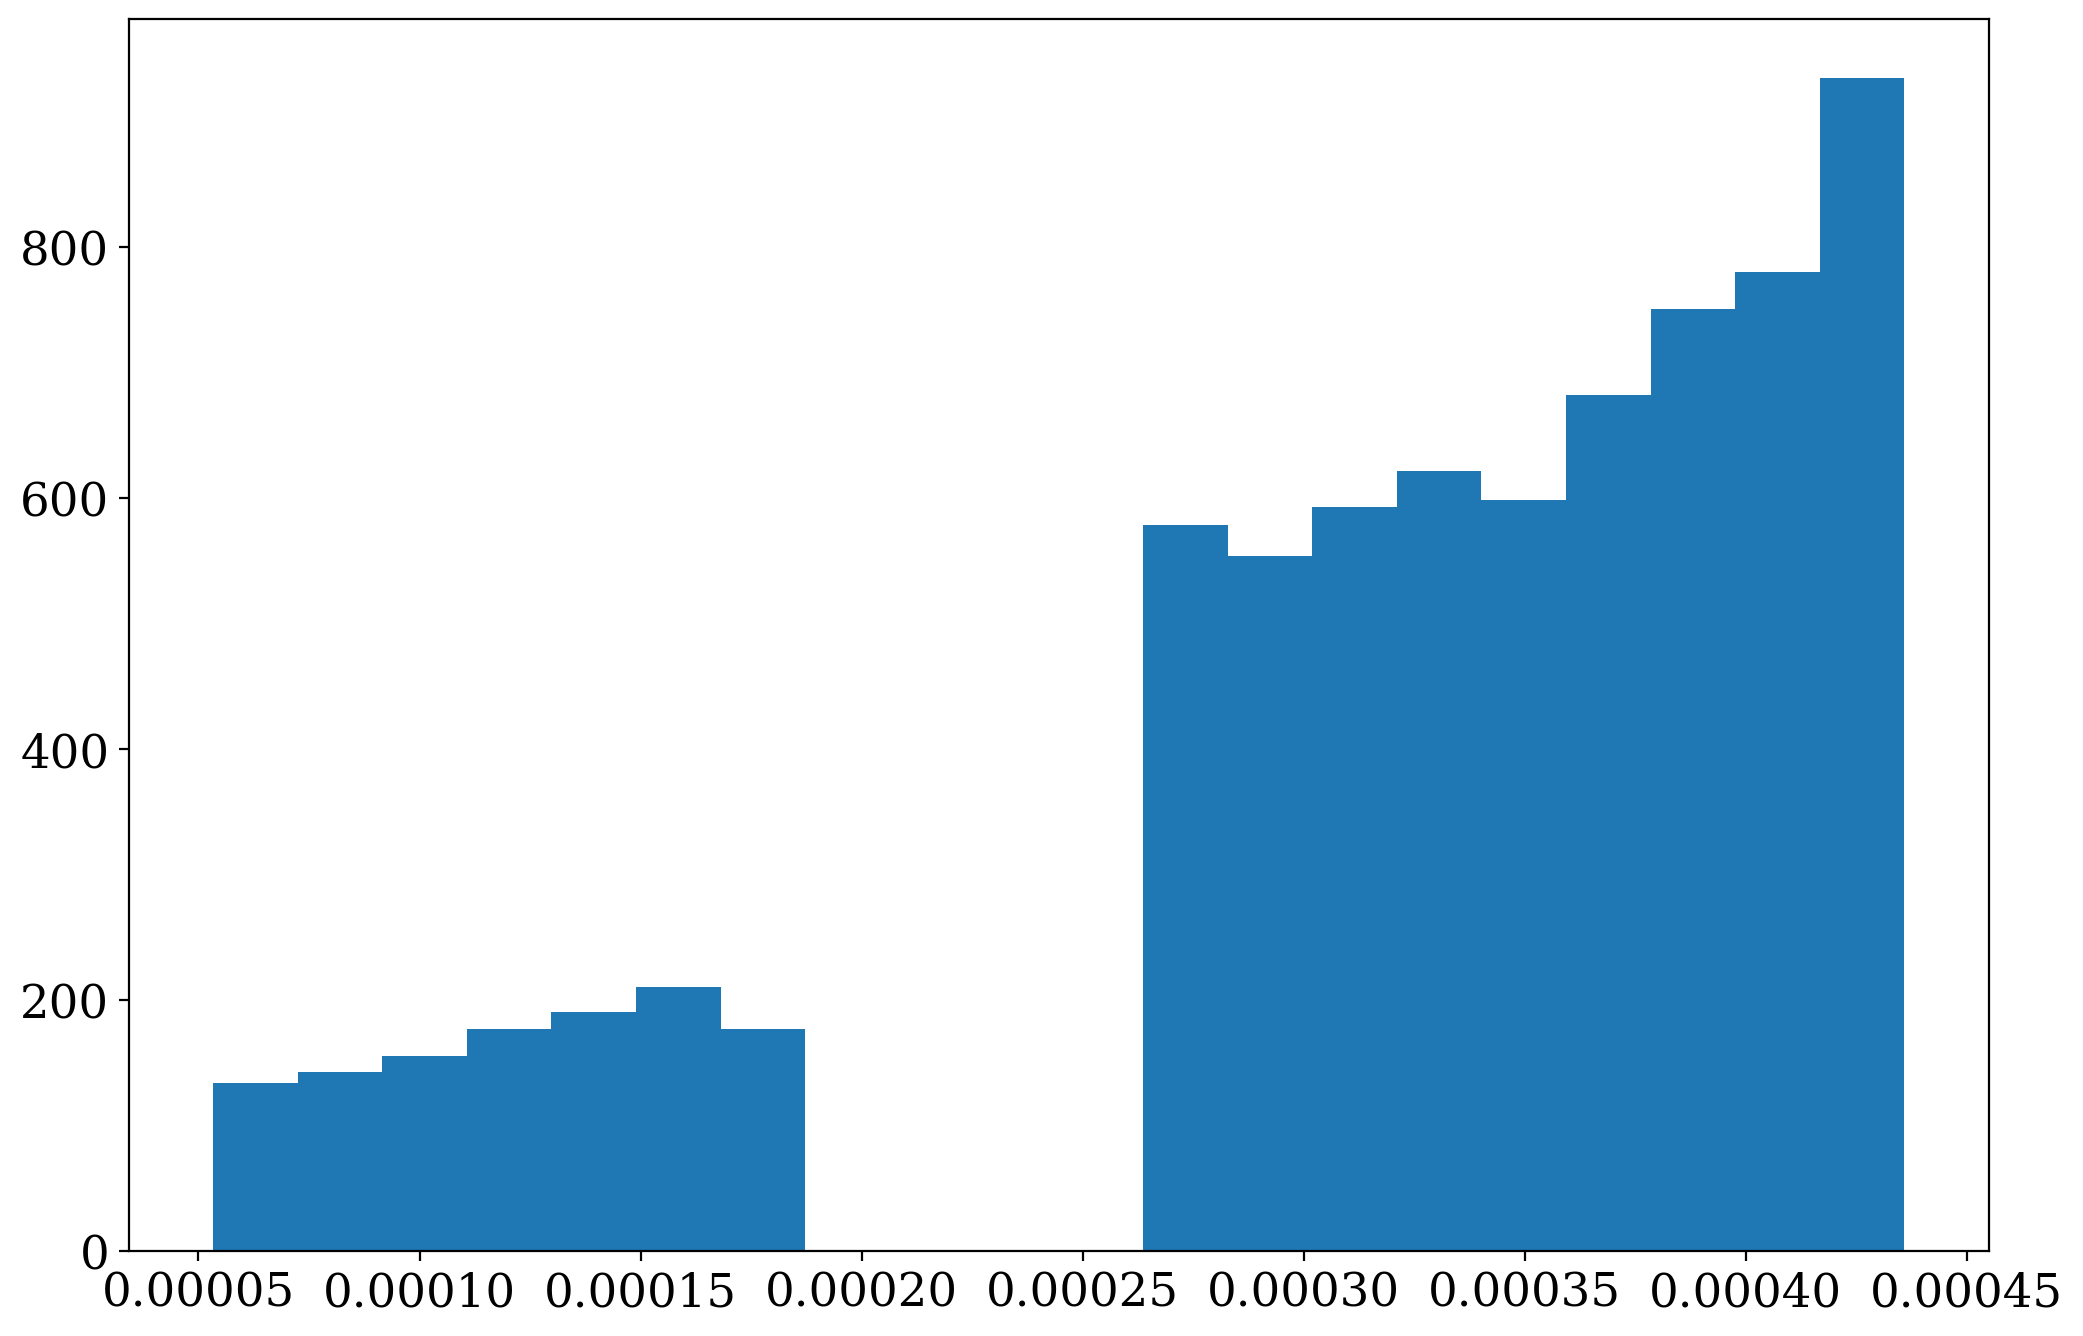

In [55]:
plt.hist(CV_pop[' f_gw[Hz]'], bins=20)

N CVs below EM gap 1189
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001
N CVs below EM gap 1189
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001
N CVs below EM gap 1189
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001
N CVs below EM gap 1189
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001
N CVs below EM gap 1189
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001
N CVs below EM gap 1189
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001
N CVs below EM gap 1189
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001
N CVs below EM gap 1189
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001
N CVs below EM gap 1189
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001
N CVs below EM gap 1189
Optimal bandwidth for 

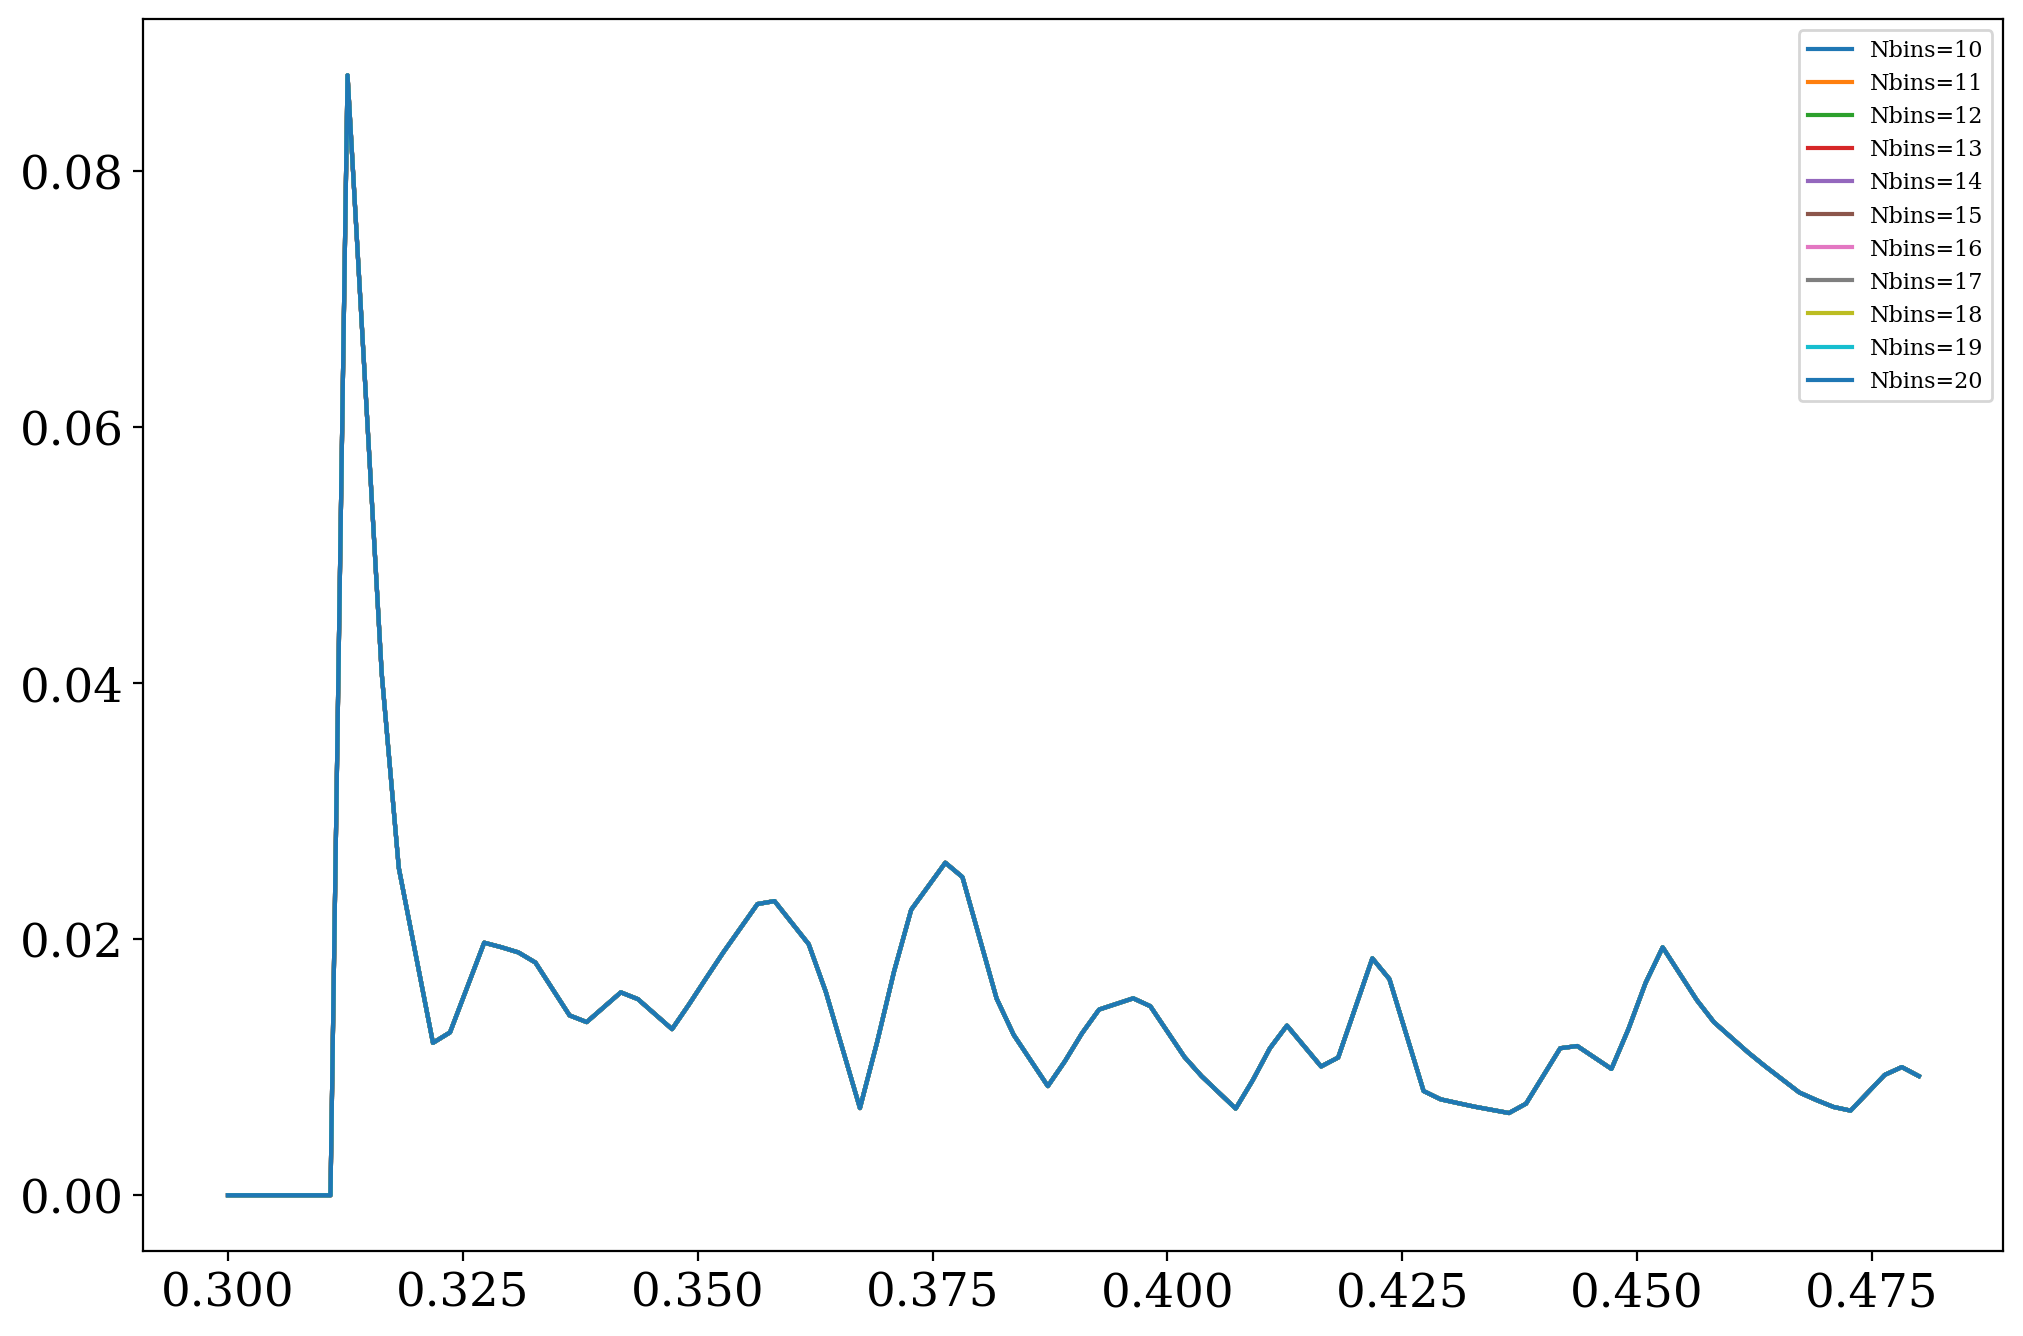

In [69]:
mc_range = np.linspace(0.3, 0.48, 100)

for i in range(10, 21):
    dndmc_interp = dNdmchirp(CV_pop, Nbins=i)
    plt.plot(mc_range,dndmc_interp(mc_range), label=f'Nbins={i}')

plt.legend(fontsize=8, loc='upper right')
plt.show()

In [46]:
dir(dndmc_interp)

['__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_call',
 '_call_linear',
 '_call_linear_np',
 '_call_nan_spline',
 '_call_nearest',
 '_call_previousnext',
 '_call_spline',
 '_check_and_update_bounds_error_for_extrapolation',
 '_check_bounds',
 '_evaluate',
 '_extrapolate',
 '_fill_value_above',
 '_fill_value_below',
 '_fill_value_orig',
 '_finish_y',
 '_kind',
 '_prepare_x',
 '_reshape_yi',
 '_set_dtype',
 '_set_yi',
 '_y',
 '_y_axis',
 '_y_extra_shape',
 'axis',
 'bounds_error',
 'copy',
 'dtype',
 'fill_value',
 'x',
 'y']

## testing over nbins 10-20

CV frequency bins: 10
N CVs in fprime bin: 402
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001
Chirp mass interpolation range: 0.3199854545289912 - 0.44554573155911503 Msun
Chirp mass interpolation size: -1.26e-01 Msun
N CVs in fprime bin: 402
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001


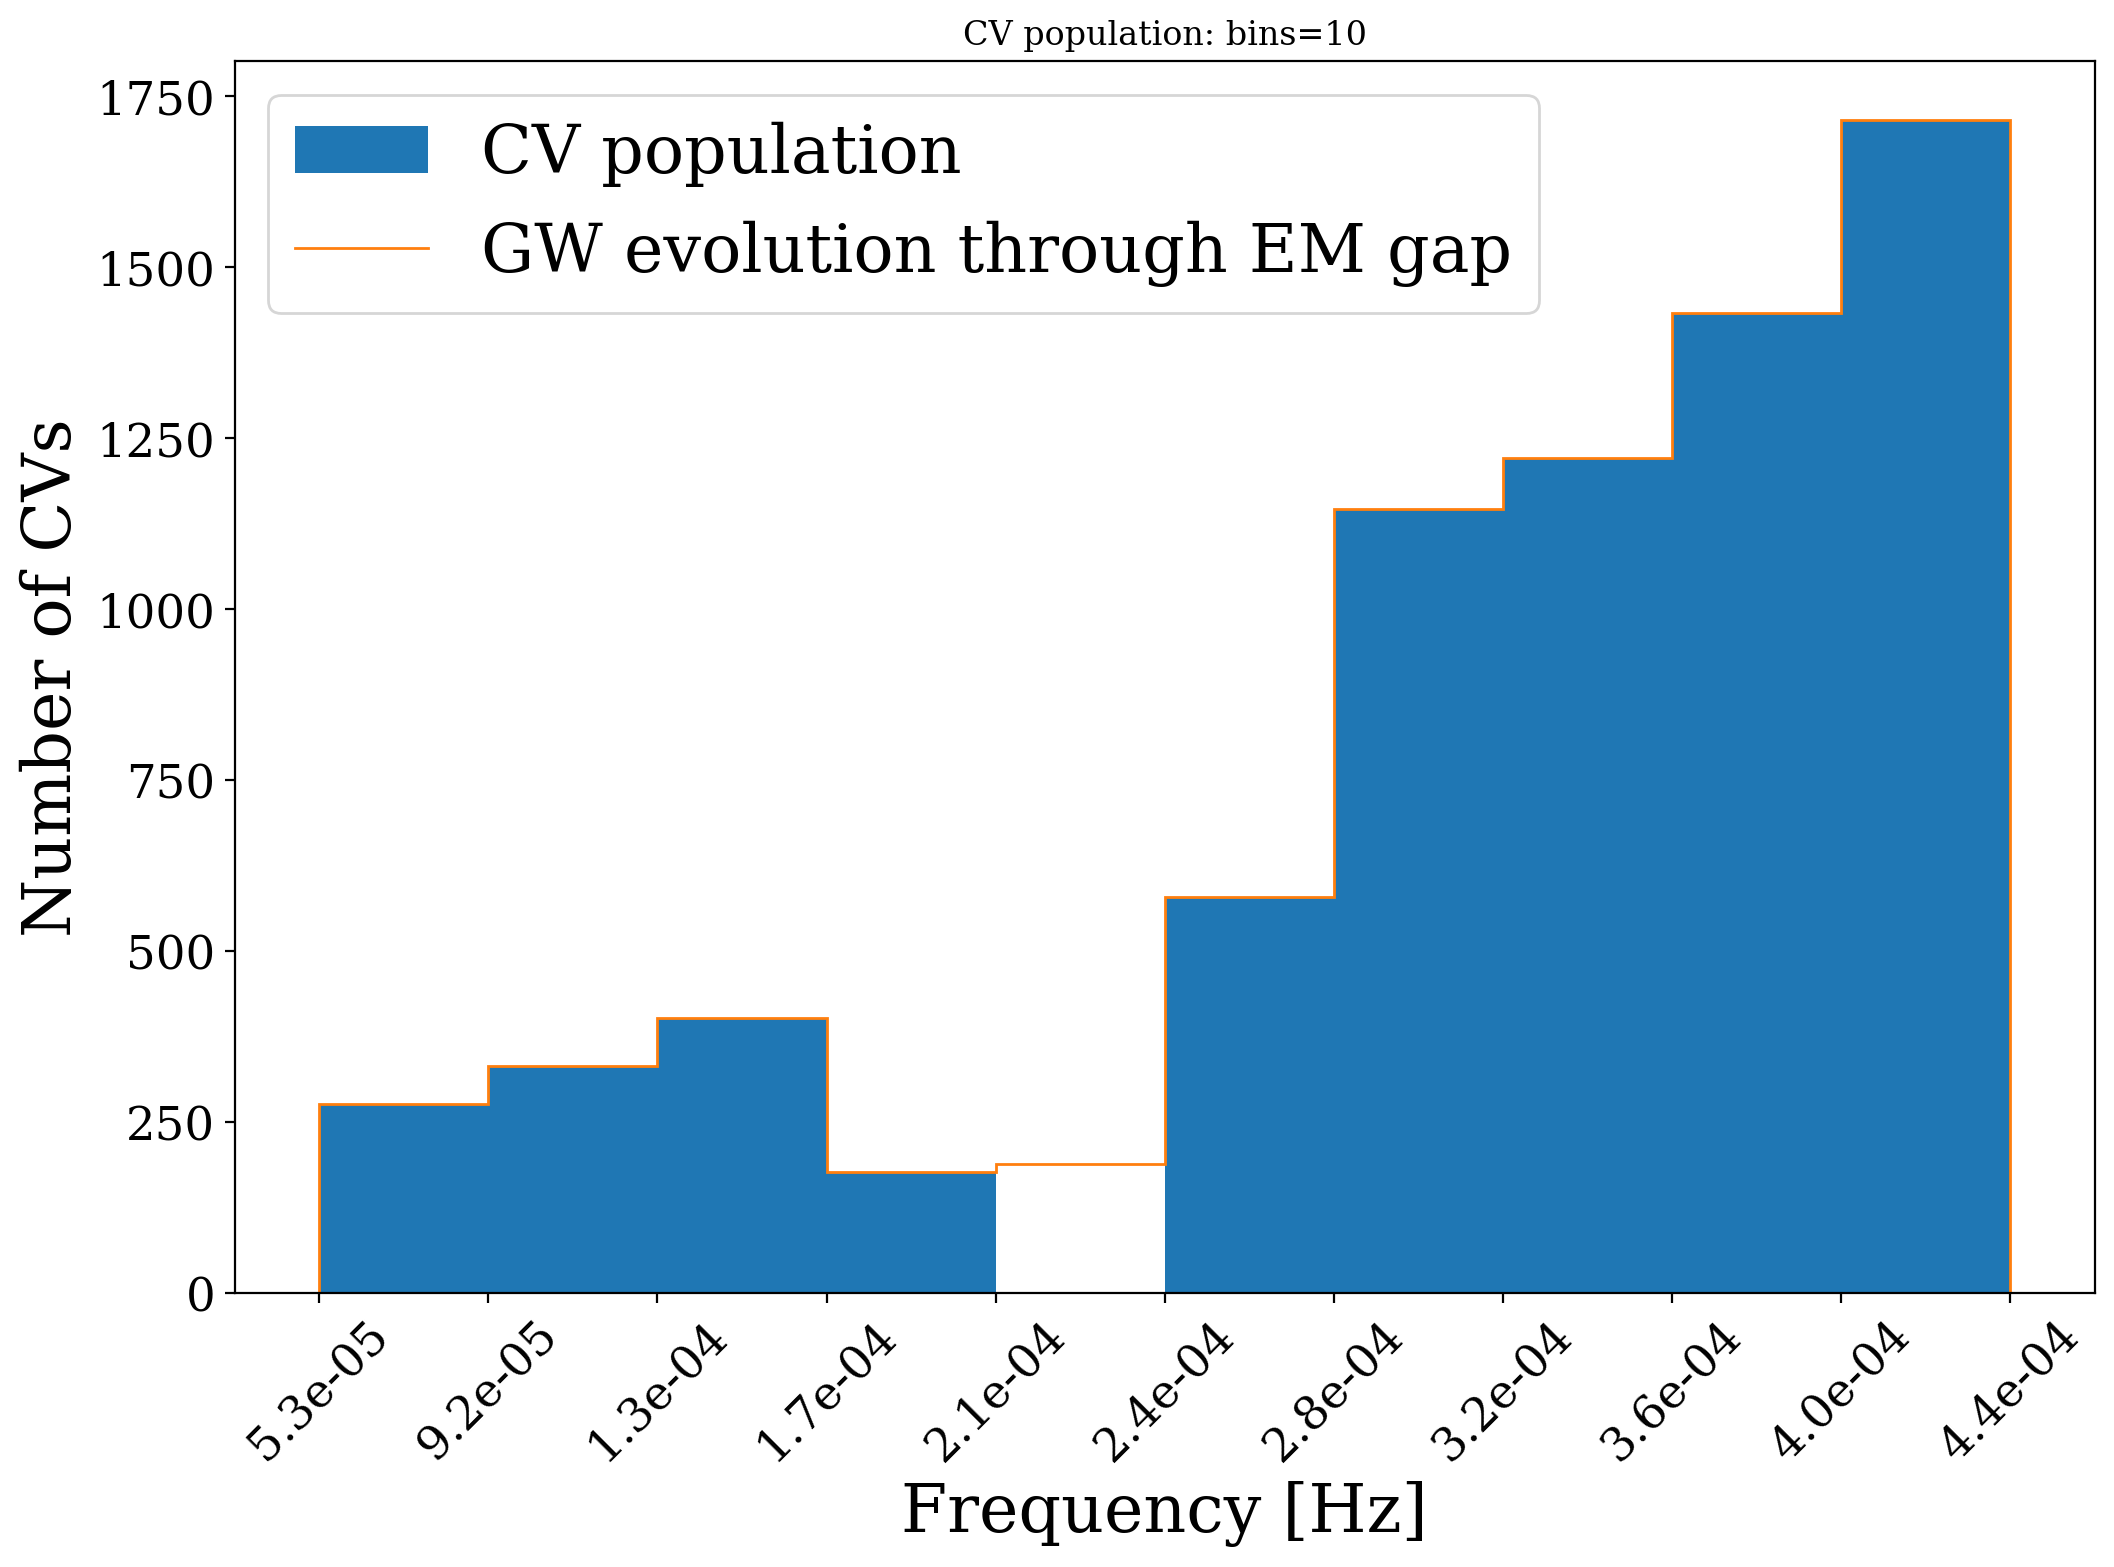

CV frequency bins: 11
N CVs in fprime bin: 356
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001
Chirp mass interpolation range: 0.34900341772459165 - 0.4714782651749314 Msun
Chirp mass interpolation size: -1.22e-01 Msun
N CVs in fprime bin: 356
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001


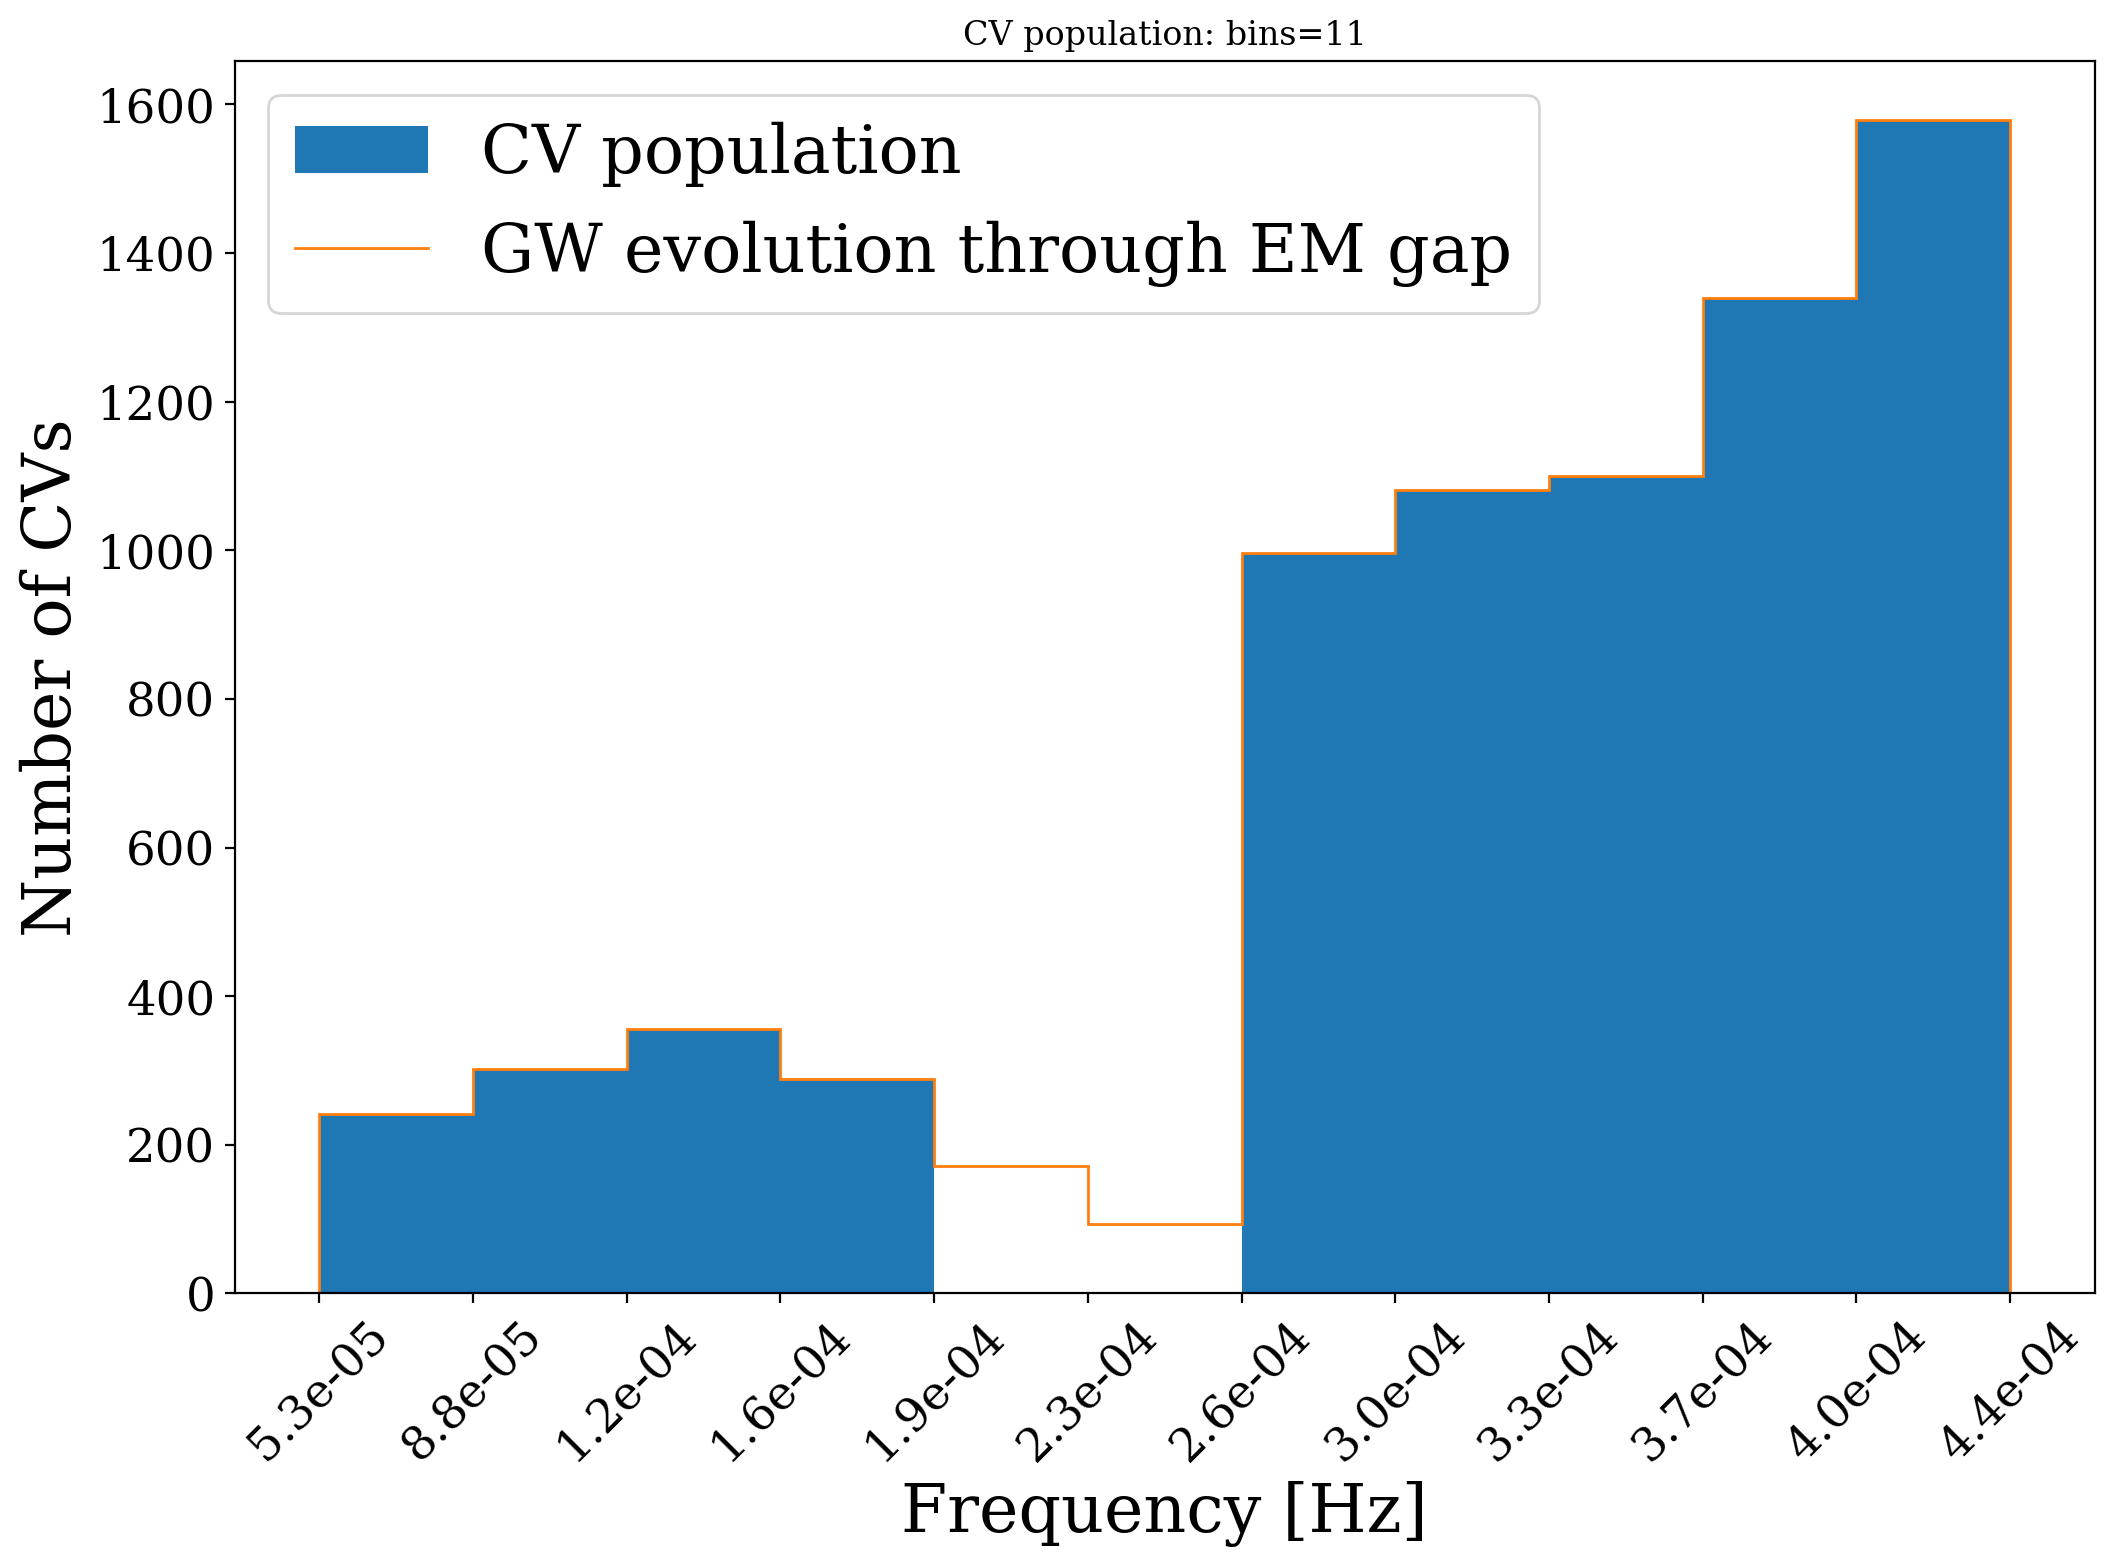

CV frequency bins: 12
N CVs in fprime bin: 388


KeyboardInterrupt: 

In [47]:
f_nbinlist = np.arange(10, 21)
mc_nbinlist = np.arange(10, 50)
y = 50

for x in f_nbinlist:
    print(f'CV frequency bins: {x}')
    #for y in mc_nbinlist:
    countsx, binsx = np.histogram(CV_pop[' f_gw[Hz]'], bins=x)
    # LSS get the mchirp range from the interpolation
    dndmc_func = dNdmchirp(CV_pop, Nbins=x)
    print(f"Chirp mass interpolation range: {dndmc_func.x[0]} - {dndmc_func.x[-1]} Msun")
    print(f"Chirp mass interpolation size: {dndmc_func.x[0] - dndmc_func.x[-1]:.2e} Msun")
    mc_range = np.linspace(dndmc_func.x[0], dndmc_func.x[-1], y)
    flo_and_fgap_ind = [np.where(countsx == 0)[0][0]-1]+ list(np.where(countsx == 0)[0])
    flo_and_fgap = binsx[flo_and_fgap_ind]
    countsxfilled = copy.deepcopy(countsx)
    countsxfilled[flo_and_fgap_ind[1:]] = N_CVs_gwevol(flo_and_fgap, mc_range, Nbin=x)[1:]
    plot_em_gap_fill(countsx, countsxfilled, binsx)

In [ ]:
cts13, bns13 = np.histogram(CV_pop[' f_gw[Hz]'], bins=13)

In [ ]:
cts13

array([ 200,  250,  267,  326,  146,    0,    0,  756,  890,  923, 1003,
       1179, 1344])

## making 2D KDE of freq and chirp mass

In [ ]:
    print(" - computing KDE in spherical coordinates")
    kde = KernelDensity(
        bandwidth=0.04, metric="haversine", kernel="gaussian", algorithm="ball_tree"
    )
    kde.fit(Xtrain[ytrain == i])

    # evaluate only on the land: -9999 indicates ocean
    Z = np.full(land_mask.shape[0], -9999, dtype="int")
    Z[land_mask] = np.exp(kde.score_samples(xy))
    Z = Z.reshape(X.shape)

    # plot contours of the density
    levels = np.linspace(0, Z.max(), 25)
    plt.contourf(X, Y, Z, levels=levels, cmap=plt.cm.Reds)


In [ ]:
Xtrain.shape

(1624, 2)

In [ ]:
ytrain.shape

(1624,)

 - computing KDE in spherical coordinates
 - plot coastlines from coverage
 - computing KDE in spherical coordinates
 - plot coastlines from coverage


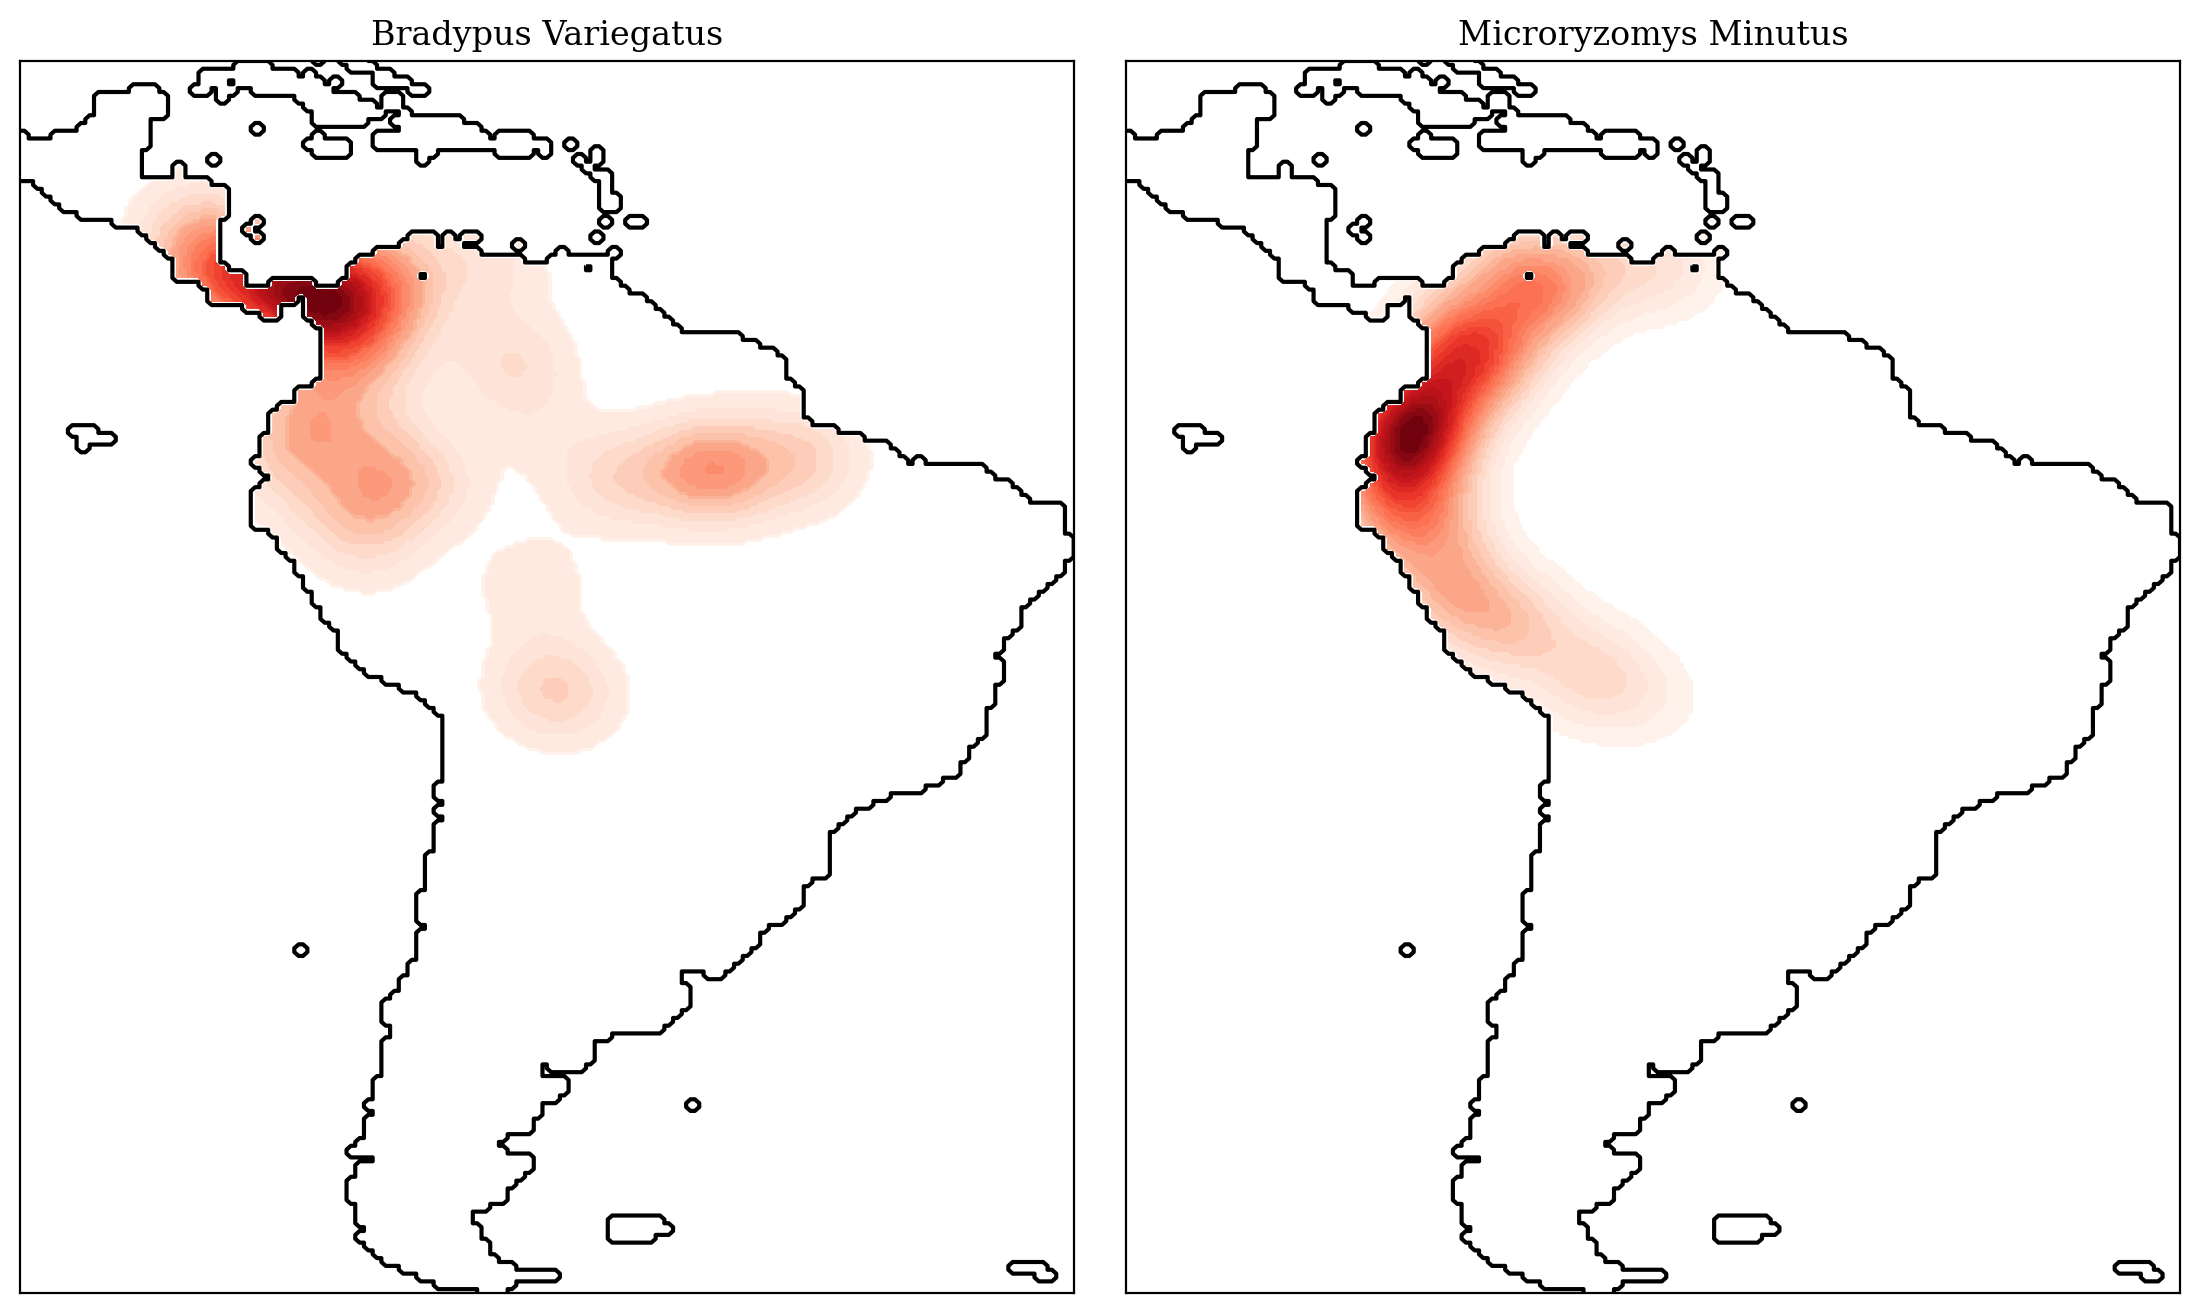

In [ ]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import fetch_species_distributions
from sklearn.neighbors import KernelDensity

# if basemap is available, we'll use it.
# otherwise, we'll improvise later...
try:
    from mpl_toolkits.basemap import Basemap

    basemap = True
except ImportError:
    basemap = False


def construct_grids(batch):
    """Construct the map grid from the batch object

    Parameters
    ----------
    batch : Batch object
        The object returned by :func:`fetch_species_distributions`

    Returns
    -------
    (xgrid, ygrid) : 1-D arrays
        The grid corresponding to the values in batch.coverages
    """
    # x,y coordinates for corner cells
    xmin = batch.x_left_lower_corner + batch.grid_size
    xmax = xmin + (batch.Nx * batch.grid_size)
    ymin = batch.y_left_lower_corner + batch.grid_size
    ymax = ymin + (batch.Ny * batch.grid_size)

    # x coordinates of the grid cells
    xgrid = np.arange(xmin, xmax, batch.grid_size)
    # y coordinates of the grid cells
    ygrid = np.arange(ymin, ymax, batch.grid_size)

    return (xgrid, ygrid)


# Get matrices/arrays of species IDs and locations
data = fetch_species_distributions()
species_names = ["Bradypus Variegatus", "Microryzomys Minutus"]

Xtrain = np.vstack([data["train"]["dd lat"], data["train"]["dd long"]]).T
ytrain = np.array(
    [d.decode("ascii").startswith("micro") for d in data["train"]["species"]],
    dtype="int",
)
Xtrain *= np.pi / 180.0  # Convert lat/long to radians

# Set up the data grid for the contour plot
xgrid, ygrid = construct_grids(data)
X, Y = np.meshgrid(xgrid[::5], ygrid[::5][::-1])
land_reference = data.coverages[6][::5, ::5]
land_mask = (land_reference > -9999).ravel()

xy = np.vstack([Y.ravel(), X.ravel()]).T
xy = xy[land_mask]
xy *= np.pi / 180.0

# Plot map of South America with distributions of each species
fig = plt.figure()
fig.subplots_adjust(left=0.05, right=0.95, wspace=0.05)

for i in range(2):
    plt.subplot(1, 2, i + 1)

    # construct a kernel density estimate of the distribution
    print(" - computing KDE in spherical coordinates")
    kde = KernelDensity(
        bandwidth=0.04, metric="haversine", kernel="gaussian", algorithm="ball_tree"
    )
    kde.fit(Xtrain[ytrain == i])

    # evaluate only on the land: -9999 indicates ocean
    Z = np.full(land_mask.shape[0], -9999, dtype="int")
    Z[land_mask] = np.exp(kde.score_samples(xy))
    Z = Z.reshape(X.shape)

    # plot contours of the density
    levels = np.linspace(0, Z.max(), 25)
    plt.contourf(X, Y, Z, levels=levels, cmap=plt.cm.Reds)

    if basemap:
        print(" - plot coastlines using basemap")
        m = Basemap(
            projection="cyl",
            llcrnrlat=Y.min(),
            urcrnrlat=Y.max(),
            llcrnrlon=X.min(),
            urcrnrlon=X.max(),
            resolution="c",
        )
        m.drawcoastlines()
        m.drawcountries()
    else:
        print(" - plot coastlines from coverage")
        plt.contour(
            X, Y, land_reference, levels=[-9998], colors="k", linestyles="solid"
        )
        plt.xticks([])
        plt.yticks([])

    plt.title(species_names[i])

plt.show()